# Evaluación de los sistemas de verificación de locutor

En las etapas anteriores se extrajeron embeddings para:

* **x-vector**
* **ECAPA-TDNN**

Posteriormente, estas representaciones se compararon utilizando la **similitud coseno**. Como resultado, cada comparación entre una grabación de inscripción (*enrollment*) y una grabación de prueba (*test*) recibió un valor numérico denominado **score**.

En términos generales:

* Un score alto indica que los embeddings de las dos grabaciones son similares.
* Un score bajo indica que los embeddings son menos similares.

Sin embargo, un score por sí solo no constituye una decisión. Para determinar si dos grabaciones pertenecen o no al mismo locutor es necesario establecer un **umbral de decisión**.

La regla general es:
$$
\text{Aceptar como mismo locutor si el score} \geq \text{umbral}
$$

$$
\text{Rechazar como mismo locutor si el score} < \text{umbral}
$$

La selección de este umbral produce un compromiso entre dos tipos de errores:

* **Falsa aceptación:** el sistema indica que dos grabaciones pertenecen al mismo locutor cuando en realidad pertenecen a locutores diferentes.
* **Falso rechazo:** el sistema indica que dos grabaciones pertenecen a locutores diferentes cuando en realidad pertenecen al mismo locutor.

Por esta razón, la evaluación no consistirá únicamente en observar qué modelo produce scores más altos. Será necesario estudiar la distribución de los scores, calcular tasas de error y analizar el comportamiento de los sistemas a través de diferentes umbrales.




## 00. Preparación del entorno de trabajo

In [1]:
# IMPORTACIÓN DE LIBRERÍAS

# Manejo de rutas y directorios de forma independiente
# del sistema operativo.
from pathlib import Path

# Manejo y análisis de tablas de datos.
import pandas as pd

# Operaciones numéricas, vectores y arreglos.
import numpy as np

# Creación de gráficas.
import matplotlib.pyplot as plt
import seaborn as sns

# Métricas para evaluar la capacidad de discriminación
# de los sistemas de verificación de locutor.
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    det_curve
)

# Modelo que posteriormente utilizaremos para transformar
# los scores de similitud en logaritmos de razones
# de verosimilitud mediante calibración.
from sklearn.linear_model import LogisticRegression

# Herramienta para dividir los datos en grupos durante
# la validación cruzada, evitando que un mismo locutor
# aparezca simultáneamente en entrenamiento y evaluación.
from sklearn.model_selection import GroupKFold

# Regresión isotónica, útil posteriormente para obtener
# una transformación monotónica y calcular C_llr mínimo.
from sklearn.isotonic import IsotonicRegression

# Distribución normal estándar. Se utilizará en la
# construcción de las curvas DET.
from scipy.stats import norm

# Permite controlar mensajes de advertencia que podrían
# dificultar la lectura del notebook.
import warnings


In [2]:
# CONFIGURACIÓN GENERAL

# Evitamos mostrar advertencias poco relevantes durante
# la ejecución. Los errores importantes seguirán apareciendo.
warnings.filterwarnings("ignore")

# Configuración visual general para las gráficas.
sns.set_theme(style="whitegrid", context="notebook")

# Tamaño predeterminado de las figuras.
plt.rcParams["figure.figsize"] = (10, 6)

# Resolución utilizada para mostrar las gráficas
# dentro del notebook.
plt.rcParams["figure.dpi"] = 120

# Semilla para garantizar que los procedimientos aleatorios,
# como divisiones o remuestreos, puedan reproducirse.
RANDOM_STATE = 2026


### DEFINICIÓN DE RUTAS DEL PROYECTO

In [3]:

# El notebook se ejecuta desde la carpeta raíz
# del proyecto, es decir, desde el directorio que contiene
# las carpetas "outputs" y los archivos del protocolo.
PROJECT_DIR = Path.cwd()


In [4]:
# Archivos de entrada

# Tabla generada en la etapa de scoring.
# Contiene, para cada trial, los scores de similitud coseno
# obtenidos con x-vector y ECAPA-TDNN.
SCORES_PATH = (
    PROJECT_DIR
    / "outputs"
    / "scores"
    / "combined_cosine_scores.csv"
)

# Archivo que describe el protocolo experimental.
# Contiene información sobre los audios de enrollment y test,
# los locutores involucrados y la clase real de cada trial.
TRIALS_PATH = PROJECT_DIR / "trials.csv"

In [5]:
# Directorios de salida

# Carpeta principal de esta etapa.
EVALUATION_DIR = PROJECT_DIR / "outputs" / "evaluation"

# Carpeta para guardar tablas y resultados numéricos.
TABLES_DIR = EVALUATION_DIR / "tables"

# Carpeta para guardar las figuras generadas.
FIGURES_DIR = EVALUATION_DIR / "figures"

# Carpeta para almacenar posteriormente los resultados
# relacionados con la calibración de scores.
CALIBRATION_DIR = EVALUATION_DIR / "calibration"

In [6]:
# Creación de directorios

# parents=True:
# crea también los directorios superiores que no existan.
#
# exist_ok=True:
# evita que se produzca un error si la carpeta ya existe.
for directory in [
    EVALUATION_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    CALIBRATION_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

In [7]:
# Verificación inicial

print("Directorio principal del proyecto:")
print(PROJECT_DIR)

print("\nArchivo de scores:")
print(SCORES_PATH)

print("\nArchivo de trials:")
print(TRIALS_PATH)

print("\nDirectorio de resultados de evaluación:")
print(EVALUATION_DIR)

print("\nDirectorios de salida creados o verificados correctamente.")



Directorio principal del proyecto:
c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS

Archivo de scores:
c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\scores\combined_cosine_scores.csv

Archivo de trials:
c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\trials.csv

Directorio de resultados de evaluación:
c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\evaluation

Directorios de salida creados o verificados correctamente.


### CARGA DE LOS ARCHIVOS DE SCORES Y TRIALS

In [10]:
# Cargamos la tabla comparativa de scores.
#
# Cada fila representa una comparación entre:
#   - un audio de enrollment;
#   - un audio de test.
#
# La tabla contiene los scores calculados con:
#   - x-vector;
#   - ECAPA-TDNN.
df_scores = pd.read_csv(SCORES_PATH)


# Cargamos el archivo que define el protocolo experimental.
#
# Este archivo contiene información adicional sobre cada trial,
# como las rutas de los audios y el género de los locutores.
df_trials = pd.read_csv(TRIALS_PATH)


print("\nPrimeras filas de la tabla de scores:")
display(df_scores.head())

print("\nPrimeras filas de la tabla de trials:")
display(df_trials.head())



Primeras filas de la tabla de scores:


,trial_id,enrollment_speaker_id,enrollment_audio_id,test_speaker_id,test_audio_id,trial_type,same_speaker,same_gender,label,trial_class,xvector_cosine_score,ecapa_cosine_score
0,trial_000000,M_35,CMPL_M_35_15ALX_00068,M_03,CMPL_M_03_08MAB_00863,impostor,False,True,0,impostor,0.924184,0.236907
1,trial_000001,M_01,CMPL_M_01_13ANG_01532,M_01,CMPL_M_01_03ANG_00390,genuine,True,True,1,genuine,0.922048,0.316905
2,trial_000002,M_41,CMPL_M_41_14MAB_00025,M_41,CMPL_M_41_14MAB_00005,genuine,True,True,1,genuine,0.933037,0.544143
3,trial_000003,M_04,CMPL_M_04_02ANG_00433,M_04,CMPL_M_04_02ALX_00160,genuine,True,True,1,genuine,0.947141,0.509966
4,trial_000004,M_26,CMPL_M_26_03ALX_00015,M_35,CMPL_M_35_05MAB_00044,impostor,False,True,0,impostor,0.905483,0.155337



Primeras filas de la tabla de trials:


,trial_id,enrollment_speaker_id,enrollment_audio_id,enrollment_audio_path,test_speaker_id,test_audio_id,test_audio_path,gender_enrollment,gender_test,trial_type,same_speaker,same_gender,label
0,trial_000000,M_35,CMPL_M_35_15ALX_00068,CMPL_M_35_15ALX_00068.flac,M_03,CMPL_M_03_08MAB_00863,CMPL_M_03_08MAB_00863.flac,male,male,impostor,False,True,0
1,trial_000001,M_01,CMPL_M_01_13ANG_01532,CMPL_M_01_13ANG_01532.flac,M_01,CMPL_M_01_03ANG_00390,CMPL_M_01_03ANG_00390.flac,male,male,genuine,True,True,1
2,trial_000002,M_41,CMPL_M_41_14MAB_00025,CMPL_M_41_14MAB_00025.flac,M_41,CMPL_M_41_14MAB_00005,CMPL_M_41_14MAB_00005.flac,male,male,genuine,True,True,1
3,trial_000003,M_04,CMPL_M_04_02ANG_00433,CMPL_M_04_02ANG_00433.flac,M_04,CMPL_M_04_02ALX_00160,CMPL_M_04_02ALX_00160.flac,male,male,genuine,True,True,1
4,trial_000004,M_26,CMPL_M_26_03ALX_00015,CMPL_M_26_03ALX_00015.flac,M_35,CMPL_M_35_05MAB_00044,CMPL_M_35_05MAB_00044.flac,male,male,impostor,False,True,0



### CONSTRUCCIÓN DE LA TABLA UNIFICADA DE EVALUACIÓN

In [15]:
# Seleccionamos únicamente las columnas de df_trials que todavía
# no se encuentran en la tabla de scores.
#
# No volvemos a incluir variables como label, same_speaker o
# trial_type porque ya comprobamos que coinciden exactamente
# entre ambas tablas.
additional_metadata_columns = [
    "trial_id",
    "enrollment_audio_path",
    "test_audio_path",
    "gender_enrollment",
    "gender_test"
]


# Unimos la tabla de scores con los metadatos adicionales.
#
# how="left":
# conserva todos los trials presentes en df_scores.
#
# on="trial_id":
# utiliza el identificador único de cada comparación.
#
# validate="one_to_one":
# exige que cada trial_id aparezca una sola vez en cada tabla.
# Si esta condición no se cumple, pandas genera un error.
df_eval = df_scores.merge(
    df_trials[additional_metadata_columns],
    on="trial_id",
    how="left",
    validate="one_to_one",
    sort=False
)

In [18]:
# VALIDACIÓN DE LA UNIÓN

# Verificamos que las variables agregadas no tengan valores faltantes.
added_columns = [
    "enrollment_audio_path",
    "test_audio_path",
    "gender_enrollment",
    "gender_test"
]

missing_after_merge = (
    df_eval[added_columns]
    .isna()
    .sum()
    .rename("n_valores_faltantes")
    .to_frame()
)


if missing_after_merge["n_valores_faltantes"].sum() != 0:
    raise ValueError(
        "La unión produjo valores faltantes en los metadatos. "
        "Es posible que algunos trial_id no tengan correspondencia."
    )

# ============================================================
# INSPECCIÓN DE LA TABLA FINAL
# ============================================================


print("\nPrimeras filas de la tabla unificada:")
display(df_eval.head())



Primeras filas de la tabla unificada:


,trial_id,enrollment_speaker_id,enrollment_audio_id,test_speaker_id,test_audio_id,trial_type,same_speaker,same_gender,label,trial_class,xvector_cosine_score,ecapa_cosine_score,enrollment_audio_path,test_audio_path,gender_enrollment,gender_test
0,trial_000000,M_35,CMPL_M_35_15ALX_00068,M_03,CMPL_M_03_08MAB_00863,impostor,False,True,0,impostor,0.924184,0.236907,CMPL_M_35_15ALX_00068.flac,CMPL_M_03_08MAB_00863.flac,male,male
1,trial_000001,M_01,CMPL_M_01_13ANG_01532,M_01,CMPL_M_01_03ANG_00390,genuine,True,True,1,genuine,0.922048,0.316905,CMPL_M_01_13ANG_01532.flac,CMPL_M_01_03ANG_00390.flac,male,male
2,trial_000002,M_41,CMPL_M_41_14MAB_00025,M_41,CMPL_M_41_14MAB_00005,genuine,True,True,1,genuine,0.933037,0.544143,CMPL_M_41_14MAB_00025.flac,CMPL_M_41_14MAB_00005.flac,male,male
3,trial_000003,M_04,CMPL_M_04_02ANG_00433,M_04,CMPL_M_04_02ALX_00160,genuine,True,True,1,genuine,0.947141,0.509966,CMPL_M_04_02ANG_00433.flac,CMPL_M_04_02ALX_00160.flac,male,male
4,trial_000004,M_26,CMPL_M_26_03ALX_00015,M_35,CMPL_M_35_05MAB_00044,impostor,False,True,0,impostor,0.905483,0.155337,CMPL_M_26_03ALX_00015.flac,CMPL_M_35_05MAB_00044.flac,male,male


## 01. Análisis de los scores

Una vez comprobada la integridad del protocolo y de los archivos de entrada, el siguiente paso consiste en estudiar cómo se comportan los scores producidos por cada sistema.

Cada score representa el grado de similitud entre el embedding de una grabación de inscripción y el embedding de una grabación de prueba. En este proyecto se utiliza la **similitud coseno**, cuyo valor puede variar teóricamente entre (-1) y (1).

De manera general:

* Un score cercano a (1) indica que los embeddings apuntan en direcciones muy similares.
* Un score cercano a (0) indica poca similitud angular.
* Un score negativo indica que los embeddings apuntan en direcciones opuestas.

Sin embargo, la interpretación de un score depende del modelo que lo produce. No es correcto comparar directamente, por ejemplo, un valor de (0.80) de x-vector con un valor de (0.80) de ECAPA-TDNN y concluir que ambos representan exactamente la misma cantidad de evidencia.

Cada arquitectura puede generar distribuciones de scores con diferente:

* Escala.
* Dispersión.
* Concentración.
* Separación entre clases.

Por esta razón, la comparación entre modelos no debe basarse únicamente en el valor promedio de sus scores.

---

### Scores genuinos

Un **score genuino** se obtiene cuando la grabación de inscripción y la grabación de prueba pertenecen al mismo locutor.

En condiciones ideales, estos scores deberían concentrarse en valores relativamente altos, ya que ambas grabaciones representan la voz de la misma persona.

No obstante, los scores genuinos pueden disminuir por factores como:

* Diferencias en el contenido lingüístico.
* Variaciones en la entonación.
* Cambios en la velocidad del habla.
* Ruido de fondo.
* Diferencias en el canal de grabación.
* Duración de los audios.
* Variabilidad natural de la voz de una misma persona.

---

### Scores impostores

Un **score impostor** se obtiene cuando las grabaciones comparadas pertenecen a locutores diferentes.

En condiciones ideales, estos scores deberían concentrarse en valores menores que los scores genuinos.

Sin embargo, dos locutores diferentes pueden producir embeddings relativamente similares debido a características compartidas, como:

* Género.
* Edad aproximada.
* Acento.
* Timbre.
* Estilo de habla.
* Condiciones acústicas similares.

Por esta razón, algunos scores impostores pueden ser altos y confundirse con comparaciones genuinas.

---

### Separación entre distribuciones

Un sistema de verificación presenta buena capacidad de discriminación cuando:

1. Los scores genuinos se concentran en valores altos.
2. Los scores impostores se concentran en valores bajos.
3. Existe poco traslape entre ambas distribuciones.

El traslape es especialmente importante porque representa la región donde el sistema tendrá dificultades para distinguir entre:

$$
H_p:
\text{las dos grabaciones pertenecen al mismo locutor}
$$

y

$$
H_d:
\text{las dos grabaciones pertenecen a locutores diferentes}
$$

Cuando un score se encuentra dentro de la región de traslape, cualquier umbral de decisión puede producir alguno de los siguientes errores:

* Rechazar incorrectamente una comparación genuina.
* Aceptar incorrectamente una comparación impostora.

---

### Objetivo del análisis descriptivo

En esta sección se calcularán, por separado para comparaciones genuinas e impostoras:

* Número de observaciones.
* Media.
* Mediana.
* Desviación estándar.
* Valores mínimo y máximo.
* Cuartiles.
* Rango intercuartílico.
* Diferencia entre las medias de ambas clases.

También se construirán representaciones gráficas para estudiar:

* La forma de las distribuciones.
* Su dispersión.
* La presencia de valores extremos.
* El grado de traslape entre genuinos e impostores.
* Las diferencias entre x-vector y ECAPA-TDNN.

Este análisis proporcionará una primera descripción del comportamiento de los modelos, pero todavía no permitirá seleccionar definitivamente al mejor sistema. Para ello será necesario calcular posteriormente métricas como EER, ROC-AUC, DET, minDCF y $(C_{\mathrm{llr}})$.

---



### ESTADÍSTICAS DESCRIPTIVAS DE LOS SCORES

In [19]:

# Relacionamos el nombre legible de cada modelo con la columna
# correspondiente dentro de la tabla de evaluación.
model_score_columns = {
    "x-vector": "xvector_cosine_score",
    "ECAPA-TDNN": "ecapa_cosine_score"
}


def calculate_descriptive_statistics(
    dataframe,
    score_column,
    model_name
):
    """
    Calcula estadísticas descriptivas de los scores genuinos
    e impostores para un modelo.

    Parámetros
    ----------
    dataframe : pandas.DataFrame
        Tabla que contiene los scores y las etiquetas reales.

    score_column : str
        Nombre de la columna que contiene los scores del modelo.

    model_name : str
        Nombre legible del modelo evaluado.

    Retorna
    -------
    pandas.DataFrame
        Tabla con las estadísticas descriptivas separadas
        para trials genuinos e impostores.
    """

    descriptive_rows = []

    # Se analiza cada clase por separado.
    for label, class_name in [
        (1, "genuine"),
        (0, "impostor")
    ]:

        class_scores = dataframe.loc[
            dataframe["label"] == label,
            score_column
        ]

        # Cuartiles principales.
        q1 = class_scores.quantile(0.25)
        median = class_scores.quantile(0.50)
        q3 = class_scores.quantile(0.75)

        descriptive_rows.append({
            "modelo": model_name,
            "clase": class_name,
            "n_trials": class_scores.count(),
            "media": class_scores.mean(),
            "mediana": median,
            "desviacion_estandar": class_scores.std(ddof=1),
            "minimo": class_scores.min(),
            "q1": q1,
            "q3": q3,
            "maximo": class_scores.max(),
            "rango_intercuartil": q3 - q1
        })

    return pd.DataFrame(descriptive_rows)


# Calculamos las estadísticas para ambos modelos.
descriptive_tables = []

for model_name, score_column in model_score_columns.items():

    model_statistics = calculate_descriptive_statistics(
        dataframe=df_eval,
        score_column=score_column,
        model_name=model_name
    )

    descriptive_tables.append(model_statistics)


# Unimos los resultados en una sola tabla.
descriptive_statistics = pd.concat(
    descriptive_tables,
    ignore_index=True
)

In [20]:
# DIFERENCIA ENTRE LAS DISTRIBUCIONES

# Para cada modelo calculamos la diferencia entre la media
# genuina y la media impostora.
mean_separation = (
    descriptive_statistics
    .pivot(
        index="modelo",
        columns="clase",
        values="media"
    )
)

mean_separation["diferencia_medias"] = (
    mean_separation["genuine"]
    - mean_separation["impostor"]
)

mean_separation = (
    mean_separation
    .reset_index()
    .rename(columns={
        "genuine": "media_genuinos",
        "impostor": "media_impostores"
    })
)


In [21]:
# PRESENTACIÓN DE RESULTADOS

display(
    descriptive_statistics.style.format({
        "n_trials": "{:,.0f}",
        "media": "{:.6f}",
        "mediana": "{:.6f}",
        "desviacion_estandar": "{:.6f}",
        "minimo": "{:.6f}",
        "q1": "{:.6f}",
        "q3": "{:.6f}",
        "maximo": "{:.6f}",
        "rango_intercuartil": "{:.6f}"
    })
)

print("\nSeparación entre las medias de ambas clases:")

display(
    mean_separation.style.format({
        "media_genuinos": "{:.6f}",
        "media_impostores": "{:.6f}",
        "diferencia_medias": "{:.6f}"
    })
)

,modelo,clase,n_trials,media,mediana,desviacion_estandar,minimo,q1,q3,maximo,rango_intercuartil
0,x-vector,genuine,"13,165",0.946236,0.949214,0.023723,0.686189,0.931569,0.963890,0.990851,0.032321
1,x-vector,impostor,"13,165",0.898302,0.902945,0.030869,0.736930,0.883157,0.919475,0.972788,0.036318
2,ECAPA-TDNN,genuine,"13,165",0.572404,0.580083,0.130595,0.048562,0.484412,0.666329,0.908164,0.181917
3,ECAPA-TDNN,impostor,"13,165",0.179972,0.174344,0.112998,-0.233926,0.101089,0.255010,0.590230,0.153921



Separación entre las medias de ambas clases:


clase,modelo,media_genuinos,media_impostores,diferencia_medias
0,ECAPA-TDNN,0.572404,0.179972,0.392431
1,x-vector,0.946236,0.898302,0.047934



### DISTRIBUCIONES DE SCORES GENUINOS E IMPOSTORES

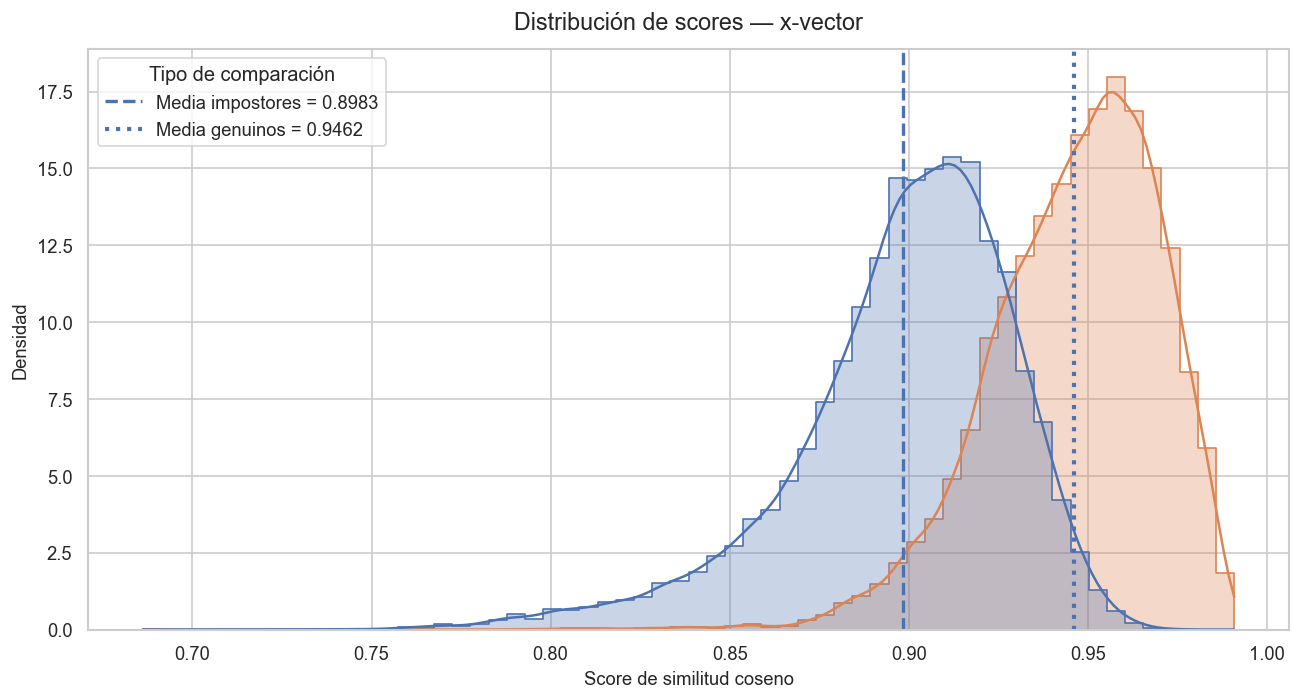

Figura guardada en: c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\evaluation\figures\score_distribution_x_vector.png


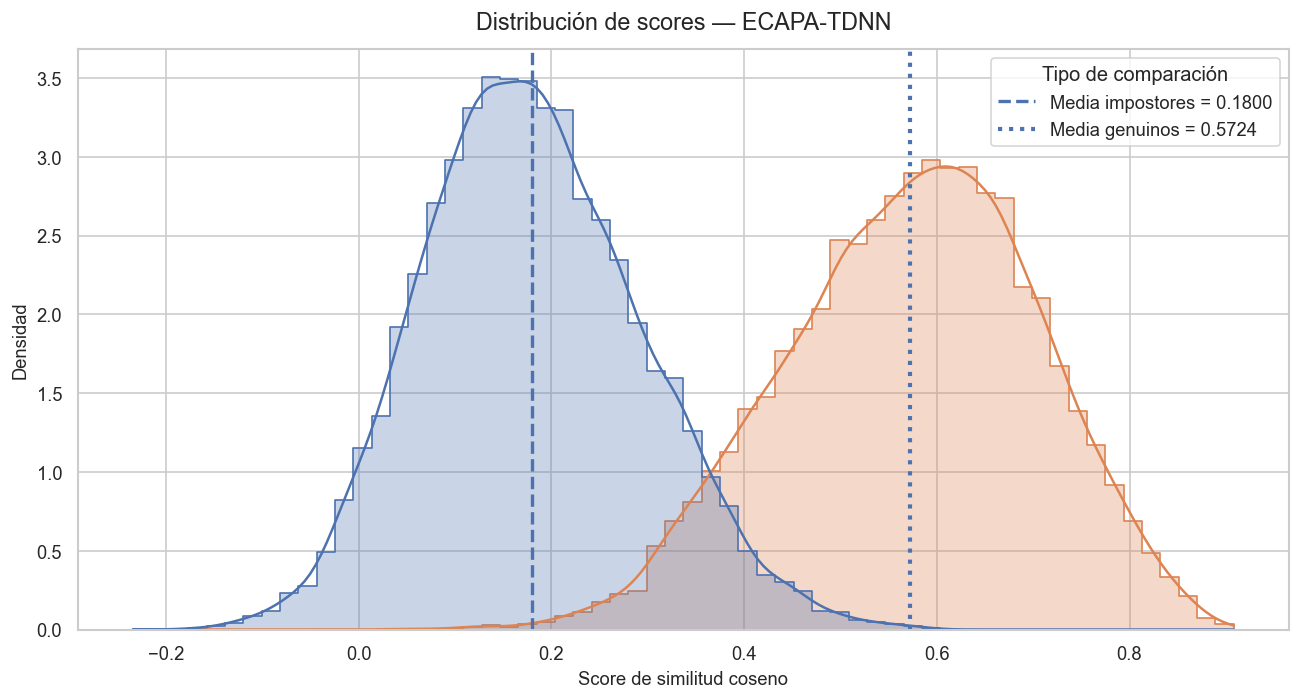

Figura guardada en: c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\evaluation\figures\score_distribution_ecapa_tdnn.png


In [22]:
# Nombre legible de cada clase para las gráficas.
class_names = {
    1: "Genuino",
    0: "Impostor"
}


# Recorremos los dos modelos para crear una gráfica independiente
# para cada columna de scores.
for model_name, score_column in model_score_columns.items():

    # Creamos una tabla temporal con únicamente las variables
    # necesarias para esta representación.
    plot_data = df_eval[
        ["label", score_column]
    ].copy()

    # Convertimos la etiqueta numérica en un nombre comprensible.
    plot_data["tipo_de_trial"] = (
        plot_data["label"]
        .map(class_names)
    )

    # Separamos explícitamente los scores de ambas clases para
    # calcular sus medias y añadirlas como referencias.
    genuine_scores = plot_data.loc[
        plot_data["label"] == 1,
        score_column
    ]

    impostor_scores = plot_data.loc[
        plot_data["label"] == 0,
        score_column
    ]

    genuine_mean = genuine_scores.mean()
    impostor_mean = impostor_scores.mean()





    # Creación de la figura

    fig, ax = plt.subplots(figsize=(11, 6))

    # histplot representa la distribución mediante histogramas.
    #
    # stat="density":
    # normaliza el eje vertical para representar densidades.
    #
    # common_norm=False:
    # normaliza cada clase por separado, evitando que el tamaño
    # de una clase modifique visualmente la otra.
    #
    # element="step":
    # dibuja el contorno de los histogramas para facilitar
    # la observación del traslape.
    #
    # kde=True:
    # agrega una estimación suavizada de la densidad.
    sns.histplot(
        data=plot_data,
        x=score_column,
        hue="tipo_de_trial",
        hue_order=["Impostor", "Genuino"],
        bins=60,
        stat="density",
        common_norm=False,
        element="step",
        kde=True,
        alpha=0.30,
        ax=ax
    )

    # Añadimos líneas verticales para señalar la media
    # de cada distribución.
    ax.axvline(
        impostor_mean,
        linestyle="--",
        linewidth=2,
        label=f"Media impostores = {impostor_mean:.4f}"
    )

    ax.axvline(
        genuine_mean,
        linestyle=":",
        linewidth=2.5,
        label=f"Media genuinos = {genuine_mean:.4f}"
    )






    # Etiquetas y formato

    ax.set_title(
        f"Distribución de scores — {model_name}",
        fontsize=14,
        pad=12
    )

    ax.set_xlabel(
        "Score de similitud coseno",
        fontsize=11
    )

    ax.set_ylabel(
        "Densidad",
        fontsize=11
    )

    ax.legend(
        title="Tipo de comparación"
    )

    plt.tight_layout()

    # Creamos un nombre de archivo sencillo y consistente.
    model_filename = (
        model_name
        .lower()
        .replace("-", "_")
        .replace(" ", "_")
    )

    figure_path = (
        FIGURES_DIR
        / f"score_distribution_{model_filename}.png"
    )

    # Guardamos la figura con alta resolución.
    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(f"Figura guardada en: {figure_path}")


### FUNCIONES DE DISTRIBUCIÓN ACUMULADA EMPÍRICA DE LOS SCORES


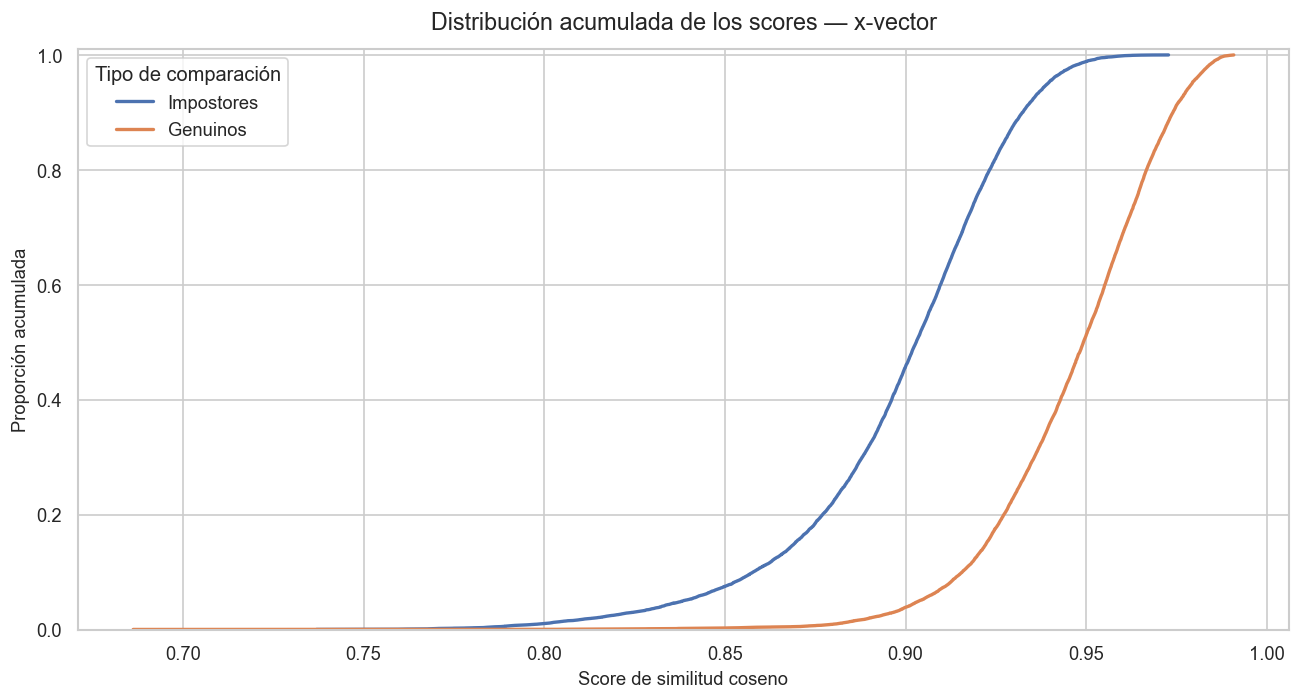

Figura guardada en: c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\evaluation\figures\score_ecdf_x_vector.png


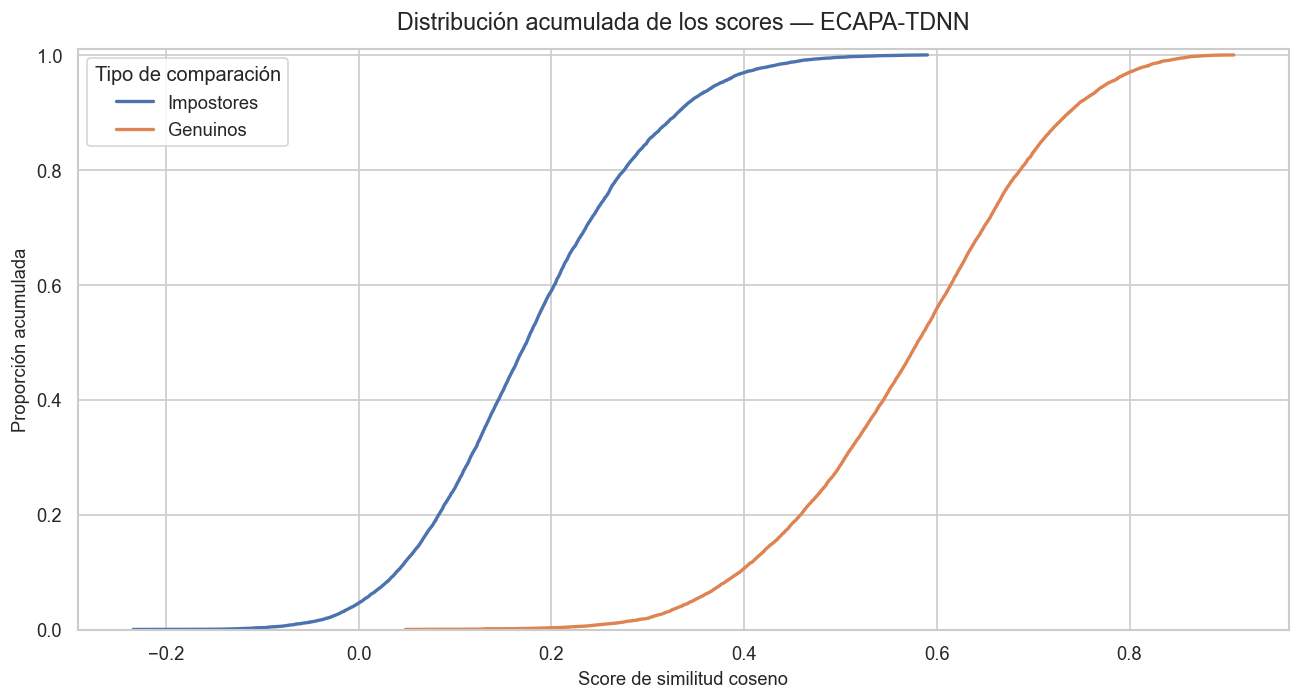

Figura guardada en: c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\evaluation\figures\score_ecdf_ecapa_tdnn.png


In [24]:

def calculate_ecdf(values):
    """
    Calcula la función de distribución acumulada empírica.

    La ECDF indica, para cada valor observado, la proporción
    de observaciones que son menores o iguales que dicho valor.

    Parámetros
    ----------
    values : array-like
        Conjunto de scores que se desea ordenar y acumular.

    Retorna
    -------
    x : numpy.ndarray
        Scores ordenados de menor a mayor.

    y : numpy.ndarray
        Proporción acumulada asociada con cada score.
    """

    # Convertimos los valores en un arreglo de NumPy.
    values = np.asarray(values, dtype=float)

    # Ordenamos los scores de menor a mayor.
    x = np.sort(values)

    # Construimos las proporciones acumuladas:
    #
    # 1/n, 2/n, 3/n, ..., n/n
    y = np.arange(1, len(x) + 1) / len(x)

    return x, y


# Creamos una gráfica independiente para cada modelo.
for model_name, score_column in model_score_columns.items():

    # Separamos los scores genuinos e impostores.
    genuine_scores = df_eval.loc[
        df_eval["label"] == 1,
        score_column
    ].to_numpy()

    impostor_scores = df_eval.loc[
        df_eval["label"] == 0,
        score_column
    ].to_numpy()

    # Calculamos las distribuciones acumuladas.
    genuine_x, genuine_y = calculate_ecdf(genuine_scores)
    impostor_x, impostor_y = calculate_ecdf(impostor_scores)

    # --------------------------------------------------------
    # Creación de la figura
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(11, 6))

    ax.plot(
        impostor_x,
        impostor_y,
        linewidth=2,
        label="Impostores"
    )

    ax.plot(
        genuine_x,
        genuine_y,
        linewidth=2,
        label="Genuinos"
    )

    # --------------------------------------------------------
    # Formato de la gráfica
    # --------------------------------------------------------

    ax.set_title(
        f"Distribución acumulada de los scores — {model_name}",
        fontsize=14,
        pad=12
    )

    ax.set_xlabel(
        "Score de similitud coseno",
        fontsize=11
    )

    ax.set_ylabel(
        "Proporción acumulada",
        fontsize=11
    )

    # La proporción acumulada siempre varía entre 0 y 1.
    ax.set_ylim(0, 1.01)

    ax.legend(
        title="Tipo de comparación"
    )

    plt.tight_layout()

    # --------------------------------------------------------
    # Guardado de la figura
    # --------------------------------------------------------

    model_filename = (
        model_name
        .lower()
        .replace("-", "_")
        .replace(" ", "_")
    )

    figure_path = (
        FIGURES_DIR
        / f"score_ecdf_{model_filename}.png"
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(f"Figura guardada en: {figure_path}")

Para un score específico situado en el eje horizontal, la altura de cada curva indica la proporción de trials con un score menor o igual que dicho valor.

En un sistema con buena discriminación se espera que:

- La curva impostora aumente rápidamente en scores bajos.
- La curva genuina permanezca baja hasta scores más altos.
- Exista una separación horizontal clara entre ambas curvas.

Cuando las curvas recorren regiones de scores muy similares, existe mayor traslape entre las clases y, por lo tanto, mayor dificultad para establecer un umbral de decisión.

---

## 02. Decisión mediante un umbral

Hasta este punto se han analizado los scores como valores continuos. Sin embargo, un sistema de verificación de locutor debe utilizar esos valores para tomar una decisión:

> ¿Las dos grabaciones pertenecen al mismo locutor o a locutores diferentes?

Para convertir un score en una decisión se establece un **umbral** (t).

La regla utilizada será:

$$
\text{Aceptar como mismo locutor si } s \geq t
$$

$$
\text{Rechazar como mismo locutor si } s < t
$$

donde:

* (s) representa el score de similitud.
* (t) representa el umbral de decisión.

Debido a que los scores genuinos deberían ser mayores que los scores impostores, un score situado por encima del umbral será interpretado como evidencia a favor de que las grabaciones pertenecen al mismo locutor.

---

### ¿Qué ocurre al modificar el umbral?

El umbral controla qué tan estricto es el sistema.

#### Umbral bajo

Cuando el umbral es bajo, resulta más sencillo aceptar una comparación como genuina.

Esto produce generalmente:

* Menos rechazos de locutores verdaderos.
* Más aceptaciones incorrectas de impostores.

#### Umbral alto

Cuando el umbral es alto, el sistema exige una similitud mayor para aceptar una comparación.

Esto produce generalmente:

* Menos aceptaciones incorrectas de impostores.
* Más rechazos de locutores verdaderos.

Por lo tanto, no existe un umbral que elimine simultáneamente todos los errores cuando las distribuciones genuina e impostora se traslapan.

---

## Posibles resultados de una decisión

Cada trial tiene una clase real y una decisión producida por el sistema. La combinación de ambos elementos genera cuatro resultados posibles.

| Clase real | Decisión del sistema | Resultado           |
| ---------- | -------------------- | ------------------- |
| Genuino    | Aceptar              | Aceptación correcta |
| Genuino    | Rechazar             | Falso rechazo       |
| Impostor   | Rechazar             | Rechazo correcto    |
| Impostor   | Aceptar              | Falsa aceptación    |

---

### Aceptación correcta

Ocurre cuando las grabaciones pertenecen al mismo locutor y el sistema las acepta como una coincidencia.

También puede denominarse:

* Verdadero positivo.
* *True acceptance*.

---

### Falso rechazo

Ocurre cuando las grabaciones pertenecen al mismo locutor, pero el sistema concluye que pertenecen a locutores diferentes.

Este error se cuantifica mediante la **tasa de falsos rechazos**:

$$
\mathrm{FRR}(t)
=

\frac{\text{número de genuinos rechazados con el umbral }t}
{\text{número total de trials genuinos}}
$$

FRR significa *False Rejection Rate*.

---

### Rechazo correcto

Ocurre cuando las grabaciones pertenecen a locutores diferentes y el sistema rechaza correctamente la supuesta coincidencia.

También puede denominarse:

* Verdadero negativo.
* *True rejection*.

---

### Falsa aceptación

Ocurre cuando las grabaciones pertenecen a locutores diferentes, pero el sistema las acepta incorrectamente como pertenecientes al mismo locutor.

Este error se cuantifica mediante la **tasa de falsas aceptaciones**:

$$
\mathrm{FAR}(t)
=

\frac{\text{número de impostores aceptados con el umbral }t}
{\text{número total de trials impostores}}
$$

FAR significa *False Acceptance Rate*.

En otras referencias esta misma cantidad puede denominarse:

* FMR: *False Match Rate*.
* FPR: *False Positive Rate*.

Aunque los nombres pueden cambiar según el área de aplicación, en este notebook se utilizará principalmente el término **FAR**.

---

## Tasas de acierto complementarias

Además de FAR y FRR, pueden definirse:

### Tasa de aceptación verdadera

$$
\mathrm{TAR}(t)=1-\mathrm{FRR}(t)
$$

Indica la proporción de comparaciones genuinas que son aceptadas correctamente.

### Tasa de rechazo verdadero

$$
\mathrm{TNR}(t)=1-\mathrm{FAR}(t)
$$

Indica la proporción de comparaciones impostoras que son rechazadas correctamente.

---

## Relación esperada entre el umbral y los errores

Al aumentar el umbral:

$$
\mathrm{FAR} \downarrow
$$

porque resulta más difícil que un impostor supere el criterio de aceptación.

Al mismo tiempo:

$$
\mathrm{FRR} \uparrow
$$

porque también resulta más difícil que una comparación genuina supere el umbral.

Este comportamiento opuesto constituye uno de los elementos centrales de la evaluación de sistemas de verificación de locutor.

En la siguiente etapa se implementará una función que calcule FAR, FRR, TAR y TNR para cualquier umbral.


In [25]:

# CÁLCULO DE MÉTRICAS PARA UN UMBRAL DE DECISIÓN

def calculate_threshold_metrics(labels, scores, threshold):
    """
    Calcula las métricas de un sistema de verificación para
    un umbral de decisión específico.

    La regla de decisión utilizada es:

        aceptar como mismo locutor si score >= threshold
        rechazar como mismo locutor si score < threshold

    Parámetros
    ----------
    labels : array-like
        Etiquetas reales de los trials.

        Convención utilizada:
            1 = comparación genuina
            0 = comparación impostora

    scores : array-like
        Scores producidos por el sistema de verificación.

        Se supone que los valores más altos representan una
        mayor similitud entre las grabaciones.

    threshold : float
        Umbral utilizado para convertir los scores continuos
        en decisiones binarias.

    Retorna
    -------
    dict
        Diccionario que contiene:

        - threshold:
          umbral evaluado.

        - true_acceptances:
          genuinos aceptados correctamente.

        - false_rejections:
          genuinos rechazados incorrectamente.

        - true_rejections:
          impostores rechazados correctamente.

        - false_acceptances:
          impostores aceptados incorrectamente.

        - far:
          tasa de falsas aceptaciones.

        - frr:
          tasa de falsos rechazos.

        - tar:
          tasa de aceptación verdadera.

        - tnr:
          tasa de rechazo verdadero.
    """

    # Convertimos las entradas en arreglos de NumPy para
    # realizar operaciones vectorizadas.
    labels = np.asarray(labels)
    scores = np.asarray(scores, dtype=float)

    # --------------------------------------------------------
    # Validaciones básicas
    # --------------------------------------------------------

    # Debe existir una etiqueta por cada score.
    if len(labels) != len(scores):
        raise ValueError(
            "El número de etiquetas debe coincidir con "
            "el número de scores."
        )

    # Solo se permiten las etiquetas binarias 0 y 1.
    valid_labels = np.isin(labels, [0, 1])

    if not valid_labels.all():
        raise ValueError(
            "Las etiquetas deben contener únicamente "
            "los valores 0 y 1."
        )

    # El conjunto debe contener al menos un trial genuino
    # y un trial impostor para poder calcular todas las tasas.
    n_genuine = int((labels == 1).sum())
    n_impostor = int((labels == 0).sum())

    if n_genuine == 0:
        raise ValueError(
            "No existen trials genuinos en los datos."
        )

    if n_impostor == 0:
        raise ValueError(
            "No existen trials impostores en los datos."
        )

    # --------------------------------------------------------
    # Decisiones del sistema
    # --------------------------------------------------------

    # Una decisión igual a True significa que el sistema
    # acepta la hipótesis de mismo locutor.
    accepted = scores >= threshold

    # Una decisión igual a False significa que el sistema
    # rechaza la hipótesis de mismo locutor.
    rejected = scores < threshold

    # --------------------------------------------------------
    # Conteos de los cuatro resultados posibles
    # --------------------------------------------------------

    # Genuinos aceptados correctamente.
    true_acceptances = int(
        ((labels == 1) & accepted).sum()
    )

    # Genuinos rechazados incorrectamente.
    false_rejections = int(
        ((labels == 1) & rejected).sum()
    )

    # Impostores rechazados correctamente.
    true_rejections = int(
        ((labels == 0) & rejected).sum()
    )

    # Impostores aceptados incorrectamente.
    false_acceptances = int(
        ((labels == 0) & accepted).sum()
    )

    # --------------------------------------------------------
    # Tasas de error y de acierto
    # --------------------------------------------------------

    # FAR:
    # proporción de impostores aceptados incorrectamente.
    far = false_acceptances / n_impostor

    # FRR:
    # proporción de genuinos rechazados incorrectamente.
    frr = false_rejections / n_genuine

    # TAR:
    # proporción de genuinos aceptados correctamente.
    tar = true_acceptances / n_genuine

    # TNR:
    # proporción de impostores rechazados correctamente.
    tnr = true_rejections / n_impostor

    # --------------------------------------------------------
    # Verificaciones internas
    # --------------------------------------------------------

    # Todo trial genuino debe ser aceptado o rechazado.
    if true_acceptances + false_rejections != n_genuine:
        raise RuntimeError(
            "Los conteos de trials genuinos no son consistentes."
        )

    # Todo trial impostor debe ser aceptado o rechazado.
    if true_rejections + false_acceptances != n_impostor:
        raise RuntimeError(
            "Los conteos de trials impostores no son consistentes."
        )

    # Las tasas complementarias deben sumar aproximadamente 1.
    if not np.isclose(tar + frr, 1.0):
        raise RuntimeError(
            "TAR y FRR no son complementarias."
        )

    if not np.isclose(tnr + far, 1.0):
        raise RuntimeError(
            "TNR y FAR no son complementarias."
        )

    # Devolvemos todos los resultados en un diccionario.
    return {
        "threshold": float(threshold),
        "n_genuine": n_genuine,
        "n_impostor": n_impostor,
        "true_acceptances": true_acceptances,
        "false_rejections": false_rejections,
        "true_rejections": true_rejections,
        "false_acceptances": false_acceptances,
        "far": float(far),
        "frr": float(frr),
        "tar": float(tar),
        "tnr": float(tnr)
    }


In [31]:
# CÁLCULO DE MÉTRICAS PARA TODOS LOS UMBRALES

def calculate_threshold_curve(labels, scores):
    """
    Calcula las métricas de verificación para todos los umbrales
    relevantes presentes en un conjunto de scores.

    La regla de decisión es:

        aceptar como mismo locutor si score >= threshold
        rechazar como mismo locutor si score < threshold

    Parámetros
    ----------
    labels : array-like
        Etiquetas reales de los trials:

            1 = comparación genuina
            0 = comparación impostora

    scores : array-like
        Scores producidos por un sistema de verificación.

    Retorna
    -------
    pandas.DataFrame
        Tabla con una fila por umbral y las siguientes métricas:

        - threshold
        - true_acceptances
        - false_rejections
        - true_rejections
        - false_acceptances
        - far
        - frr
        - tar
        - tnr
    """

    # Convertimos las entradas a arreglos de NumPy.
    labels = np.asarray(labels, dtype=int)
    scores = np.asarray(scores, dtype=float)

    # --------------------------------------------------------
    # Validaciones básicas
    # --------------------------------------------------------

    if len(labels) != len(scores):
        raise ValueError(
            "El número de etiquetas debe coincidir con "
            "el número de scores."
        )

    if not np.isin(labels, [0, 1]).all():
        raise ValueError(
            "Las etiquetas deben contener únicamente 0 y 1."
        )

    if not np.isfinite(scores).all():
        raise ValueError(
            "Los scores contienen valores faltantes o infinitos."
        )

    if not np.any(labels == 1):
        raise ValueError(
            "No existen trials genuinos."
        )

    if not np.any(labels == 0):
        raise ValueError(
            "No existen trials impostores."
        )

    # --------------------------------------------------------
    # Construcción de los umbrales
    # --------------------------------------------------------

    # Utilizamos todos los valores únicos observados como
    # posibles umbrales de decisión.
    unique_scores = np.sort(np.unique(scores))

    # Añadimos dos extremos:
    #
    # - Un umbral menor que el score mínimo:
    #   todos los trials serán aceptados.
    #
    # - Un umbral mayor que el score máximo:
    #   todos los trials serán rechazados.
    #
    # np.nextafter obtiene el número representable
    # inmediatamente anterior o posterior.
    lower_threshold = np.nextafter(
        unique_scores[0],
        -np.inf
    )

    upper_threshold = np.nextafter(
        unique_scores[-1],
        np.inf
    )

    thresholds = np.concatenate([
        [lower_threshold],
        unique_scores,
        [upper_threshold]
    ])

    # --------------------------------------------------------
    # Cálculo eficiente de los conteos
    # --------------------------------------------------------

    # Separamos los scores genuinos e impostores.
    genuine_scores = np.sort(
        scores[labels == 1]
    )

    impostor_scores = np.sort(
        scores[labels == 0]
    )

    n_genuine = len(genuine_scores)
    n_impostor = len(impostor_scores)

    # np.searchsorted(..., side="left") indica cuántos valores
    # son estrictamente menores que cada umbral.
    #
    # En los genuinos, esos valores corresponden a falsos
    # rechazos porque score < threshold.
    false_rejections = np.searchsorted(
        genuine_scores,
        thresholds,
        side="left"
    )

    # En los impostores, los valores menores que el umbral
    # corresponden a rechazos correctos.
    true_rejections = np.searchsorted(
        impostor_scores,
        thresholds,
        side="left"
    )

    # Los demás genuinos son aceptaciones correctas.
    true_acceptances = (
        n_genuine - false_rejections
    )

    # Los demás impostores son falsas aceptaciones.
    false_acceptances = (
        n_impostor - true_rejections
    )

    # --------------------------------------------------------
    # Tasas de error y acierto
    # --------------------------------------------------------

    far = false_acceptances / n_impostor
    frr = false_rejections / n_genuine
    tar = true_acceptances / n_genuine
    tnr = true_rejections / n_impostor

    # Construimos la tabla final.
    threshold_table = pd.DataFrame({
        "threshold": thresholds,
        "n_genuine": n_genuine,
        "n_impostor": n_impostor,
        "true_acceptances": true_acceptances,
        "false_rejections": false_rejections,
        "true_rejections": true_rejections,
        "false_acceptances": false_acceptances,
        "far": far,
        "frr": frr,
        "tar": tar,
        "tnr": tnr
    })

    return threshold_table

In [ ]:
# CÁLCULO PARA LOS DOS MODELOS

threshold_metrics = {}

for model_name, score_column in model_score_columns.items():

    model_threshold_table = calculate_threshold_curve(
        labels=df_eval["label"].to_numpy(dtype=int),
        scores=df_eval[score_column].to_numpy(dtype=float)
    )

    threshold_metrics[model_name] = model_threshold_table

    print("=" * 70)
    print(f"MÉTRICAS POR UMBRAL — {model_name}")
    print("=" * 70)

    print(
        f"Número de umbrales evaluados: "
        f"{len(model_threshold_table):,}"
    )

    print(
        f"Rango de umbrales: "
        f"{model_threshold_table['threshold'].min():.6f} a "
        f"{model_threshold_table['threshold'].max():.6f}"
    )

MÉTRICAS POR UMBRAL — x-vector
Número de umbrales evaluados: 26,122
Rango de umbrales: 0.686189 a 0.990851
MÉTRICAS POR UMBRAL — ECAPA-TDNN
Número de umbrales evaluados: 26,315
Rango de umbrales: -0.233926 a 0.908164



### CURVAS FAR Y FRR EN FUNCIÓN DEL UMBRAL

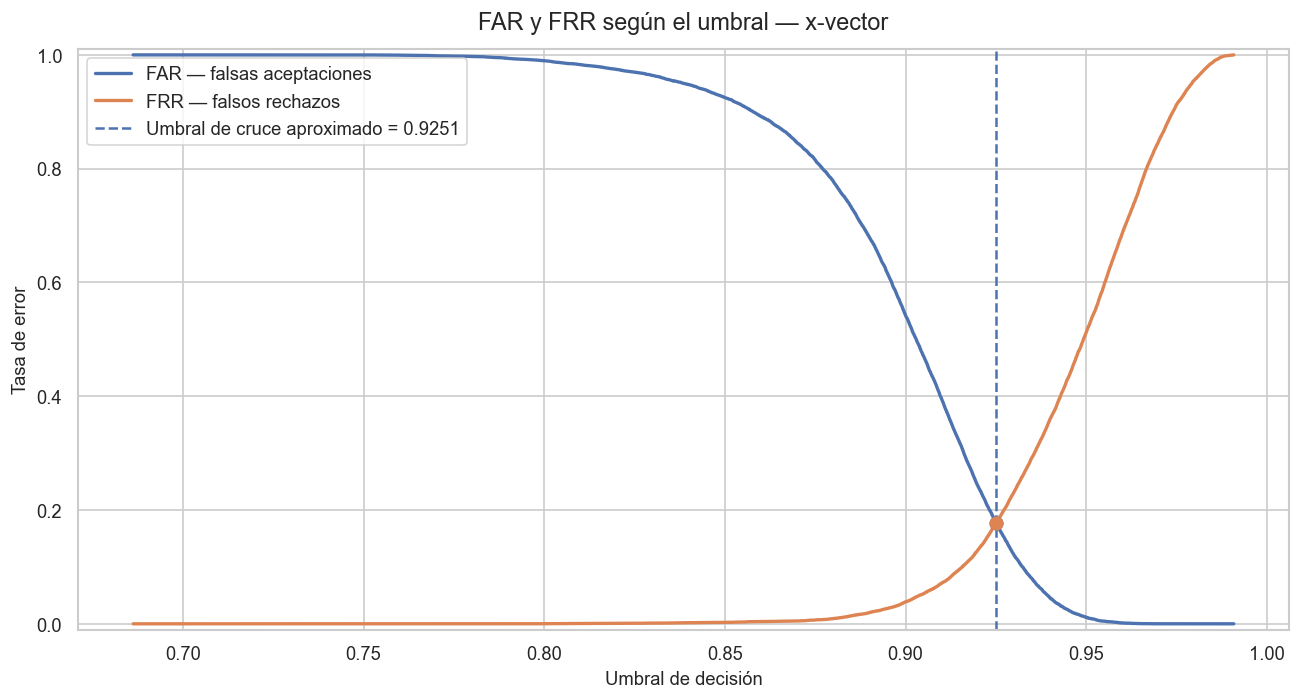

PUNTO DE CRUCE APROXIMADO — x-vector
Umbral observado: 0.925092
FAR:               17.766806%
FRR:               17.766806%
Diferencia absoluta: 0.00000000

Figura guardada en: c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\evaluation\figures\far_frr_vs_threshold_x_vector.png



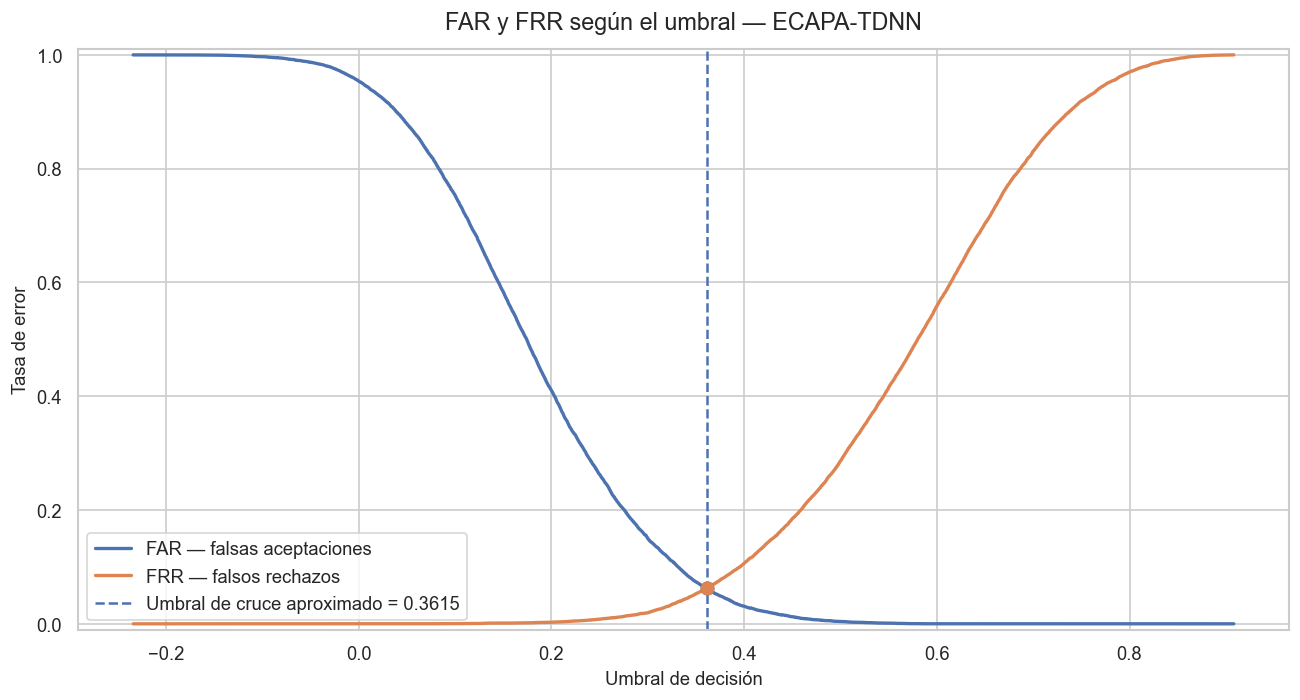

PUNTO DE CRUCE APROXIMADO — ECAPA-TDNN
Umbral observado: 0.361467
FAR:               6.259020%
FRR:               6.259020%
Diferencia absoluta: 0.00000000

Figura guardada en: c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\evaluation\figures\far_frr_vs_threshold_ecapa_tdnn.png



In [36]:

for model_name, threshold_table in threshold_metrics.items():

    # --------------------------------------------------------
    # Creación de la figura
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(11, 6))

    # FAR:
    # proporción de trials impostores aceptados incorrectamente.
    ax.plot(
        threshold_table["threshold"],
        threshold_table["far"],
        linewidth=2,
        label="FAR — falsas aceptaciones"
    )

    # FRR:
    # proporción de trials genuinos rechazados incorrectamente.
    ax.plot(
        threshold_table["threshold"],
        threshold_table["frr"],
        linewidth=2,
        label="FRR — falsos rechazos"
    )


    # --------------------------------------------------------
    # Punto de mayor proximidad entre FAR y FRR
    # --------------------------------------------------------

    # Por ahora utilizamos únicamente el punto observado donde
    # la diferencia absoluta entre ambas tasas es menor.
    #
    # Este punto sirve como referencia visual. En la siguiente
    # sección calcularemos formalmente el EER mediante un
    # procedimiento más preciso.
    absolute_difference = np.abs(
        threshold_table["far"]
        - threshold_table["frr"]
    )

    closest_index = absolute_difference.idxmin()

    closest_row = threshold_table.loc[closest_index]

    reference_threshold = closest_row["threshold"]
    reference_far = closest_row["far"]
    reference_frr = closest_row["frr"]

    # Línea vertical que muestra el umbral de cruce aproximado.
    ax.axvline(
        reference_threshold,
        linestyle="--",
        linewidth=1.5,
        label=(
            "Umbral de cruce aproximado "
            f"= {reference_threshold:.4f}"
        )
    )

    # Marcamos sobre las curvas los valores correspondientes.
    ax.scatter(
        reference_threshold,
        reference_far,
        s=55,
        zorder=3
    )

    ax.scatter(
        reference_threshold,
        reference_frr,
        s=55,
        zorder=3
    )


    # --------------------------------------------------------
    # Formato de la gráfica
    # --------------------------------------------------------

    ax.set_title(
        f"FAR y FRR según el umbral — {model_name}",
        fontsize=14,
        pad=12
    )

    ax.set_xlabel(
        "Umbral de decisión",
        fontsize=11
    )

    ax.set_ylabel(
        "Tasa de error",
        fontsize=11
    )

    # FAR y FRR siempre toman valores entre 0 y 1.
    ax.set_ylim(-0.01, 1.01)

    ax.legend()

    plt.tight_layout()


    # --------------------------------------------------------
    # Guardado de la figura
    # --------------------------------------------------------

    model_filename = (
        model_name
        .lower()
        .replace("-", "_")
        .replace(" ", "_")
    )

    figure_path = (
        FIGURES_DIR
        / f"far_frr_vs_threshold_{model_filename}.png"
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


    # --------------------------------------------------------
    # Resumen numérico del punto observado
    # --------------------------------------------------------

    print("=" * 70)
    print(f"PUNTO DE CRUCE APROXIMADO — {model_name}")
    print("=" * 70)

    print(f"Umbral observado: {reference_threshold:.6f}")
    print(f"FAR:               {reference_far:.6%}")
    print(f"FRR:               {reference_frr:.6%}")
    print(
        "Diferencia absoluta: "
        f"{abs(reference_far - reference_frr):.8f}"
    )

    print(f"\nFigura guardada en: {figure_path}\n")


Al desplazarnos hacia umbrales mayores:

- La curva FAR debe descender, porque cada vez menos impostores superan el criterio de aceptación.
- La curva FRR debe ascender, porque cada vez más comparaciones genuinas quedan por debajo del umbral.

La región donde ambas curvas se aproximan está relacionada con el Equal Error Rate.

## 03. Equal Error Rate

El **Equal Error Rate**, abreviado como **EER**, es una de las métricas más utilizadas para resumir el desempeño de un sistema de verificación de locutor.

Su objetivo es localizar el punto de operación donde las dos tasas principales de error son iguales o lo más próximas posible:

$$
\mathrm{FAR}(t_{\mathrm{EER}})
\approx
\mathrm{FRR}(t_{\mathrm{EER}})
$$

donde:

* $(\mathrm{FAR})$ es la tasa de falsas aceptaciones.
* $(\mathrm{FRR})$ es la tasa de falsos rechazos.
* $(t_{\mathrm{EER}})$ es el umbral asociado con el EER.

En ese punto, el sistema comete aproximadamente la misma proporción de errores con comparaciones impostoras y genuinas.

---

### Interpretación del EER

Supongamos que un sistema obtiene:

$$
\mathrm{EER}=0.08
$$

Esto equivale a un EER del (8%).

De manera aproximada, significa que en el umbral correspondiente:

* El (8%) de los trials impostores sería aceptado incorrectamente.
* El (8%) de los trials genuinos sería rechazado incorrectamente.

Un valor menor de EER indica, en general, una mejor capacidad de discriminación.

Por ejemplo:

| Sistema   |   EER | Interpretación general |
| --------- | ----: | ---------------------- |
| Sistema A |  (5%) | Menor tasa de error    |
| Sistema B | (12%) | Mayor tasa de error    |

Bajo este criterio, el sistema A presenta mejor desempeño global.

---

### Relación con las distribuciones de scores

El EER depende del traslape entre las distribuciones genuina e impostora.

Cuando existe una separación clara:

* La mayoría de los scores genuinos queda por encima del umbral.
* La mayoría de los scores impostores queda por debajo.
* FAR y FRR pueden alcanzar valores pequeños.
* El EER tiende a ser bajo.

Cuando las distribuciones se traslapan considerablemente:

* Algunos impostores reciben scores altos.
* Algunos genuinos reciben scores bajos.
* No es posible disminuir simultáneamente ambas tasas de error.
* El EER tiende a aumentar.

Por lo tanto, el EER proporciona un resumen de la capacidad del modelo para ordenar correctamente comparaciones genuinas e impostoras.

---

### ¿Por qué puede no existir una igualdad exacta?

Los scores disponibles forman un conjunto finito. Al mover el umbral de un score observado al siguiente, FAR y FRR cambian en pequeños saltos.

Por esta razón, puede no existir un umbral para el cual:

$$
\mathrm{FAR}=\mathrm{FRR}
$$

de manera exacta.

Podrían observarse, por ejemplo, dos puntos consecutivos:

$$
\mathrm{FAR}=0.074,
\qquad
\mathrm{FRR}=0.071
$$

y posteriormente:

$$
\mathrm{FAR}=0.070,
\qquad
\mathrm{FRR}=0.075
$$

En este caso, el cruce teórico se encuentra entre ambos umbrales.

Para obtener una estimación más precisa se utilizará **interpolación lineal** entre los puntos que rodean el cambio de signo de:

$$
\mathrm{FAR}-\mathrm{FRR}
$$

---

### Cálculo observado e interpolado

#### EER observado

Se obtiene seleccionando el umbral disponible donde la diferencia absoluta sea mínima:

$$
\underset{t}{\operatorname{argmin}}
\left|
\mathrm{FAR}(t)-\mathrm{FRR}(t)
\right|
$$

Este valor corresponde a un umbral realmente evaluado.

#### EER interpolado

Se estima el punto de cruce entre FAR y FRR utilizando los dos umbrales consecutivos que rodean la igualdad.

Este procedimiento permite obtener una aproximación más precisa, aunque el umbral interpolado no necesariamente coincide con uno de los scores observados.

En los resultados se conservarán ambos valores para mantener transparencia sobre el procedimiento utilizado.

---

### El umbral del EER no es universal

El umbral asociado al EER trata ambos tipos de error de forma simétrica.

Esto supone implícitamente que:

* Una falsa aceptación y un falso rechazo tienen una importancia comparable.
* No existe una preferencia particular por reducir alguno de los dos errores.

Sin embargo, esta condición no siempre es apropiada.

En un sistema de alta seguridad, una falsa aceptación puede considerarse mucho más grave que un falso rechazo. En ese contexto sería preferible utilizar un umbral más alto que el umbral del EER.

En otras aplicaciones, como un sistema de acceso de baja criticidad, podría ser aceptable tolerar más falsas aceptaciones para disminuir la cantidad de usuarios legítimos rechazados.

Por lo tanto:

> El EER es una métrica útil para comparar sistemas, pero su umbral no debe interpretarse automáticamente como el mejor umbral para cualquier aplicación.

Más adelante se incorporará la función de costo de detección, que permitirá asignar diferente importancia a cada tipo de error.

---

### Comparación entre modelos

Para x-vector y ECAPA-TDNN se calcularán:

* EER observado.
* EER interpolado.
* Umbral observado.
* Umbral interpolado.
* FAR en el punto observado.
* FRR en el punto observado.
* Diferencia absoluta entre FAR y FRR.

El modelo con menor EER tendrá mejor desempeño bajo este criterio.

No obstante, la comparación final también considerará:

* ROC-AUC.
* Curvas DET.
* minDCF.
* $(C_{\mathrm{llr}})$.
* Diagramas de Tippett.
* Incertidumbre estadística.

De esta forma, la conclusión no dependerá de una sola métrica.


In [37]:
# CÁLCULO DEL EQUAL ERROR RATE

def calculate_eer(threshold_table):
    """
    Calcula el Equal Error Rate observado e interpolado a partir
    de una tabla de métricas evaluadas para distintos umbrales.

    Parámetros
    ----------
    threshold_table : pandas.DataFrame
        Tabla que debe contener las columnas:

        - threshold
        - far
        - frr

    Retorna
    -------
    dict
        Diccionario con:

        - eer_observed:
          EER aproximado en el umbral realmente observado donde
          FAR y FRR presentan la menor diferencia.

        - threshold_observed:
          Umbral asociado con el EER observado.

        - far_observed:
          FAR en el umbral observado.

        - frr_observed:
          FRR en el umbral observado.

        - absolute_difference:
          Diferencia absoluta entre FAR y FRR.

        - eer_interpolated:
          EER estimado mediante interpolación lineal.

        - threshold_interpolated:
          Umbral estimado mediante interpolación lineal.

        - interpolation_used:
          Indica si fue posible realizar la interpolación.
    """

    # --------------------------------------------------------
    # Validación de las columnas requeridas
    # --------------------------------------------------------

    required_columns = [
        "threshold",
        "far",
        "frr"
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in threshold_table.columns
    ]

    if missing_columns:
        raise ValueError(
            "Faltan las siguientes columnas en la tabla: "
            f"{missing_columns}"
        )


    # --------------------------------------------------------
    # Preparación y ordenamiento de los datos
    # --------------------------------------------------------

    # Ordenamos la tabla por umbral para garantizar que FAR
    # descienda y FRR ascienda de manera secuencial.
    eer_table = (
        threshold_table[required_columns]
        .sort_values("threshold")
        .reset_index(drop=True)
        .copy()
    )

    # Diferencia entre las dos tasas de error.
    #
    # En umbrales bajos se espera:
    #   FAR > FRR  -> diferencia positiva.
    #
    # En umbrales altos se espera:
    #   FAR < FRR  -> diferencia negativa.
    eer_table["difference"] = (
        eer_table["far"]
        - eer_table["frr"]
    )

    eer_table["absolute_difference"] = (
        eer_table["difference"].abs()
    )


    # --------------------------------------------------------
    # EER observado
    # --------------------------------------------------------

    # Localizamos el umbral observado donde FAR y FRR tienen
    # la menor diferencia absoluta.
    observed_position = (
        eer_table["absolute_difference"]
        .to_numpy()
        .argmin()
    )

    observed_row = eer_table.iloc[observed_position]

    threshold_observed = float(
        observed_row["threshold"]
    )

    far_observed = float(
        observed_row["far"]
    )

    frr_observed = float(
        observed_row["frr"]
    )

    absolute_difference = float(
        observed_row["absolute_difference"]
    )

    # Cuando FAR y FRR no son exactamente iguales, utilizamos
    # su promedio como aproximación del EER observado.
    eer_observed = (
        far_observed + frr_observed
    ) / 2


    # --------------------------------------------------------
    # Búsqueda del intervalo donde ocurre el cruce
    # --------------------------------------------------------

    differences = eer_table[
        "difference"
    ].to_numpy()

    # Buscamos dos puntos consecutivos donde:
    #
    #   FAR - FRR >= 0
    #
    # y después:
    #
    #   FAR - FRR <= 0
    #
    # Esto indica que el cruce se encuentra entre ambos.
    crossing_positions = np.where(
        (differences[:-1] >= 0)
        &
        (differences[1:] <= 0)
    )[0]


    # --------------------------------------------------------
    # Interpolación lineal
    # --------------------------------------------------------

    interpolation_used = False

    # Por defecto, si no fuera posible interpolar, se utilizarán
    # los resultados del punto observado.
    eer_interpolated = eer_observed
    threshold_interpolated = threshold_observed
    far_interpolated = far_observed
    frr_interpolated = frr_observed

    if len(crossing_positions) > 0:

        # Seleccionamos el primer intervalo donde aparece
        # el cambio de signo.
        lower_position = crossing_positions[0]
        upper_position = lower_position + 1

        lower_row = eer_table.iloc[lower_position]
        upper_row = eer_table.iloc[upper_position]

        threshold_lower = float(
            lower_row["threshold"]
        )

        threshold_upper = float(
            upper_row["threshold"]
        )

        difference_lower = float(
            lower_row["difference"]
        )

        difference_upper = float(
            upper_row["difference"]
        )

        far_lower = float(
            lower_row["far"]
        )

        far_upper = float(
            upper_row["far"]
        )

        frr_lower = float(
            lower_row["frr"]
        )

        frr_upper = float(
            upper_row["frr"]
        )


        # Si uno de los puntos ya representa igualdad exacta,
        # no es necesario calcular una posición intermedia.
        if np.isclose(difference_lower, 0.0):

            threshold_interpolated = threshold_lower
            far_interpolated = far_lower
            frr_interpolated = frr_lower
            interpolation_used = False

        elif np.isclose(difference_upper, 0.0):

            threshold_interpolated = threshold_upper
            far_interpolated = far_upper
            frr_interpolated = frr_upper
            interpolation_used = False

        else:

            # Factor de interpolación.
            #
            # alpha indica qué proporción del intervalo entre
            # los dos puntos es necesaria para llegar a:
            #
            # FAR - FRR = 0
            alpha = (
                difference_lower
                /
                (difference_lower - difference_upper)
            )

            threshold_interpolated = (
                threshold_lower
                + alpha
                * (threshold_upper - threshold_lower)
            )

            far_interpolated = (
                far_lower
                + alpha
                * (far_upper - far_lower)
            )

            frr_interpolated = (
                frr_lower
                + alpha
                * (frr_upper - frr_lower)
            )

            interpolation_used = True

        # En el punto de cruce ambas tasas deberían ser
        # aproximadamente iguales.
        eer_interpolated = (
            far_interpolated + frr_interpolated
        ) / 2


    # --------------------------------------------------------
    # Resultados
    # --------------------------------------------------------

    return {
        "eer_observed": float(eer_observed),
        "threshold_observed": float(threshold_observed),
        "far_observed": float(far_observed),
        "frr_observed": float(frr_observed),
        "absolute_difference": float(absolute_difference),
        "eer_interpolated": float(eer_interpolated),
        "threshold_interpolated": float(
            threshold_interpolated
        ),
        "far_interpolated": float(far_interpolated),
        "frr_interpolated": float(frr_interpolated),
        "interpolation_used": interpolation_used
    }

In [38]:
# CÁLCULO DEL EER PARA AMBOS MODELOS

eer_results_list = []

for model_name, threshold_table in threshold_metrics.items():

    model_eer = calculate_eer(
        threshold_table=threshold_table
    )

    model_eer["modelo"] = model_name

    eer_results_list.append(model_eer)


# Convertimos los resultados en una tabla.
eer_results = pd.DataFrame(
    eer_results_list
)


# Reordenamos las columnas para facilitar su lectura.
eer_results = eer_results[
    [
        "modelo",
        "eer_observed",
        "threshold_observed",
        "far_observed",
        "frr_observed",
        "absolute_difference",
        "eer_interpolated",
        "threshold_interpolated",
        "far_interpolated",
        "frr_interpolated",
        "interpolation_used"
    ]
]


# ============================================================
# PRESENTACIÓN DE RESULTADOS
# ============================================================

print("=" * 80)
print("RESULTADOS DEL EQUAL ERROR RATE")
print("=" * 80)

display(
    eer_results.style.format({
        "eer_observed": "{:.6%}",
        "threshold_observed": "{:.6f}",
        "far_observed": "{:.6%}",
        "frr_observed": "{:.6%}",
        "absolute_difference": "{:.8f}",
        "eer_interpolated": "{:.6%}",
        "threshold_interpolated": "{:.6f}",
        "far_interpolated": "{:.6%}",
        "frr_interpolated": "{:.6%}"
    })
)

RESULTADOS DEL EQUAL ERROR RATE


,modelo,eer_observed,threshold_observed,far_observed,frr_observed,absolute_difference,eer_interpolated,threshold_interpolated,far_interpolated,frr_interpolated,interpolation_used
0,x-vector,17.766806%,0.925092,17.766806%,17.766806%,0.00000000,17.766806%,0.925092,17.766806%,17.766806%,False
1,ECAPA-TDNN,6.259020%,0.361467,6.259020%,6.259020%,0.00000000,6.259020%,0.361467,6.259020%,6.259020%,False


## 04. Curva ROC y área bajo la curva

El Equal Error Rate resume el comportamiento de un sistema en un punto particular de operación. Sin embargo, un sistema de verificación puede utilizar muchos umbrales diferentes.

Para estudiar su desempeño a través de todos esos umbrales se utiliza la **curva ROC**.

ROC significa:

$$
\textit{Receiver Operating Characteristic}
$$

Esta curva representa la relación entre:

* La tasa de verdaderas aceptaciones.
* La tasa de falsas aceptaciones.

para todos los posibles umbrales de decisión.

---

### Ejes de la curva ROC

El eje horizontal representa la tasa de falsos positivos:

$$
\mathrm{FPR}
=

\frac{\text{impostores aceptados incorrectamente}}
{\text{total de trials impostores}}
$$

En este proyecto, esta cantidad es equivalente a:

$$
\mathrm{FPR}=\mathrm{FAR}
$$

El eje vertical representa la tasa de verdaderos positivos:

$$
\mathrm{TPR}
=

\frac{\text{genuinos aceptados correctamente}}
{\text{total de trials genuinos}}
$$

En verificación de locutor también puede denominarse:

$$
\mathrm{TPR}=\mathrm{TAR}
$$

Por lo tanto, la curva ROC representa:

$$
\mathrm{TAR}
\quad \text{frente a} \quad
\mathrm{FAR}
$$

---

## Relación con el umbral

Cada punto de la curva ROC corresponde a un umbral diferente.

### Umbral muy bajo

Si el umbral es menor que prácticamente todos los scores:

* Se aceptan casi todos los trials genuinos.
* También se aceptan casi todos los impostores.

En ese caso:

$$
\mathrm{TAR}\approx 1
$$

y

$$
\mathrm{FAR}\approx 1
$$

### Umbral muy alto

Si el umbral es mayor que prácticamente todos los scores:

* Se rechazan casi todos los impostores.
* También se rechazan casi todos los genuinos.

En ese caso:

$$
\mathrm{TAR}\approx 0
$$

y

$$
\mathrm{FAR}\approx 0
$$

Entre ambos extremos, el umbral genera diferentes combinaciones de aceptación correcta y falsa aceptación.

---

## Interpretación de una curva ROC

Un sistema con buena capacidad de discriminación debería alcanzar una tasa alta de verdaderas aceptaciones manteniendo una tasa baja de falsas aceptaciones.

Por esta razón, una buena curva ROC tiende a acercarse a la esquina superior izquierda de la gráfica:

$$
(\mathrm{FAR}=0,\ \mathrm{TAR}=1)
$$

Ese punto representaría un sistema ideal que:

* Acepta correctamente todos los trials genuinos.
* Rechaza correctamente todos los trials impostores.

La línea diagonal:

$$
\mathrm{TAR}=\mathrm{FAR}
$$

representa el comportamiento aproximado de un sistema que no puede distinguir entre ambas clases y toma decisiones equivalentes a una elección aleatoria.

---

## Área bajo la curva

La curva ROC puede resumirse mediante el **área bajo la curva**, denominada AUC:

$$
\mathrm{AUC}
=

\textit{Area Under the Curve}
$$

La AUC toma valores entre 0 y 1.

En términos generales:

* Un valor cercano a (1) indica una alta capacidad de discriminación.
* Un valor cercano a (0.5) indica un comportamiento similar al azar.
* Un valor menor que (0.5) puede indicar que la dirección de los scores está invertida.

Una interpretación probabilística de la AUC es:

> La probabilidad de que un trial genuino seleccionado aleatoriamente reciba un score mayor que un trial impostor seleccionado aleatoriamente.

Por ejemplo:

$$
\mathrm{AUC}=0.95
$$

indica que, aproximadamente en el (95%) de las parejas formadas por un genuino y un impostor, el genuino recibe el score más alto.

---

## Diferencia entre AUC y EER

Aunque ambas métricas evalúan discriminación, no representan exactamente lo mismo.

### EER

* Resume el sistema cerca del punto donde FAR y FRR son iguales.
* Se expresa como una tasa de error.
* Un valor menor representa mejor desempeño.

### AUC

* Resume el ordenamiento de los scores a través de todos los umbrales.
* Se expresa como un área.
* Un valor mayor representa mejor desempeño.

Un modelo puede presentar una AUC alta, pero no necesariamente ofrecer el mejor comportamiento en una región operativa específica, por ejemplo, cuando se exige una FAR extremadamente pequeña.

Por esta razón, además de calcular la AUC global, posteriormente se examinará con mayor atención la región de bajas tasas de falsas aceptaciones.

---

## Limitaciones de la AUC

La AUC no depende de un único umbral, lo cual es una ventaja para comparar modelos de manera general.

Sin embargo, también presenta limitaciones:

* Resume toda la curva en un solo número.
* Otorga importancia a regiones que podrían no ser relevantes para una aplicación concreta.
* No incorpora costos diferentes para falsas aceptaciones y falsos rechazos.
* No evalúa la calibración de los scores.
* No indica directamente qué umbral debe utilizarse.

Por esta razón, la AUC se interpretará conjuntamente con:

* EER.
* Curva DET.
* minDCF.
* $(C_{\mathrm{llr}})$.
* Diagramas de Tippett.


In [40]:
# CÁLCULO DE LAS CURVAS ROC Y DEL ÁREA BAJO LA CURVA


# Las etiquetas reales son comunes para ambos sistemas:
#
#   1 = trial genuino
#   0 = trial impostor
y_true = df_eval["label"].to_numpy(dtype=int)


# Este diccionario almacenará, para cada modelo:
#
# - Los puntos de la curva ROC.
# - Los umbrales asociados.
# - El valor de AUC.
roc_results = {}

# Esta lista se utilizará para construir una tabla resumen.
roc_summary_rows = []


for model_name, score_column in model_score_columns.items():

    # Extraemos los scores del modelo actual.
    y_scores = df_eval[
        score_column
    ].to_numpy(dtype=float)

    # --------------------------------------------------------
    # Cálculo de la curva ROC
    # --------------------------------------------------------

    # roc_curve calcula, para diferentes umbrales:
    #
    # fpr:
    #   False Positive Rate.
    #   En este proyecto equivale a FAR.
    #
    # tpr:
    #   True Positive Rate.
    #   En este proyecto equivale a TAR.
    #
    # thresholds:
    #   Umbrales asociados con cada punto de la curva.
    #
    # drop_intermediate=False:
    # conserva todos los puntos disponibles. Esto facilita
    # documentar y reutilizar posteriormente la curva completa.
    fpr, tpr, thresholds = roc_curve(
        y_true=y_true,
        y_score=y_scores,
        pos_label=1,
        drop_intermediate=False
    )

    # --------------------------------------------------------
    # Cálculo del área bajo la curva
    # --------------------------------------------------------

    # roc_auc_score calcula directamente el área bajo la ROC.
    auc_value = roc_auc_score(
        y_true=y_true,
        y_score=y_scores
    )

    # --------------------------------------------------------
    # Construcción de la tabla de la curva
    # --------------------------------------------------------

    model_roc_table = pd.DataFrame({
        "threshold": thresholds,
        "far_fpr": fpr,
        "tar_tpr": tpr
    })

    # FRR es el complemento de TAR.
    model_roc_table["frr"] = (
        1.0 - model_roc_table["tar_tpr"]
    )

    # TNR es el complemento de FAR.
    model_roc_table["tnr"] = (
        1.0 - model_roc_table["far_fpr"]
    )

    # Guardamos los resultados en el diccionario.
    roc_results[model_name] = {
        "table": model_roc_table,
        "auc": float(auc_value)
    }

    # Incorporamos el valor de AUC a la tabla resumen.
    roc_summary_rows.append({
        "modelo": model_name,
        "auc": float(auc_value),
        "n_puntos_roc": len(model_roc_table)
    })


# Convertimos el resumen en un DataFrame.
roc_summary = pd.DataFrame(
    roc_summary_rows
)

In [41]:
# VERIFICACIONES DE COHERENCIA

for model_name, model_results in roc_results.items():

    roc_table = model_results["table"]
    auc_value = model_results["auc"]

    # FAR y TAR deben tomar valores entre 0 y 1.
    if not roc_table["far_fpr"].between(0, 1).all():
        raise RuntimeError(
            f"La curva ROC de {model_name} contiene valores "
            "de FAR fuera del intervalo [0, 1]."
        )

    if not roc_table["tar_tpr"].between(0, 1).all():
        raise RuntimeError(
            f"La curva ROC de {model_name} contiene valores "
            "de TAR fuera del intervalo [0, 1]."
        )

    # Al recorrer la curva, FAR y TAR no deben disminuir.
    far_is_non_decreasing = (
        roc_table["far_fpr"]
        .diff()
        .dropna()
        >= -1e-12
    ).all()

    tar_is_non_decreasing = (
        roc_table["tar_tpr"]
        .diff()
        .dropna()
        >= -1e-12
    ).all()

    if not far_is_non_decreasing:
        raise RuntimeError(
            f"FAR no presenta el comportamiento esperado "
            f"en la curva ROC de {model_name}."
        )

    if not tar_is_non_decreasing:
        raise RuntimeError(
            f"TAR no presenta el comportamiento esperado "
            f"en la curva ROC de {model_name}."
        )

    # El AUC debe encontrarse entre 0 y 1.
    if not 0.0 <= auc_value <= 1.0:
        raise RuntimeError(
            f"El AUC de {model_name} está fuera del "
            "intervalo [0, 1]."
        )

    print(
        f"[OK] {model_name}: "
        f"{len(roc_table):,} puntos ROC, "
        f"AUC = {auc_value:.6f}"
    )

[OK] x-vector: 26,121 puntos ROC, AUC = 0.906809
[OK] ECAPA-TDNN: 26,314 puntos ROC, AUC = 0.985579


In [43]:
# PRESENTACIÓN DE RESULTADOS

print("\n" + "=" * 70)
print("RESUMEN DEL ÁREA BAJO LA CURVA ROC")
print("=" * 70)

display(
    roc_summary.style.format({
        "auc": "{:.6f}",
        "n_puntos_roc": "{:,.0f}"
    })
)


RESUMEN DEL ÁREA BAJO LA CURVA ROC


,modelo,auc,n_puntos_roc
0,x-vector,0.906809,"26,121"
1,ECAPA-TDNN,0.985579,"26,314"


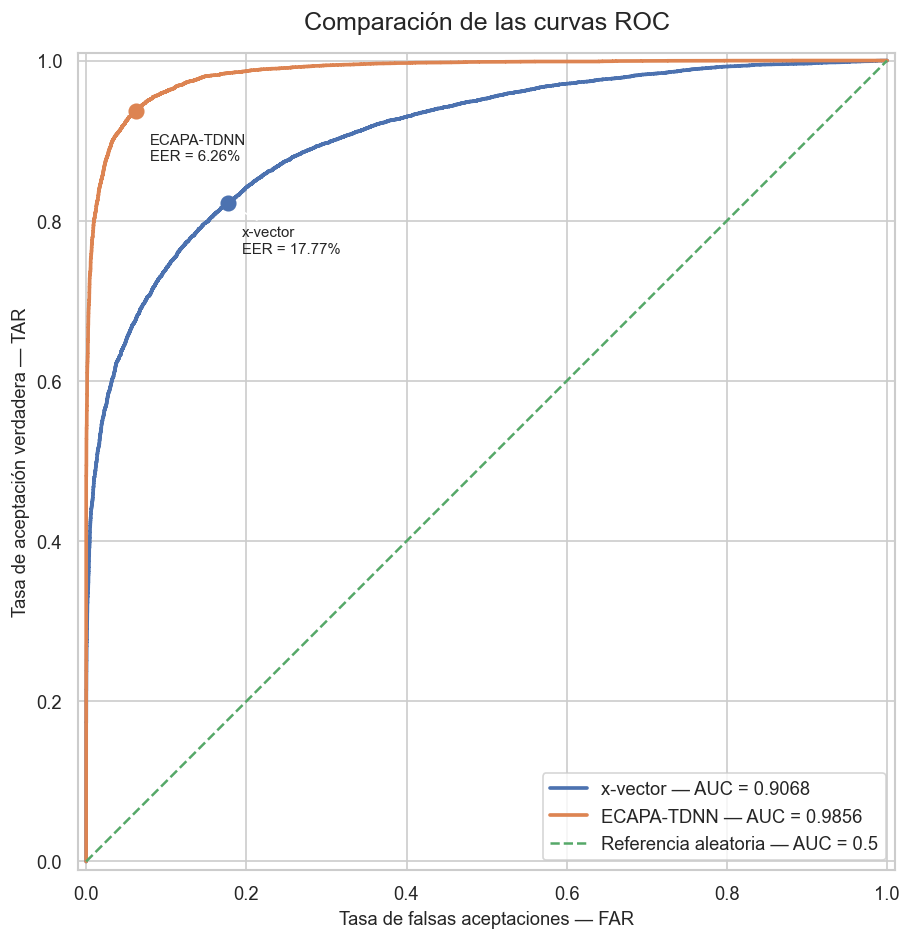

Curva ROC comparativa guardada correctamente en:
  - c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\evaluation\figures\roc_curve_comparison.png


In [44]:
# CURVA ROC COMPARATIVA

fig, ax = plt.subplots(figsize=(9, 8))


# ------------------------------------------------------------
# Curvas ROC de los modelos
# ------------------------------------------------------------

for model_name, model_results in roc_results.items():

    roc_table = model_results["table"]
    auc_value = model_results["auc"]

    # Cada punto representa el comportamiento del sistema
    # bajo un umbral de decisión diferente.
    ax.plot(
        roc_table["far_fpr"],
        roc_table["tar_tpr"],
        linewidth=2.2,
        label=f"{model_name} — AUC = {auc_value:.4f}"
    )


# ------------------------------------------------------------
# Línea de referencia
# ------------------------------------------------------------

# Esta diagonal representa un sistema sin capacidad de
# discriminación, equivalente aproximadamente a una decisión
# aleatoria.
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Referencia aleatoria — AUC = 0.5"
)


# ------------------------------------------------------------
# Puntos asociados con el EER
# ------------------------------------------------------------

for _, eer_row in eer_results.iterrows():

    model_name = eer_row["modelo"]

    # En el punto de EER:
    #
    #   FAR = EER
    #   FRR = EER
    #
    # Como TAR = 1 - FRR:
    #
    #   TAR = 1 - EER
    eer_value = eer_row["eer_interpolated"]

    eer_far = eer_value
    eer_tar = 1.0 - eer_value

    ax.scatter(
        eer_far,
        eer_tar,
        s=75,
        zorder=4
    )

    ax.annotate(
        f"{model_name}\nEER = {eer_value:.2%}",
        xy=(eer_far, eer_tar),
        xytext=(8, -30),
        textcoords="offset points",
        fontsize=9,
        arrowprops={
            "arrowstyle": "->",
            "linewidth": 1
        }
    )


# ------------------------------------------------------------
# Formato de la gráfica
# ------------------------------------------------------------

ax.set_title(
    "Comparación de las curvas ROC",
    fontsize=15,
    pad=14
)

ax.set_xlabel(
    "Tasa de falsas aceptaciones — FAR",
    fontsize=11
)

ax.set_ylabel(
    "Tasa de aceptación verdadera — TAR",
    fontsize=11
)

ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)

# Mantener la misma escala en ambos ejes evita deformar
# visualmente la curva.
ax.set_aspect(
    "equal",
    adjustable="box"
)

ax.legend(
    loc="lower right"
)

plt.tight_layout()


# ------------------------------------------------------------
# Guardado de la figura
# ------------------------------------------------------------

roc_comparison_path = (
    FIGURES_DIR / "roc_curve_comparison.png"
)

fig.savefig(
    roc_comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    "Curva ROC comparativa guardada correctamente en:\n"
    f"  - {roc_comparison_path}"
)


## 05. Curva DET

La curva ROC permite estudiar la relación entre la tasa de verdaderas aceptaciones y la tasa de falsas aceptaciones. Sin embargo, cuando las tasas de error son pequeñas, las diferencias entre sistemas pueden resultar difíciles de distinguir visualmente.

Para facilitar esta comparación se utiliza la **curva DET**.

DET significa:

$$
\textit{Detection Error Tradeoff}
$$

La curva DET representa directamente los dos tipos principales de error:

* **FAR:** tasa de falsas aceptaciones.
* **FRR:** tasa de falsos rechazos.

Por lo tanto, cada punto de la curva corresponde a un umbral de decisión y muestra el compromiso existente entre ambos errores.

---

## Ejes de la curva DET

El eje horizontal representa:

$$
\mathrm{FAR}
=

\frac{\text{impostores aceptados incorrectamente}}
{\text{total de trials impostores}}
$$

El eje vertical representa:

$$
\mathrm{FRR}
=

\frac{\text{genuinos rechazados incorrectamente}}
{\text{total de trials genuinos}}
$$

A diferencia de la curva ROC, donde se representa una tasa de acierto frente a una tasa de error, la curva DET muestra directamente:

$$
\mathrm{FRR}
\quad \text{frente a} \quad
\mathrm{FAR}
$$

---

## Interpretación general

Un sistema ideal tendría:

$$
\mathrm{FAR}=0
$$

y

$$
\mathrm{FRR}=0
$$

Por ello, en una curva DET el mejor desempeño se encuentra cerca de la esquina inferior izquierda.

En términos generales:

* Una curva más cercana al origen representa un mejor sistema.
* Para una misma FAR, es preferible el modelo con menor FRR.
* Para una misma FRR, es preferible el modelo con menor FAR.

La curva DET permite observar con claridad si un sistema domina a otro en una región específica de operación.

---

## Relación con el umbral

Cada punto de la curva DET corresponde a un umbral distinto.

### Umbral bajo

Cuando el umbral es muy bajo:

* Se aceptan muchos trials.
* FAR tiende a ser alta.
* FRR tiende a ser baja.

### Umbral alto

Cuando el umbral es muy alto:

* Se rechazan muchos trials.
* FAR tiende a ser baja.
* FRR tiende a ser alta.

Por esta razón, la curva muestra un intercambio entre ambos tipos de error.

---

## Escala probit

Aunque FAR y FRR son proporciones comprendidas entre 0 y 1, las curvas DET no suelen representarse con una escala lineal ordinaria.

En su lugar, se aplica la transformación inversa de la distribución normal estándar:

$$
x_{\mathrm{DET}}
=

\Phi^{-1}(\mathrm{FAR})
$$

$$
y_{\mathrm{DET}}
=

\Phi^{-1}(\mathrm{FRR})
$$

donde:

* $(\Phi)$ es la función de distribución acumulada de una normal estándar.
* $(\Phi^{-1})$ es su función inversa, también llamada función probit.

Esta transformación expande visualmente las regiones de tasas pequeñas y permite que diferencias cercanas a cero sean más fáciles de observar.

Las etiquetas de los ejes continuarán mostrándose como porcentajes para que la interpretación sea intuitiva.

---

## ¿Por qué no pueden utilizarse exactamente 0 y 1?

La transformación probit no está definida de manera finita en los extremos:

$$
\Phi^{-1}(0)=-\infty
$$

$$
\Phi^{-1}(1)=+\infty
$$

Por esta razón, antes de aplicar la transformación será necesario limitar las tasas a un pequeño intervalo interior:

$$
\varepsilon
\leq
p
\leq
1-\varepsilon
$$

donde $(\varepsilon)$ será un valor pequeño relacionado con la cantidad de trials disponibles.

Este ajuste únicamente permite representar los extremos en la gráfica; no modifica las métricas originales almacenadas.

---

## Relación con el EER

El punto de EER se encuentra sobre la línea donde:

$$
\mathrm{FAR}=\mathrm{FRR}
$$

En la curva DET, esta condición corresponde a la diagonal principal.

El punto donde la curva del sistema cruza o se aproxima a esa diagonal representa el Equal Error Rate.

En la gráfica se señalará el punto de EER de:

* x-vector.
* ECAPA-TDNN.

Esto permitirá visualizar simultáneamente:

* La tasa de error equivalente.
* El comportamiento de cada sistema alrededor de ese punto.
* Las diferencias entre modelos en otras regiones operativas.

---

## Diferencia entre ROC y DET

Ambas curvas se construyen a partir de los mismos scores y umbrales, pero enfatizan aspectos distintos.

### Curva ROC

Representa:

$$
\mathrm{TAR}
\quad \text{frente a} \quad
\mathrm{FAR}
$$

Es útil para analizar la capacidad general de discriminación y calcular el AUC.

### Curva DET

Representa:

$$
\mathrm{FRR}
\quad \text{frente a} \quad
\mathrm{FAR}
$$

Es especialmente útil para:

* Comparar directamente las tasas de error.
* Analizar regiones con errores pequeños.
* Identificar diferencias entre modelos cerca del punto de operación.
* Visualizar el compromiso entre seguridad y facilidad de uso.

---

## Limitaciones

La curva DET evalúa la discriminación del sistema, pero no analiza la calibración de los scores.

Además:

* No determina por sí sola cuál umbral debe utilizarse.
* No incorpora automáticamente costos diferentes para cada error.
* Su interpretación depende de la región operativa de interés.
* Los puntos extremos pueden ser inestables cuando existen pocos trials.

Por ello, la curva DET se interpretará conjuntamente con:

* EER.
* ROC-AUC.
* DCF y minDCF.
* $(C_{\mathrm{llr}})$.
* Diagramas de Tippett.

En la siguiente celda se calcularán los puntos de las curvas DET de ambos modelos y se aplicará la transformación probit necesaria para su representación.


In [47]:
# CÁLCULO Y REPRESENTACIÓN DE LAS CURVAS DET


# Las etiquetas reales son comunes para ambos modelos:
#
#   1 = comparación genuina
#   0 = comparación impostora
y_true = df_eval["label"].to_numpy(dtype=int)


def probability_to_probit(probabilities, epsilon):
    """
    Convierte probabilidades a escala probit.

    La transformación utilizada es:

        probit(p) = Phi^(-1)(p)

    donde Phi^(-1) es la función inversa de la distribución
    acumulada normal estándar.

    Los valores se limitan al intervalo:

        [epsilon, 1 - epsilon]

    para evitar resultados infinitos cuando p es igual a
    cero o uno.

    Parámetros
    ----------
    probabilities : array-like
        Tasas o probabilidades comprendidas entre 0 y 1.

    epsilon : float
        Valor mínimo permitido antes de aplicar la
        transformación probit.

    Retorna
    -------
    numpy.ndarray
        Probabilidades transformadas a escala probit.
    """

    probabilities = np.asarray(
        probabilities,
        dtype=float
    )

    clipped_probabilities = np.clip(
        probabilities,
        epsilon,
        1.0 - epsilon
    )

    return norm.ppf(clipped_probabilities)


# Este diccionario almacenará los datos DET de cada modelo.
det_results = {}


# ============================================================
# CÁLCULO DE LOS PUNTOS DET
# ============================================================

for model_name, score_column in model_score_columns.items():

    model_scores = df_eval[
        score_column
    ].to_numpy(dtype=float)

    # det_curve devuelve:
    #
    # fpr:
    #   tasa de falsos positivos, equivalente a FAR.
    #
    # fnr:
    #   tasa de falsos negativos, equivalente a FRR.
    #
    # thresholds:
    #   umbrales asociados con cada punto de la curva.
    far, frr, thresholds = det_curve(
        y_true=y_true,
        y_score=model_scores,
        pos_label=1
    )

    # Número de trials de cada clase.
    n_genuine = int((y_true == 1).sum())
    n_impostor = int((y_true == 0).sum())

    # Utilizamos la mitad de la menor tasa observable como
    # límite numérico para representar ceros y unos.
    #
    # Este ajuste se usa únicamente en la visualización probit.
    # Las tasas originales permanecen sin modificar.
    epsilon = 0.5 / min(
        n_genuine,
        n_impostor
    )

    # Aplicamos la transformación probit.
    far_probit = probability_to_probit(
        probabilities=far,
        epsilon=epsilon
    )

    frr_probit = probability_to_probit(
        probabilities=frr,
        epsilon=epsilon
    )

    # Construimos una tabla reutilizable.
    det_table = pd.DataFrame({
        "threshold": thresholds,
        "far": far,
        "frr": frr,
        "far_probit": far_probit,
        "frr_probit": frr_probit
    })

    det_results[model_name] = {
        "table": det_table,
        "epsilon": epsilon
    }

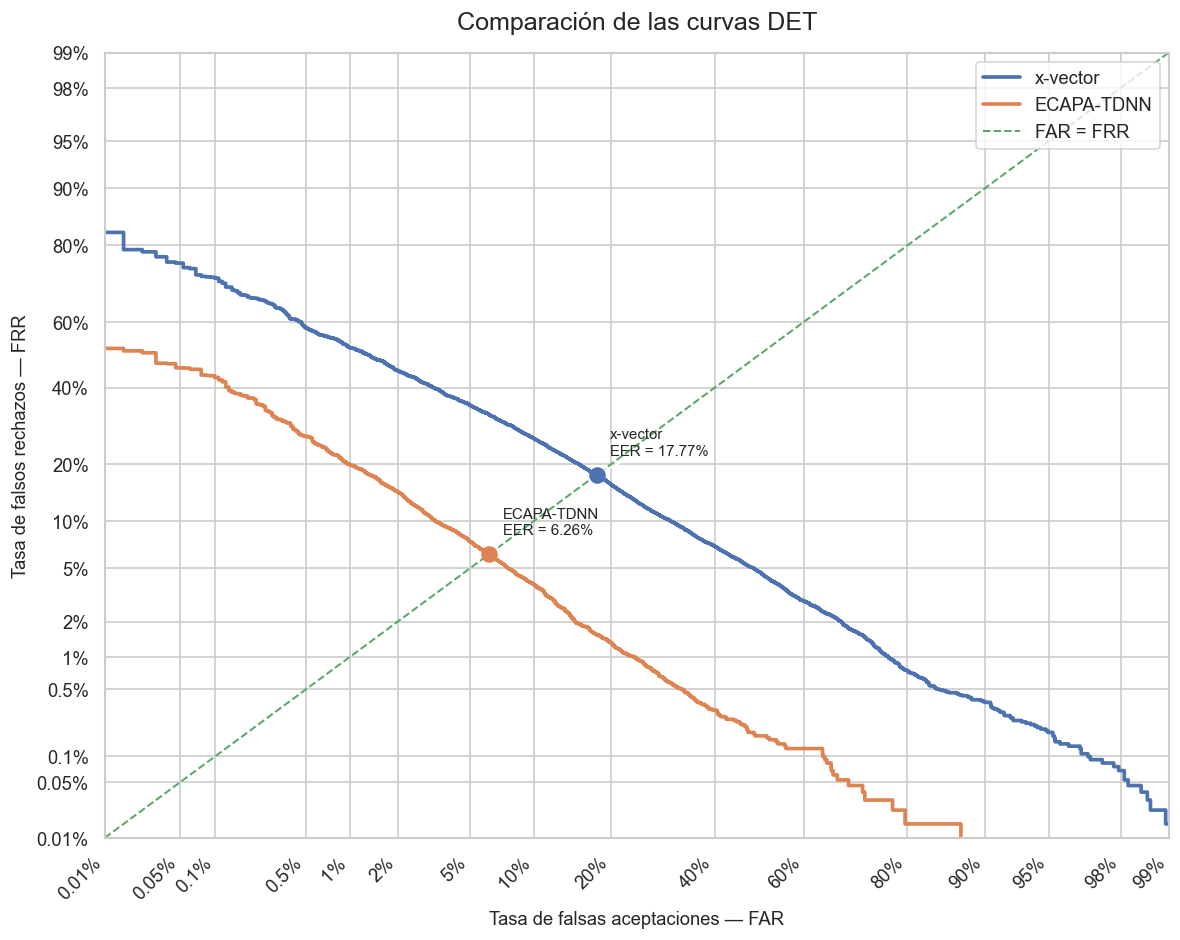

In [49]:
# ============================================================
# CREACIÓN DE LA CURVA DET COMPARATIVA
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))


for model_name, model_results in det_results.items():

    det_table = model_results["table"]

    ax.plot(
        det_table["far_probit"],
        det_table["frr_probit"],
        linewidth=2.2,
        label=model_name
    )


# ============================================================
# MARCACIÓN DE LOS PUNTOS DE EER
# ============================================================

for _, eer_row in eer_results.iterrows():

    model_name = eer_row["modelo"]
    eer_value = float(
        eer_row["eer_interpolated"]
    )

    # Utilizamos el epsilon específico del modelo.
    epsilon = det_results[
        model_name
    ]["epsilon"]

    eer_probit = probability_to_probit(
        probabilities=[eer_value],
        epsilon=epsilon
    )[0]

    # En el EER:
    #
    # FAR = FRR
    #
    # Por ello, el punto se encuentra sobre la diagonal.
    ax.scatter(
        eer_probit,
        eer_probit,
        s=80,
        zorder=4
    )

    ax.annotate(
        f"{model_name}\nEER = {eer_value:.2%}",
        xy=(eer_probit, eer_probit),
        xytext=(8, 12),
        textcoords="offset points",
        fontsize=9,
        arrowprops={
            "arrowstyle": "->",
            "linewidth": 1
        }
    )


# ============================================================
# DIAGONAL FAR = FRR
# ============================================================

# Tasas que utilizaremos como marcas de los ejes.
#
# Se incluyen más marcas en la región de errores pequeños
# porque esa es una de las principales ventajas de la DET.
det_tick_probabilities = np.array([
    0.0001,
    0.0005,
    0.001,
    0.005,
    0.01,
    0.02,
    0.05,
    0.10,
    0.20,
    0.40,
    0.60,
    0.80,
    0.90,
    0.95,
    0.98,
    0.99
])

det_tick_positions = norm.ppf(
    det_tick_probabilities
)

# Línea que representa FAR = FRR.
diagonal_min = det_tick_positions.min()
diagonal_max = det_tick_positions.max()

ax.plot(
    [diagonal_min, diagonal_max],
    [diagonal_min, diagonal_max],
    linestyle="--",
    linewidth=1.2,
    label="FAR = FRR"
)


# ============================================================
# FORMATO DE LOS EJES
# ============================================================

# Convertimos las probabilidades a etiquetas porcentuales
# comprensibles.
det_tick_labels = [
    f"{probability * 100:g}%"
    for probability in det_tick_probabilities
]

ax.set_xticks(det_tick_positions)
ax.set_xticklabels(
    det_tick_labels,
    rotation=45,
    ha="right"
)

ax.set_yticks(det_tick_positions)
ax.set_yticklabels(det_tick_labels)

ax.set_xlim(
    diagonal_min,
    diagonal_max
)

ax.set_ylim(
    diagonal_min,
    diagonal_max
)

ax.set_title(
    "Comparación de las curvas DET",
    fontsize=15,
    pad=14
)

ax.set_xlabel(
    "Tasa de falsas aceptaciones — FAR",
    fontsize=11
)

ax.set_ylabel(
    "Tasa de falsos rechazos — FRR",
    fontsize=11
)

ax.legend(
    loc="upper right"
)

plt.tight_layout()

In [51]:
# ============================================================
# GUARDADO DE LA FIGURA
# ============================================================

det_figure_path = (
    FIGURES_DIR / "det_curve_comparison.png"
)

fig.savefig(
    det_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

## 06. Función de costo de detección: DCF y minDCF

Las métricas analizadas hasta ahora tratan los errores de manera relativamente general.

Por ejemplo:

* El **EER** busca un punto donde FAR y FRR sean aproximadamente iguales.
* La **curva ROC** describe la relación entre TAR y FAR para todos los umbrales.
* La **curva DET** muestra directamente el compromiso entre FAR y FRR.

Sin embargo, en una aplicación real, una falsa aceptación y un falso rechazo no necesariamente tienen la misma importancia.

La **función de costo de detección**, conocida como DCF por *Detection Cost Function*, permite incorporar esta diferencia.

---

## Motivación

Considérese un sistema de acceso mediante voz.

Una **falsa aceptación** ocurre cuando un impostor es aceptado como si fuera el locutor legítimo. Este error puede representar:

* Acceso no autorizado.
* Exposición de información sensible.
* Suplantación de identidad.
* Pérdidas económicas o de seguridad.

Un **falso rechazo** ocurre cuando el sistema rechaza a un locutor legítimo. Este error puede causar:

* Incomodidad para el usuario.
* Repetición de la autenticación.
* Necesidad de utilizar otro mecanismo de acceso.
* Aumento en el tiempo de atención.

Aunque ambos resultados son indeseables, sus consecuencias pueden ser muy diferentes.

En una aplicación de alta seguridad, una falsa aceptación puede considerarse mucho más grave que un falso rechazo.

En una aplicación orientada a comodidad, podría asignarse mayor importancia a evitar rechazar usuarios legítimos.

---

## Definición de la función de costo

La función de costo de detección se define como:

$$
C_{\mathrm{det}}(t)
=

C_{\mathrm{miss}}
P_{\mathrm{tar}}
\mathrm{FRR}(t)
+
C_{\mathrm{fa}}
\left(1-P_{\mathrm{tar}}\right)
\mathrm{FAR}(t)
$$

donde:

* $(t)$ es el umbral de decisión.
* $(C_{\mathrm{miss}})$ es el costo asignado a un falso rechazo.
* $(C_{\mathrm{fa}})$ es el costo asignado a una falsa aceptación.
* $(P_{\mathrm{tar}})$ es la probabilidad previa de una comparación genuina.
* $(1-P_{\mathrm{tar}})$ es la probabilidad previa de una comparación impostora.
* $(\mathrm{FRR}(t))$ es la tasa de falsos rechazos en el umbral (t).
* $(\mathrm{FAR}(t))$ es la tasa de falsas aceptaciones en el umbral (t).

La DCF combina los dos tipos de error considerando:

1. La frecuencia esperada de cada clase.
2. La gravedad asignada a cada error.
3. El comportamiento del sistema en un umbral determinado.

---

## Probabilidad previa

La cantidad $(P_{\mathrm{tar}})$ representa la probabilidad de que una comparación sea genuina antes de observar el score.

No debe confundirse automáticamente con la proporción de genuinos presente en el conjunto de evaluación.

En este proyecto, el protocolo está balanceado:

$$
P(\text{genuino en el conjunto})=0.5
$$

Sin embargo, en una aplicación real las comparaciones genuinas podrían ser mucho más o mucho menos frecuentes.

Por ejemplo, si la mayoría de los intentos de acceso proviene de usuarios legítimos, podría utilizarse una probabilidad previa relativamente alta.

En cambio, una evaluación de seguridad podría considerar una probabilidad previa pequeña para la hipótesis genuina.

Por esta razón, los valores de $$(P_{\mathrm{tar}}), (C_{\mathrm{miss}}) y (C_{\mathrm{fa}})$$ deben declararse explícitamente.

---

## Interpretación de los términos

La primera parte de la DCF es:

$$
C_{\mathrm{miss}}
P_{\mathrm{tar}}
\mathrm{FRR}(t)
$$

Este término representa el costo esperado asociado con los falsos rechazos.

La segunda parte es:

$$
C_{\mathrm{fa}}
\left(1-P_{\mathrm{tar}}\right)
\mathrm{FAR}(t)
$$

Este término representa el costo esperado asociado con las falsas aceptaciones.

La suma de ambos constituye el costo total esperado para un determinado umbral.

---

## DCF normalizada

El valor directo de la DCF depende de los costos y de la probabilidad previa utilizados. Para facilitar la interpretación y comparación, suele emplearse una versión normalizada:

$$
C_{\mathrm{det}}^{\mathrm{norm}}(t)
=

\frac{
C_{\mathrm{det}}(t)
}{
\min
\left[
C_{\mathrm{miss}}P_{\mathrm{tar}},
;
C_{\mathrm{fa}}(1-P_{\mathrm{tar}})
\right]
}
$$

El denominador representa el costo del mejor sistema trivial.

Un sistema trivial no utiliza los scores. Simplemente decide siempre una misma clase:

* Aceptar todos los trials.
* Rechazar todos los trials.

La normalización permite comparar el sistema evaluado contra esa estrategia básica.

En términos generales:

* Un valor menor indica mejor rendimiento.
* Un valor cercano a (1) indica un desempeño similar al mejor sistema trivial.
* Un valor mayor que (1) indica que el umbral evaluado es peor que dicha referencia.

---

## Minimum Detection Cost Function

La DCF depende del umbral seleccionado.

Si se calcula el costo para todos los umbrales posibles, puede encontrarse el menor valor alcanzable:

$$
\mathrm{minDCF}
=

\min_t
C_{\mathrm{det}}^{\mathrm{norm}}(t)
$$

La minDCF responde a la pregunta:

> ¿Cuál es el menor costo que podría alcanzar este sistema si se seleccionara el mejor umbral posible para los costos y probabilidades definidos?

Para cada modelo se calcularán:

* DCF para todos los umbrales.
* DCF normalizada.
* minDCF.
* Umbral asociado con minDCF.
* FAR en el umbral de minDCF.
* FRR en el umbral de minDCF.

---

## minDCF y calibración

La minDCF se obtiene seleccionando el mejor umbral directamente sobre los scores evaluados.

Por esta razón, mide principalmente la capacidad del sistema para ordenar y separar trials genuinos e impostores bajo una condición de costos determinada.

No evalúa por completo si la escala numérica de los scores tiene una interpretación probabilística correcta.

La calibración será estudiada posteriormente mediante:

* Logaritmos de razones de verosimilitud.
* $(C_{\mathrm{llr}})$.
* $(C_{\mathrm{llr}}^{\min})$.
* Diagramas de Tippett.

---

## Configuraciones que se evaluarán

Se comenzará con una configuración de referencia:

$$
C_{\mathrm{miss}}=1
$$

$$
C_{\mathrm{fa}}=1
$$

$$
P_{\mathrm{tar}}=0.5
$$

Esta configuración asigna el mismo peso global a ambos tipos de error y es adecuada como punto inicial debido al balance del protocolo.

Después se analizarán escenarios adicionales en los que:

* Las falsas aceptaciones tengan mayor costo.
* Los falsos rechazos tengan mayor costo.
* La probabilidad previa de un trial genuino sea diferente.

Esto permitirá observar cómo cambia el umbral recomendado según el contexto operativo.

En la siguiente celda se implementará una función general para calcular DCF, DCF normalizada y minDCF.


In [52]:
# CÁLCULO DE DCF, DCF NORMALIZADA Y minDCF

def calculate_detection_cost(
    threshold_table,
    c_miss=1.0,
    c_fa=1.0,
    p_target=0.5
):
    """
    Calcula la función de costo de detección para todos los
    umbrales disponibles y localiza la minDCF.

    La función de costo utilizada es:

        DCF(t) =
            C_miss * P_target * FRR(t)
            +
            C_fa * (1 - P_target) * FAR(t)

    La versión normalizada es:

        DCF_norm(t) =
            DCF(t)
            /
            min(
                C_miss * P_target,
                C_fa * (1 - P_target)
            )

    Parámetros
    ----------
    threshold_table : pandas.DataFrame
        Tabla con las métricas calculadas para distintos
        umbrales. Debe contener al menos:

        - threshold
        - far
        - frr
        - tar
        - tnr
        - false_acceptances
        - false_rejections

    c_miss : float, default=1.0
        Costo asignado a un falso rechazo.

    c_fa : float, default=1.0
        Costo asignado a una falsa aceptación.

    p_target : float, default=0.5
        Probabilidad previa de una comparación genuina.

    Retorna
    -------
    dcf_table : pandas.DataFrame
        Tabla original ampliada con:

        - dcf
        - dcf_normalized

    summary : dict
        Resumen del punto donde se alcanza la minDCF.
    """

    # --------------------------------------------------------
    # Validación de columnas
    # --------------------------------------------------------

    required_columns = [
        "threshold",
        "far",
        "frr",
        "tar",
        "tnr",
        "false_acceptances",
        "false_rejections"
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in threshold_table.columns
    ]

    if missing_columns:
        raise ValueError(
            "La tabla de umbrales no contiene todas las "
            f"columnas requeridas: {missing_columns}"
        )


    # --------------------------------------------------------
    # Validación de parámetros
    # --------------------------------------------------------

    if c_miss <= 0:
        raise ValueError(
            "c_miss debe ser estrictamente positivo."
        )

    if c_fa <= 0:
        raise ValueError(
            "c_fa debe ser estrictamente positivo."
        )

    if not 0 < p_target < 1:
        raise ValueError(
            "p_target debe encontrarse estrictamente "
            "entre 0 y 1."
        )


    # --------------------------------------------------------
    # Copia de trabajo
    # --------------------------------------------------------

    # Se crea una copia para evitar modificar la tabla original
    # almacenada en threshold_metrics.
    dcf_table = (
        threshold_table
        .copy()
        .sort_values("threshold")
        .reset_index(drop=True)
    )


    # --------------------------------------------------------
    # Cálculo de los componentes del costo
    # --------------------------------------------------------

    # Costo esperado producido por los falsos rechazos.
    dcf_table["cost_miss_component"] = (
        c_miss
        * p_target
        * dcf_table["frr"]
    )

    # Costo esperado producido por las falsas aceptaciones.
    dcf_table["cost_fa_component"] = (
        c_fa
        * (1.0 - p_target)
        * dcf_table["far"]
    )

    # Costo total de detección para cada umbral.
    dcf_table["dcf"] = (
        dcf_table["cost_miss_component"]
        + dcf_table["cost_fa_component"]
    )


    # --------------------------------------------------------
    # Normalización
    # --------------------------------------------------------

    # Costo de rechazar siempre todos los trials:
    #
    # FRR = 1 y FAR = 0
    cost_always_reject = (
        c_miss * p_target
    )

    # Costo de aceptar siempre todos los trials:
    #
    # FRR = 0 y FAR = 1
    cost_always_accept = (
        c_fa * (1.0 - p_target)
    )

    # El mejor de los dos sistemas triviales constituye
    # la referencia utilizada para normalizar.
    normalization_constant = min(
        cost_always_reject,
        cost_always_accept
    )

    dcf_table["dcf_normalized"] = (
        dcf_table["dcf"]
        / normalization_constant
    )


    # --------------------------------------------------------
    # Localización de la minDCF
    # --------------------------------------------------------

    min_position = (
        dcf_table["dcf_normalized"]
        .to_numpy()
        .argmin()
    )

    min_row = dcf_table.iloc[min_position]

    summary = {
        "c_miss": float(c_miss),
        "c_fa": float(c_fa),
        "p_target": float(p_target),
        "normalization_constant": float(
            normalization_constant
        ),
        "min_dcf": float(
            min_row["dcf"]
        ),
        "min_dcf_normalized": float(
            min_row["dcf_normalized"]
        ),
        "threshold_min_dcf": float(
            min_row["threshold"]
        ),
        "far_at_min_dcf": float(
            min_row["far"]
        ),
        "frr_at_min_dcf": float(
            min_row["frr"]
        ),
        "tar_at_min_dcf": float(
            min_row["tar"]
        ),
        "tnr_at_min_dcf": float(
            min_row["tnr"]
        ),
        "false_acceptances_at_min_dcf": int(
            min_row["false_acceptances"]
        ),
        "false_rejections_at_min_dcf": int(
            min_row["false_rejections"]
        )
    }

    return dcf_table, summary

In [53]:
# CONFIGURACIÓN DE REFERENCIA
REFERENCE_C_MISS = 1.0
REFERENCE_C_FA = 1.0
REFERENCE_P_TARGET = 0.5



# CÁLCULO PARA AMBOS MODELOS
dcf_results = {}
dcf_summary_rows = []

for model_name, threshold_table in threshold_metrics.items():

    model_dcf_table, model_dcf_summary = (
        calculate_detection_cost(
            threshold_table=threshold_table,
            c_miss=REFERENCE_C_MISS,
            c_fa=REFERENCE_C_FA,
            p_target=REFERENCE_P_TARGET
        )
    )

    # Guardamos la curva completa de costos.
    dcf_results[model_name] = {
        "table": model_dcf_table,
        "summary": model_dcf_summary
    }

    # Añadimos el nombre del modelo al resumen.
    model_dcf_summary["modelo"] = model_name

    dcf_summary_rows.append(
        model_dcf_summary
    )


# Construimos una tabla comparativa.
dcf_summary = pd.DataFrame(
    dcf_summary_rows
)

# Reordenamos las columnas.
dcf_summary = dcf_summary[
    [
        "modelo",
        "c_miss",
        "c_fa",
        "p_target",
        "normalization_constant",
        "min_dcf",
        "min_dcf_normalized",
        "threshold_min_dcf",
        "far_at_min_dcf",
        "frr_at_min_dcf",
        "tar_at_min_dcf",
        "tnr_at_min_dcf",
        "false_acceptances_at_min_dcf",
        "false_rejections_at_min_dcf"
    ]
]

In [55]:
# PRESENTACIÓN DE RESULTADOS

print("\n" + "=" * 85)
print("RESULTADOS DE minDCF — CONFIGURACIÓN DE REFERENCIA")
print("=" * 85)

print(
    f"\nC_miss = {REFERENCE_C_MISS}\n"
    f"C_fa = {REFERENCE_C_FA}\n"
    f"P_target = {REFERENCE_P_TARGET}\n"
)

display(
    dcf_summary.style.format({
        "c_miss": "{:.2f}",
        "c_fa": "{:.2f}",
        "p_target": "{:.4f}",
        "normalization_constant": "{:.6f}",
        "min_dcf": "{:.6f}",
        "min_dcf_normalized": "{:.6f}",
        "threshold_min_dcf": "{:.6f}",
        "far_at_min_dcf": "{:.4%}",
        "frr_at_min_dcf": "{:.4%}",
        "tar_at_min_dcf": "{:.4%}",
        "tnr_at_min_dcf": "{:.4%}",
        "false_acceptances_at_min_dcf": "{:,.0f}",
        "false_rejections_at_min_dcf": "{:,.0f}"
    })
)




RESULTADOS DE minDCF — CONFIGURACIÓN DE REFERENCIA

C_miss = 1.0
C_fa = 1.0
P_target = 0.5



,modelo,c_miss,c_fa,p_target,normalization_constant,min_dcf,min_dcf_normalized,threshold_min_dcf,far_at_min_dcf,frr_at_min_dcf,tar_at_min_dcf,tnr_at_min_dcf,false_acceptances_at_min_dcf,false_rejections_at_min_dcf
0,x-vector,1.00,1.00,0.5000,0.500000,0.175351,0.350703,0.927620,14.7133%,20.3570%,79.6430%,85.2867%,"1,937","2,680"
1,ECAPA-TDNN,1.00,1.00,0.5000,0.500000,0.061831,0.123661,0.367062,5.6134%,6.7528%,93.2472%,94.3866%,739,889


In [56]:
# ANÁLISIS DE SENSIBILIDAD DE minDCF

# Cada escenario representa una posible condición operativa.
#
# IMPORTANTE:
# Estos valores no constituyen estándares universales.
# Se utilizan para ilustrar cómo la elección de costos y
# probabilidades previas modifica el umbral recomendado.
dcf_scenarios = [
    {
        "escenario": "Balanceado",
        "descripcion": (
            "Falsas aceptaciones y falsos rechazos tienen "
            "la misma importancia."
        ),
        "c_miss": 1.0,
        "c_fa": 1.0,
        "p_target": 0.50
    },
    {
        "escenario": "Mayor costo de falsa aceptación",
        "descripcion": (
            "Se penaliza con mayor intensidad aceptar "
            "incorrectamente a un impostor."
        ),
        "c_miss": 1.0,
        "c_fa": 10.0,
        "p_target": 0.50
    },
    {
        "escenario": "Mayor costo de falso rechazo",
        "descripcion": (
            "Se penaliza con mayor intensidad rechazar "
            "incorrectamente a un locutor genuino."
        ),
        "c_miss": 10.0,
        "c_fa": 1.0,
        "p_target": 0.50
    },
    {
        "escenario": "Baja probabilidad de genuino",
        "descripcion": (
            "Se supone que las comparaciones genuinas son "
            "poco frecuentes."
        ),
        "c_miss": 1.0,
        "c_fa": 1.0,
        "p_target": 0.01
    },
    {
        "escenario": "Alta probabilidad de genuino",
        "descripcion": (
            "Se supone que la mayoría de las comparaciones "
            "corresponde a locutores genuinos."
        ),
        "c_miss": 1.0,
        "c_fa": 1.0,
        "p_target": 0.99
    }
]


# Este diccionario conservará las curvas completas de DCF
# para cada combinación de modelo y escenario.
dcf_sensitivity_results = {}

# Esta lista almacenará los resultados resumidos.
dcf_sensitivity_rows = []



# CÁLCULO PARA CADA MODELO Y ESCENARIO

for scenario in dcf_scenarios:

    scenario_name = scenario["escenario"]

    for model_name, threshold_table in threshold_metrics.items():

        # Calculamos la DCF completa y localizamos la minDCF.
        scenario_dcf_table, scenario_summary = (
            calculate_detection_cost(
                threshold_table=threshold_table,
                c_miss=scenario["c_miss"],
                c_fa=scenario["c_fa"],
                p_target=scenario["p_target"]
            )
        )

        # Clave única para almacenar los resultados.
        result_key = (
            scenario_name,
            model_name
        )

        dcf_sensitivity_results[result_key] = {
            "table": scenario_dcf_table,
            "summary": scenario_summary
        }

        # Agregamos información descriptiva al resumen.
        dcf_sensitivity_rows.append({
            "escenario": scenario_name,
            "descripcion": scenario["descripcion"],
            "modelo": model_name,
            "c_miss": scenario["c_miss"],
            "c_fa": scenario["c_fa"],
            "p_target": scenario["p_target"],
            "min_dcf": scenario_summary["min_dcf"],
            "min_dcf_normalized": (
                scenario_summary["min_dcf_normalized"]
            ),
            "threshold_min_dcf": (
                scenario_summary["threshold_min_dcf"]
            ),
            "far_at_min_dcf": (
                scenario_summary["far_at_min_dcf"]
            ),
            "frr_at_min_dcf": (
                scenario_summary["frr_at_min_dcf"]
            ),
            "tar_at_min_dcf": (
                scenario_summary["tar_at_min_dcf"]
            ),
            "tnr_at_min_dcf": (
                scenario_summary["tnr_at_min_dcf"]
            ),
            "false_acceptances_at_min_dcf": (
                scenario_summary[
                    "false_acceptances_at_min_dcf"
                ]
            ),
            "false_rejections_at_min_dcf": (
                scenario_summary[
                    "false_rejections_at_min_dcf"
                ]
            )
        })


# Convertimos los resultados en una tabla.
dcf_sensitivity_summary = pd.DataFrame(
    dcf_sensitivity_rows
)

# Ordenamos los escenarios según el orden en que fueron definidos.
scenario_order = [
    scenario["escenario"]
    for scenario in dcf_scenarios
]

dcf_sensitivity_summary["escenario"] = pd.Categorical(
    dcf_sensitivity_summary["escenario"],
    categories=scenario_order,
    ordered=True
)

dcf_sensitivity_summary = (
    dcf_sensitivity_summary
    .sort_values(
        ["escenario", "modelo"]
    )
    .reset_index(drop=True)
)

In [57]:
# PRESENTACIÓN DE RESULTADOS

print("\n" + "=" * 95)
print("ANÁLISIS DE SENSIBILIDAD DE minDCF")
print("=" * 95)

display(
    dcf_sensitivity_summary[
        [
            "escenario",
            "modelo",
            "c_miss",
            "c_fa",
            "p_target",
            "min_dcf_normalized",
            "threshold_min_dcf",
            "far_at_min_dcf",
            "frr_at_min_dcf",
            "false_acceptances_at_min_dcf",
            "false_rejections_at_min_dcf"
        ]
    ].style.format({
        "c_miss": "{:.2f}",
        "c_fa": "{:.2f}",
        "p_target": "{:.4f}",
        "min_dcf_normalized": "{:.6f}",
        "threshold_min_dcf": "{:.6f}",
        "far_at_min_dcf": "{:.4%}",
        "frr_at_min_dcf": "{:.4%}",
        "false_acceptances_at_min_dcf": "{:,.0f}",
        "false_rejections_at_min_dcf": "{:,.0f}"
    })
)


ANÁLISIS DE SENSIBILIDAD DE minDCF


,escenario,modelo,c_miss,c_fa,p_target,min_dcf_normalized,threshold_min_dcf,far_at_min_dcf,frr_at_min_dcf,false_acceptances_at_min_dcf,false_rejections_at_min_dcf
0,Balanceado,ECAPA-TDNN,1.00,1.00,0.5000,0.123661,0.367062,5.6134%,6.7528%,739,889
1,Balanceado,x-vector,1.00,1.00,0.5000,0.350703,0.927620,14.7133%,20.3570%,"1,937","2,680"
2,Mayor costo de falsa aceptación,ECAPA-TDNN,1.00,10.00,0.5000,0.295936,0.459824,0.9419%,20.1747%,124,"2,656"
3,Mayor costo de falsa aceptación,x-vector,1.00,10.00,0.5000,0.621041,0.950663,0.9799%,52.3054%,129,"6,886"
4,Mayor costo de falso rechazo,ECAPA-TDNN,10.00,1.00,0.5000,0.327687,0.271518,20.7672%,1.2002%,"2,734",158
5,Mayor costo de falso rechazo,x-vector,10.00,1.00,0.5000,0.865856,0.882019,75.8754%,1.0710%,"9,989",141
6,Baja probabilidad de genuino,ECAPA-TDNN,1.00,1.00,0.0100,0.504064,0.571409,0.0304%,47.3984%,4,"6,240"
7,Baja probabilidad de genuino,x-vector,1.00,1.00,0.0100,0.798177,0.962713,0.0684%,73.0498%,9,"9,617"
8,Alta probabilidad de genuino,ECAPA-TDNN,1.00,1.00,0.9900,0.655222,0.180993,47.4744%,0.1823%,"6,250",24
9,Alta probabilidad de genuino,x-vector,1.00,1.00,0.9900,1.000000,0.686189,100.0000%,0.0000%,"13,165",0


## 07. Calibración de los scores

Hasta este punto, la evaluación se ha concentrado principalmente en la capacidad de los sistemas para separar comparaciones genuinas e impostoras.

Las métricas calculadas, como:

* EER.
* ROC-AUC.
* Curvas DET.
* DCF.
* minDCF.

permiten analizar si los trials genuinos tienden a recibir scores mayores que los trials impostores.

Esta propiedad se denomina **discriminación**.

Sin embargo, una buena separación entre clases no garantiza que el valor numérico del score tenga una interpretación probabilística o forense adecuada.

Para estudiar la calidad de la evidencia producida por los sistemas es necesario introducir el concepto de **calibración**.

---

## ¿Qué significa calibrar un sistema?

Calibrar consiste en transformar los scores originales a una escala con una interpretación estadística definida.

En este proyecto, los modelos producen scores de similitud coseno:

$$
s \in [-1,1]
$$

Un valor alto indica que los embeddings son similares, mientras que un valor bajo indica menor similitud.

No obstante, un score de similitud coseno:

* No es una probabilidad.
* No representa directamente la probabilidad de que las voces pertenezcan al mismo locutor.
* No es una razón de verosimilitud.
* No puede interpretarse por sí mismo como fuerza de evidencia.
* No tiene necesariamente la misma interpretación entre x-vector y ECAPA-TDNN.

Por ejemplo, no es válido afirmar que:

$$
s=0.90
$$

significa que existe un (90%) de probabilidad de que las grabaciones pertenezcan al mismo locutor.

Tampoco es correcto afirmar que un score de (0.90) representa la misma evidencia en ambos modelos.

La calibración busca transformar los scores a una escala en la que la magnitud de los valores pueda interpretarse de manera coherente.

---

## Hipótesis consideradas

En el contexto de comparación de locutores se plantean dos hipótesis:

$$
H_p:
\text{las grabaciones pertenecen al mismo locutor}
$$

$$
H_d:
\text{las grabaciones pertenecen a locutores diferentes}
$$

La razón de verosimilitud se define como:

$$
\mathrm{LR}
=

\frac{
p(E\mid H_p)
}{
p(E\mid H_d)
}
$$

donde $(E)$ representa la evidencia observada, en este caso la información contenida en la comparación de las voces.

La razón de verosimilitud compara qué tan probable es observar la evidencia bajo cada una de las dos hipótesis.

---

## Interpretación de la razón de verosimilitud

### Cuando $(\mathrm{LR}>1)$

La evidencia es más probable bajo la hipótesis de mismo locutor:

$$
p(E\mid H_p)

>

p(E\mid H_d)
$$

Por lo tanto, la evidencia favorece $(H_p)$.

### Cuando $(\mathrm{LR}<1)$

La evidencia es más probable bajo la hipótesis de locutores diferentes:

$$
p(E\mid H_p)
<
p(E\mid H_d)
$$

Por lo tanto, la evidencia favorece $(H_d)$.

### Cuando $(\mathrm{LR}=1)$

La evidencia es igualmente probable bajo ambas hipótesis:

$$
p(E\mid H_p)
=

p(E\mid H_d)
$$

En este caso, la evidencia no favorece a ninguna de las dos hipótesis.

---

## Logaritmo de la razón de verosimilitud

En lugar de trabajar directamente con la razón de verosimilitud, es frecuente utilizar su logaritmo:

$$
\mathrm{LLR}
=

\log
\left(
\mathrm{LR}
\right)
$$

En este proyecto utilizaremos el logaritmo natural:

$$
\mathrm{LLR}
=

\ln
\left(
\mathrm{LR}
\right)
$$

Esta transformación presenta varias ventajas:

* Convierte productos de razones de verosimilitud en sumas.
* Facilita el manejo de valores extremadamente grandes o pequeños.
* Produce una escala simétrica alrededor de cero.
* Simplifica la interpretación de la dirección de la evidencia.

---

## Interpretación del LLR

### Cuando $(\mathrm{LLR}>0)$

Se cumple que:

$$
\mathrm{LR}>1
$$

Por lo tanto, la evidencia favorece la hipótesis de mismo locutor.

### Cuando $(\mathrm{LLR}<0)$

Se cumple que:

$$
\mathrm{LR}<1
$$

Por lo tanto, la evidencia favorece la hipótesis de locutores diferentes.

### Cuando $(\mathrm{LLR}=0)$

Se cumple que:

$$
\mathrm{LR}=1
$$

La evidencia es neutral y no favorece ninguna hipótesis.

La relación inversa es:

$$
\mathrm{LR}
=

e^{\mathrm{LLR}}
$$


---

## Calibración mediante regresión logística

Para transformar los scores coseno en LLR se utilizará un modelo de regresión logística.

La transformación tendrá la forma:

$$
\mathrm{LLR}(s)
=

a+bs
$$

donde:

* $(s)$ es el score de similitud coseno.
* $(a)$ es el intercepto del calibrador.
* $(b)$ es el coeficiente asociado con el score.
* $(\mathrm{LLR}(s))$ es el logaritmo de la razón de verosimilitud estimado.

El coeficiente $(b)$ controla la escala de los scores.

El intercepto $(a)$ desplaza la transformación para establecer el punto donde la evidencia es neutral:

$$
\mathrm{LLR}(s)=0
$$

La regresión logística aprende estos parámetros utilizando ejemplos genuinos e impostores conocidos.

---

## Relación entre regresión logística y LLR

La regresión logística modela los logaritmos de las probabilidades posteriores:

$$
\log
\left(
\frac{
P(H_p\mid s)
}{
P(H_d\mid s)
}
\right)
=

a+bs
$$

Sin embargo, las probabilidades posteriores incluyen las probabilidades previas de ambas hipótesis.

Mediante el teorema de Bayes:

$$
\log
\left(
\frac{
P(H_p\mid s)
}{
P(H_d\mid s)
}
\right)
=

\mathrm{LLR}(s)
+
\log
\left(
\frac{
P(H_p)
}{
P(H_d)
}
\right)
$$

Por esta razón, para obtener LLR es necesario controlar la proporción o los pesos utilizados durante el ajuste.

En esta evaluación se utilizará una calibración con **prior efectivo balanceado**:

$$
P(H_p)=P(H_d)=0.5
$$

En este caso:

$$
\log
\left(
\frac{P(H_p)}{P(H_d)}
\right)
=

 \log(1)

=0
$$

y la salida lineal de la regresión logística puede interpretarse directamente como una estimación del LLR.

Esta decisión no significa que las hipótesis tengan necesariamente la misma probabilidad en una aplicación real. Se utiliza para obtener una transformación de los scores independiente de un escenario operativo particular.

---

## Calibración y discriminación son propiedades distintas

Un sistema puede presentar buena discriminación, pero mala calibración.

Por ejemplo, puede ordenar correctamente los scores:

$$
s_{\mathrm{genuino}}

>

s_{\mathrm{impostor}}
$$

pero producir valores excesivamente concentrados o exagerados.

También puede ocurrir que dos sistemas tengan EER similares, pero uno genere LLR más coherentes que el otro.

La discriminación depende principalmente del orden de los scores.

La calibración depende de:

* La dirección de la evidencia.
* La escala de los valores.
* La magnitud asignada a comparaciones fáciles y difíciles.
* La correspondencia entre los scores y las razones de verosimilitud.

Una transformación lineal creciente puede cambiar la calibración sin alterar el orden de los scores y, por lo tanto, sin modificar métricas como ROC-AUC o EER.

---

## Riesgo de evaluar la calibración sobre los mismos datos

Si el calibrador se ajusta y se evalúa utilizando exactamente los mismos trials, puede adaptarse demasiado a las observaciones disponibles.

Esto produciría una estimación excesivamente optimista de su desempeño.

El problema sería similar a entrenar un modelo y evaluar su capacidad predictiva usando los mismos datos de entrenamiento.

Para reducir este sesgo se utilizará calibración fuera de muestra mediante validación cruzada.

---

## Validación cruzada agrupada

Los trials no son completamente independientes.

Un mismo locutor puede aparecer en múltiples comparaciones genuinas e impostoras. Si los trials del mismo locutor se distribuyeran aleatoriamente entre entrenamiento y evaluación, el calibrador podría aprovechar información indirecta compartida entre ambas particiones.

Para reducir esta dependencia se utilizará una validación cruzada agrupada.

La variable principal de agrupación será:

$$
\text{enrollment speaker id}
$$

Esta variable representa la identidad reclamada o el locutor asociado con el audio de inscripción.

La regla será:

> Todos los trials asociados con un mismo locutor de enrollment deben permanecer dentro de la misma partición.

De esta manera, un locutor utilizado para ajustar el calibrador en una iteración no aparecerá como locutor de enrollment en la partición evaluada en esa misma iteración.

---

## LLR fuera de muestra

El procedimiento general será:

1. Dividir los locutores de enrollment en varios grupos.

2. Utilizar algunos grupos para ajustar el calibrador.

3. Aplicar el calibrador al grupo que quedó fuera.

4. Repetir el proceso hasta que todos los trials hayan sido evaluados una vez.

5. Reunir las predicciones de todas las particiones.

El resultado será un LLR fuera de muestra para cada trial.

Estos valores se utilizarán posteriormente para:

* Calcular $(C_{\mathrm{llr}})$.
* Construir diagramas de Tippett.
* Analizar evidencia en dirección incorrecta.
* Comparar la calibración de x-vector y ECAPA-TDNN.

---

## Calibradores independientes por modelo

x-vector y ECAPA-TDNN producen distribuciones de scores diferentes.

Por esta razón, se ajustará un calibrador independiente para cada sistema:

$$
\mathrm{LLR}_{\mathrm{xvector}}(s)
=

a_{\mathrm{xvector}}
+
b_{\mathrm{xvector}}s
$$

$$
\mathrm{LLR}_{\mathrm{ECAPA}}(s)
=

a_{\mathrm{ECAPA}}
+
b_{\mathrm{ECAPA}}s
$$

No se utilizarán los mismos parámetros para ambos modelos.

---

## Precaución interpretativa

La calibración permite transformar los scores en estimaciones de razones de verosimilitud dentro del protocolo experimental utilizado.

Sin embargo, la calidad de esta transformación depende de que los datos de calibración sean representativos de las condiciones donde se aplicará el sistema.

Los LLR obtenidos no deben generalizarse automáticamente a:

* Otros corpus.
* Otros idiomas.
* Otros canales de grabación.
* Condiciones acústicas diferentes.
* Micrófonos distintos.
* Poblaciones de locutores diferentes.
* Protocolos impostores distintos.

Por ello, en este proyecto los resultados se interpretarán como una evaluación experimental sobre CIEMPIESS y bajo el protocolo construido.

En la siguiente celda se verificará que la variable de agrupación sea adecuada y se prepararán las particiones de validación cruzada para la calibración.


In [58]:
# PREPARACIÓN DE LA VALIDACIÓN CRUZADA AGRUPADA

# Número de particiones de validación cruzada.
#
# Con 87 locutores de enrollment, cinco particiones permiten
# conservar una cantidad razonable de locutores tanto para
# ajustar como para evaluar el calibrador en cada iteración.
N_CALIBRATION_FOLDS = 5

# Variable utilizada para agrupar los trials.
#
# Todos los trials asociados con un mismo locutor de enrollment
# permanecerán dentro de una única partición de evaluación.
CALIBRATION_GROUP_COLUMN = "enrollment_speaker_id"


# ============================================================
# PREPARACIÓN DE ETIQUETAS Y GRUPOS
# ============================================================

calibration_labels = (
    df_eval["label"]
    .to_numpy(dtype=int)
)

calibration_groups = (
    df_eval[CALIBRATION_GROUP_COLUMN]
    .astype(str)
    .to_numpy()
)

n_calibration_trials = len(df_eval)
n_calibration_groups = pd.Series(
    calibration_groups
).nunique()


print("=" * 80)
print("PREPARACIÓN DE LA VALIDACIÓN CRUZADA PARA CALIBRACIÓN")
print("=" * 80)

print(f"\nNúmero total de trials: {n_calibration_trials:,}")
print(
    "Número de locutores de enrollment utilizados como grupos: "
    f"{n_calibration_groups:,}"
)
print(f"Número de particiones: {N_CALIBRATION_FOLDS}")


# El número de grupos debe ser al menos igual al número
# de particiones solicitado.
if n_calibration_groups < N_CALIBRATION_FOLDS:
    raise ValueError(
        "El número de locutores disponibles es menor que "
        "el número de particiones solicitado."
    )


# ============================================================
# CREACIÓN DEL OBJETO GroupKFold
# ============================================================

# GroupKFold garantiza que un grupo completo aparezca:
#
# - En entrenamiento, o
# - En evaluación,
#
# pero nunca simultáneamente en ambos subconjuntos dentro
# de una misma iteración.
group_kfold = GroupKFold(
    n_splits=N_CALIBRATION_FOLDS
)


# ============================================================
# GENERACIÓN DE LAS PARTICIONES
# ============================================================

# El contenido de X no se utiliza todavía para ajustar el
# calibrador. Se proporciona únicamente porque split() requiere
# una matriz de entrada con el mismo número de observaciones.
dummy_features = np.zeros(
    shape=(n_calibration_trials, 1),
    dtype=float
)

# Esta lista almacenará los pares de índices:
#
#   (índices de entrenamiento, índices de evaluación)
calibration_splits = list(
    group_kfold.split(
        X=dummy_features,
        y=calibration_labels,
        groups=calibration_groups
    )
)

# Vector donde se registrará la partición asignada a cada trial.
#
# Inicialmente todos los registros reciben -1, indicando que
# todavía no han sido asignados a una partición de evaluación.
calibration_fold_id = np.full(
    shape=n_calibration_trials,
    fill_value=-1,
    dtype=int
)

# Resumen de cada partición.
fold_summary_rows = []


# ============================================================
# VALIDACIÓN DE CADA PARTICIÓN
# ============================================================

for fold_number, (train_indices, test_indices) in enumerate(
    calibration_splits,
    start=1
):

    # Registramos la partición en la que cada trial será
    # evaluado fuera de muestra.
    calibration_fold_id[test_indices] = fold_number

    # Locutores presentes en cada subconjunto.
    train_groups = set(
        calibration_groups[train_indices]
    )

    test_groups = set(
        calibration_groups[test_indices]
    )

    # --------------------------------------------------------
    # Comprobación de fuga entre grupos
    # --------------------------------------------------------

    overlapping_groups = (
        train_groups.intersection(test_groups)
    )

    if overlapping_groups:
        raise RuntimeError(
            f"La partición {fold_number} contiene locutores "
            "de enrollment tanto en entrenamiento como en "
            "evaluación."
        )

    # --------------------------------------------------------
    # Etiquetas de entrenamiento y evaluación
    # --------------------------------------------------------

    y_train = calibration_labels[train_indices]
    y_test = calibration_labels[test_indices]

    train_genuine = int((y_train == 1).sum())
    train_impostor = int((y_train == 0).sum())

    test_genuine = int((y_test == 1).sum())
    test_impostor = int((y_test == 0).sum())

    # La regresión logística necesita observar las dos clases
    # durante el ajuste.
    if train_genuine == 0 or train_impostor == 0:
        raise RuntimeError(
            f"La partición {fold_number} no contiene ambas "
            "clases en el conjunto de entrenamiento."
        )

    # También necesitamos ambas clases en evaluación para poder
    # estudiar posteriormente el desempeño del calibrador.
    if test_genuine == 0 or test_impostor == 0:
        raise RuntimeError(
            f"La partición {fold_number} no contiene ambas "
            "clases en el conjunto de evaluación."
        )

    fold_summary_rows.append({
        "fold": fold_number,
        "n_train_trials": len(train_indices),
        "n_test_trials": len(test_indices),
        "n_train_speakers": len(train_groups),
        "n_test_speakers": len(test_groups),
        "train_genuine": train_genuine,
        "train_impostor": train_impostor,
        "test_genuine": test_genuine,
        "test_impostor": test_impostor,
        "train_genuine_proportion": (
            train_genuine / len(train_indices)
        ),
        "test_genuine_proportion": (
            test_genuine / len(test_indices)
        ),
        "overlapping_speakers": len(overlapping_groups)
    })


# ============================================================
# COMPROBACIÓN DE COBERTURA FUERA DE MUESTRA
# ============================================================

# Cada trial debe aparecer exactamente una vez en un conjunto
# de evaluación.
if np.any(calibration_fold_id == -1):
    raise RuntimeError(
        "Existen trials que no fueron asignados a ninguna "
        "partición de evaluación."
    )

# Comprobamos además que cada índice de trial aparezca una sola
# vez entre todos los subconjuntos de evaluación.
all_test_indices = np.concatenate([
    test_indices
    for _, test_indices in calibration_splits
])

unique_test_indices, test_index_counts = np.unique(
    all_test_indices,
    return_counts=True
)

if len(unique_test_indices) != n_calibration_trials:
    raise RuntimeError(
        "No todos los trials aparecen en los subconjuntos "
        "de evaluación."
    )

if not np.all(test_index_counts == 1):
    raise RuntimeError(
        "Uno o más trials aparecen más de una vez en los "
        "subconjuntos de evaluación."
    )


# ============================================================
# INCORPORACIÓN DEL IDENTIFICADOR DE FOLD
# ============================================================

# Guardamos la asignación en df_eval para poder rastrear
# posteriormente de qué partición proviene cada LLR.
df_eval["calibration_fold"] = calibration_fold_id

PREPARACIÓN DE LA VALIDACIÓN CRUZADA PARA CALIBRACIÓN

Número total de trials: 26,330
Número de locutores de enrollment utilizados como grupos: 87
Número de particiones: 5


In [59]:
# ============================================================
# TABLA RESUMEN
# ============================================================

calibration_fold_summary = pd.DataFrame(
    fold_summary_rows
)

print("\nResumen de las particiones:")

display(
    calibration_fold_summary.style.format({
        "n_train_trials": "{:,.0f}",
        "n_test_trials": "{:,.0f}",
        "n_train_speakers": "{:,.0f}",
        "n_test_speakers": "{:,.0f}",
        "train_genuine": "{:,.0f}",
        "train_impostor": "{:,.0f}",
        "test_genuine": "{:,.0f}",
        "test_impostor": "{:,.0f}",
        "train_genuine_proportion": "{:.2%}",
        "test_genuine_proportion": "{:.2%}",
        "overlapping_speakers": "{:,.0f}"
    })
)


# ============================================================
# RESUMEN DE LA ASIGNACIÓN POR LOCUTOR
# ============================================================

# Cada locutor de enrollment debe estar asociado con un solo
# fold de evaluación.
speaker_fold_assignment = (
    df_eval[
        [
            CALIBRATION_GROUP_COLUMN,
            "calibration_fold"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "calibration_fold",
            CALIBRATION_GROUP_COLUMN
        ]
    )
    .reset_index(drop=True)
)

folds_per_speaker = (
    speaker_fold_assignment
    .groupby(CALIBRATION_GROUP_COLUMN)[
        "calibration_fold"
    ]
    .nunique()
)

if not (folds_per_speaker == 1).all():
    raise RuntimeError(
        "Uno o más locutores fueron asignados a múltiples "
        "particiones de evaluación."
    )

print(
    "\n[OK] Cada locutor de enrollment pertenece a una sola "
    "partición de evaluación."
)

print(
    "[OK] Cada trial será evaluado exactamente una vez fuera "
    "de muestra."
)

print(
    "[OK] No existe traslape de locutores de enrollment entre "
    "entrenamiento y evaluación dentro de cada fold."
)


# ============================================================
# GUARDADO DE LA DOCUMENTACIÓN DE LAS PARTICIONES
# ============================================================

calibration_fold_summary.to_csv(
    CALIBRATION_DIR / "calibration_fold_summary.csv",
    index=False
)

speaker_fold_assignment.to_csv(
    CALIBRATION_DIR / "speaker_fold_assignment.csv",
    index=False
)

df_eval[
    [
        "trial_id",
        CALIBRATION_GROUP_COLUMN,
        "label",
        "calibration_fold"
    ]
].to_csv(
    CALIBRATION_DIR / "trial_fold_assignment.csv",
    index=False
)

print(
    "\nAsignaciones guardadas correctamente en:\n"
    f"  - {CALIBRATION_DIR / 'calibration_fold_summary.csv'}\n"
    f"  - {CALIBRATION_DIR / 'speaker_fold_assignment.csv'}\n"
    f"  - {CALIBRATION_DIR / 'trial_fold_assignment.csv'}"
)



Resumen de las particiones:


,fold,n_train_trials,n_test_trials,n_train_speakers,n_test_speakers,train_genuine,train_impostor,test_genuine,test_impostor,train_genuine_proportion,test_genuine_proportion,overlapping_speakers
0,1,"21,134","5,196",71,16,"10,409","10,725","2,756","2,440",49.25%,53.04%,0
1,2,"21,016","5,314",69,18,"10,459","10,557","2,706","2,608",49.77%,50.92%,0
2,3,"21,132","5,198",70,17,"10,353","10,779","2,812","2,386",48.99%,54.10%,0
3,4,"21,016","5,314",69,18,"10,612","10,404","2,553","2,761",50.49%,48.04%,0
4,5,"21,022","5,308",69,18,"10,827","10,195","2,338","2,970",51.50%,44.05%,0



[OK] Cada locutor de enrollment pertenece a una sola partición de evaluación.
[OK] Cada trial será evaluado exactamente una vez fuera de muestra.
[OK] No existe traslape de locutores de enrollment entre entrenamiento y evaluación dentro de cada fold.

Asignaciones guardadas correctamente en:
  - c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\evaluation\calibration\calibration_fold_summary.csv
  - c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\evaluation\calibration\speaker_fold_assignment.csv
  - c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\evaluation\calibration\trial_fold_assignment.csv


In [60]:
# CALIBRACIÓN CRUZADA DE LOS SCORES A LLR


def generate_out_of_fold_llr(
    dataframe,
    score_column,
    splits,
    model_name
):
    """
    Genera logaritmos de razones de verosimilitud fuera de
    muestra mediante regresión logística y validación cruzada.

    En cada fold se ajusta una transformación lineal:

        LLR(s) = intercepto + coeficiente * score

    La regresión se entrena con pesos balanceados para que
    ambas clases tengan el mismo peso efectivo. De este modo,
    la salida lineal puede interpretarse como una estimación
    del LLR bajo un prior efectivo de 0.5 para cada hipótesis.

    Parámetros
    ----------
    dataframe : pandas.DataFrame
        Tabla que contiene los scores y las etiquetas reales.

    score_column : str
        Nombre de la columna con los scores que se calibrarán.

    splits : list
        Lista de pares:

            (train_indices, test_indices)

        generados previamente mediante GroupKFold.

    model_name : str
        Nombre legible del sistema evaluado.

    Retorna
    -------
    llr_out_of_fold : numpy.ndarray
        LLR fuera de muestra para cada trial, conservando
        el mismo orden que el DataFrame original.

    parameters_table : pandas.DataFrame
        Parámetros y características del calibrador ajustado
        en cada fold.
    """

    # --------------------------------------------------------
    # 1. Preparación de los datos
    # --------------------------------------------------------

    scores = (
        dataframe[score_column]
        .to_numpy(dtype=float)
    )

    labels = (
        dataframe["label"]
        .to_numpy(dtype=int)
    )

    # La regresión logística espera una matriz bidimensional:
    #
    #   [n_observaciones, n_variables]
    #
    # En este caso solamente existe una variable predictora:
    # el score original.
    score_matrix = scores.reshape(-1, 1)

    # Este arreglo almacenará el LLR generado fuera de muestra
    # para cada trial.
    llr_out_of_fold = np.full(
        shape=len(dataframe),
        fill_value=np.nan,
        dtype=float
    )

    # Aquí guardaremos los parámetros aprendidos en cada fold.
    parameter_rows = []


    # --------------------------------------------------------
    # Ajuste y evaluación fold por fold
    # --------------------------------------------------------

    for fold_number, (train_indices, test_indices) in enumerate(
        splits,
        start=1
    ):

        X_train = score_matrix[train_indices]
        y_train = labels[train_indices]

        X_test = score_matrix[test_indices]
        y_test = labels[test_indices]

        # ----------------------------------------------------
        # Calibrador logístico
        # ----------------------------------------------------

        # class_weight="balanced":
        # asigna a ambas clases el mismo peso total efectivo,
        # aunque sus cantidades dentro del fold sean distintas.
        #
        # C=1e6:
        # utiliza una regularización prácticamente nula para
        # aproximar una calibración logística sin penalización.
        #
        # decision_function():
        # devuelve el logaritmo de las odds estimadas antes de
        # aplicar la función sigmoide.
        calibrator = LogisticRegression(
            class_weight="balanced",
            solver="lbfgs",
            C=1e6,
            max_iter=2000,
            random_state=RANDOM_STATE
        )

        calibrator.fit(
            X_train,
            y_train
        )

        # Generamos los LLR únicamente para el subconjunto que
        # no participó en el ajuste del calibrador.
        fold_llr = calibrator.decision_function(
            X_test
        )

        llr_out_of_fold[test_indices] = fold_llr


        # ----------------------------------------------------
        # Parámetros de la transformación
        # ----------------------------------------------------

        coefficient = float(
            calibrator.coef_[0, 0]
        )

        intercept = float(
            calibrator.intercept_[0]
        )

        # El score donde LLR = 0 representa evidencia neutral:
        #
        #   0 = intercepto + coeficiente * score
        #
        #   score_neutral = -intercepto / coeficiente
        if not np.isclose(coefficient, 0.0):
            neutral_score = (
                -intercept / coefficient
            )
        else:
            neutral_score = np.nan

        parameter_rows.append({
            "modelo": model_name,
            "fold": fold_number,
            "coeficiente": coefficient,
            "intercepto": intercept,
            "score_llr_cero": neutral_score,
            "n_train": len(train_indices),
            "n_test": len(test_indices),
            "train_genuine": int(
                (y_train == 1).sum()
            ),
            "train_impostor": int(
                (y_train == 0).sum()
            ),
            "test_genuine": int(
                (y_test == 1).sum()
            ),
            "test_impostor": int(
                (y_test == 0).sum()
            ),
            "llr_test_min": float(
                fold_llr.min()
            ),
            "llr_test_max": float(
                fold_llr.max()
            ),
            "llr_test_mean": float(
                fold_llr.mean()
            )
        })


    # --------------------------------------------------------
    # Validación de los LLR obtenidos
    # --------------------------------------------------------

    # Ningún trial debe permanecer sin predicción.
    if np.isnan(llr_out_of_fold).any():
        raise RuntimeError(
            f"Existen trials sin LLR fuera de muestra "
            f"para el modelo {model_name}."
        )

    # Los LLR deben ser finitos.
    if not np.isfinite(llr_out_of_fold).all():
        raise RuntimeError(
            f"Se obtuvieron LLR no finitos para {model_name}."
        )

    parameters_table = pd.DataFrame(
        parameter_rows
    )

    # Como un score mayor debe favorecer la hipótesis genuina,
    # se espera que el coeficiente aprendido sea positivo.
    if (parameters_table["coeficiente"] <= 0).any():
        print(
            f"[ADVERTENCIA] Al menos un fold de {model_name} "
            "produjo un coeficiente no positivo. Debe revisarse "
            "la dirección de los scores y la estabilidad del ajuste."
        )

    return llr_out_of_fold, parameters_table

In [61]:
# GENERACIÓN DE LLR PARA AMBOS MODELOS

calibration_results = {}
calibration_parameter_tables = []


for model_name, score_column in model_score_columns.items():

    model_llr, model_parameters = (
        generate_out_of_fold_llr(
            dataframe=df_eval,
            score_column=score_column,
            splits=calibration_splits,
            model_name=model_name
        )
    )

    calibration_results[model_name] = {
        "llr": model_llr,
        "parameters": model_parameters
    }

    calibration_parameter_tables.append(
        model_parameters
    )


# ============================================================
# INCORPORACIÓN DE LOS LLR A LA TABLA PRINCIPAL
# ============================================================

df_eval["xvector_llr_oof"] = (
    calibration_results["x-vector"]["llr"]
)

df_eval["ecapa_llr_oof"] = (
    calibration_results["ECAPA-TDNN"]["llr"]
)


# Unimos los parámetros de ambos modelos.
calibration_parameters = pd.concat(
    calibration_parameter_tables,
    ignore_index=True
)


# ============================================================
# RESUMEN DE LOS PARÁMETROS APRENDIDOS
# ============================================================

print("=" * 85)
print("PARÁMETROS DE LOS CALIBRADORES POR FOLD")
print("=" * 85)

display(
    calibration_parameters.style.format({
        "coeficiente": "{:.6f}",
        "intercepto": "{:.6f}",
        "score_llr_cero": "{:.6f}",
        "n_train": "{:,.0f}",
        "n_test": "{:,.0f}",
        "train_genuine": "{:,.0f}",
        "train_impostor": "{:,.0f}",
        "test_genuine": "{:,.0f}",
        "test_impostor": "{:,.0f}",
        "llr_test_min": "{:.6f}",
        "llr_test_max": "{:.6f}",
        "llr_test_mean": "{:.6f}"
    })
)


# ============================================================
# RESUMEN DE LOS LLR FUERA DE MUESTRA
# ============================================================

llr_summary = pd.DataFrame({
    "modelo": [
        "x-vector",
        "ECAPA-TDNN"
    ],
    "n_llr": [
        df_eval["xvector_llr_oof"].count(),
        df_eval["ecapa_llr_oof"].count()
    ],
    "llr_minimo": [
        df_eval["xvector_llr_oof"].min(),
        df_eval["ecapa_llr_oof"].min()
    ],
    "llr_maximo": [
        df_eval["xvector_llr_oof"].max(),
        df_eval["ecapa_llr_oof"].max()
    ],
    "llr_promedio": [
        df_eval["xvector_llr_oof"].mean(),
        df_eval["ecapa_llr_oof"].mean()
    ]
})

print("\nResumen general de los LLR fuera de muestra:")

display(
    llr_summary.style.format({
        "n_llr": "{:,.0f}",
        "llr_minimo": "{:.6f}",
        "llr_maximo": "{:.6f}",
        "llr_promedio": "{:.6f}"
    })
)

PARÁMETROS DE LOS CALIBRADORES POR FOLD


,modelo,fold,coeficiente,intercepto,score_llr_cero,n_train,n_test,train_genuine,train_impostor,test_genuine,test_impostor,llr_test_min,llr_test_max,llr_test_mean
0,x-vector,1,76.339335,-70.631221,0.925227,"21,134","5,196","10,409","10,725","2,756","2,440",-11.074912,4.662510,-0.134366
1,x-vector,2,76.764059,-70.981350,0.924669,"21,016","5,314","10,459","10,557","2,706","2,608",-10.903565,5.078015,0.123299
2,x-vector,3,67.113855,-62.045734,0.924485,"21,132","5,198","10,353","10,779","2,812","2,386",-11.026556,4.454128,0.047582
3,x-vector,4,78.850711,-72.909098,0.924647,"21,016","5,314","10,612","10,404","2,553","2,761",-18.802594,5.049530,-0.353521
4,x-vector,5,69.184380,-64.014924,0.925280,"21,022","5,308","10,827","10,195","2,338","2,970",-13.030903,4.228491,-0.619419
5,ECAPA-TDNN,1,26.098378,-9.789673,0.375107,"21,134","5,196","10,409","10,725","2,756","2,440",-13.708574,12.567951,-0.248250
6,ECAPA-TDNN,2,23.712539,-8.551718,0.360641,"21,016","5,314","10,459","10,557","2,706","2,608",-11.361268,12.844953,1.095676
7,ECAPA-TDNN,3,22.952826,-8.312003,0.362134,"21,132","5,198","10,353","10,779","2,812","2,386",-12.349853,12.532920,0.728901
8,ECAPA-TDNN,4,24.484166,-8.796503,0.359273,"21,016","5,314","10,612","10,404","2,553","2,761",-12.906958,13.336137,0.528013
9,ECAPA-TDNN,5,23.014789,-8.478601,0.368398,"21,022","5,308","10,827","10,195","2,338","2,970",-13.862354,12.022957,-0.794608



Resumen general de los LLR fuera de muestra:


,modelo,n_llr,llr_minimo,llr_maximo,llr_promedio
0,x-vector,"26,330",-18.802594,5.078015,-0.188458
1,ECAPA-TDNN,"26,330",-13.862354,13.336137,0.262416


In [62]:
# VALIDACIÓN E INSPECCIÓN DE LOS LLR FUERA DE MUESTRA


# Relacionamos cada modelo con la columna de LLR correspondiente.
model_llr_columns = {
    "x-vector": "xvector_llr_oof",
    "ECAPA-TDNN": "ecapa_llr_oof"
}

# Tolerancia utilizada para considerar un LLR como
# numéricamente igual a cero.
LLR_ZERO_TOLERANCE = 1e-12

llr_class_summary_rows = []
llr_direction_summary_rows = []


# VALIDACIÓN GENERAL DE LOS LLR

print("=" * 85)
print("VALIDACIÓN DE LOS LLR FUERA DE MUESTRA")
print("=" * 85)


for model_name, llr_column in model_llr_columns.items():

    llr_values = df_eval[
        llr_column
    ].to_numpy(dtype=float)

    # Todos los trials deben tener un LLR.
    n_missing = int(
        df_eval[llr_column].isna().sum()
    )

    # Los valores deben ser finitos.
    n_non_finite = int(
        (~np.isfinite(llr_values)).sum()
    )

    print(f"\nModelo: {model_name}")
    print("-" * 50)
    print(f"LLR disponibles:       {len(llr_values):,}")
    print(f"Valores faltantes:     {n_missing:,}")
    print(f"Valores no finitos:    {n_non_finite:,}")
    print(f"LLR mínimo:            {llr_values.min():.6f}")
    print(f"LLR máximo:            {llr_values.max():.6f}")

    if n_missing != 0:
        raise RuntimeError(
            f"Existen LLR faltantes para {model_name}."
        )

    if n_non_finite != 0:
        raise RuntimeError(
            f"Existen LLR no finitos para {model_name}."
        )

    print("[OK] Todos los trials tienen un LLR finito.")


# ============================================================
# ESTADÍSTICAS DESCRIPTIVAS POR CLASE
# ============================================================

for model_name, llr_column in model_llr_columns.items():

    for label, class_name in [
        (1, "genuine"),
        (0, "impostor")
    ]:

        class_llr = df_eval.loc[
            df_eval["label"] == label,
            llr_column
        ]

        q1 = class_llr.quantile(0.25)
        median = class_llr.quantile(0.50)
        q3 = class_llr.quantile(0.75)

        llr_class_summary_rows.append({
            "modelo": model_name,
            "clase": class_name,
            "n_trials": class_llr.count(),
            "media_llr": class_llr.mean(),
            "mediana_llr": median,
            "desviacion_estandar": class_llr.std(ddof=1),
            "minimo": class_llr.min(),
            "q1": q1,
            "q3": q3,
            "maximo": class_llr.max(),
            "rango_intercuartil": q3 - q1
        })


llr_class_summary = pd.DataFrame(
    llr_class_summary_rows
)

print("\n" + "=" * 85)
print("ESTADÍSTICAS DESCRIPTIVAS DE LOS LLR POR CLASE")
print("=" * 85)

display(
    llr_class_summary.style.format({
        "n_trials": "{:,.0f}",
        "media_llr": "{:.6f}",
        "mediana_llr": "{:.6f}",
        "desviacion_estandar": "{:.6f}",
        "minimo": "{:.6f}",
        "q1": "{:.6f}",
        "q3": "{:.6f}",
        "maximo": "{:.6f}",
        "rango_intercuartil": "{:.6f}"
    })
)


# ============================================================
# DIRECCIÓN DE LA EVIDENCIA
# ============================================================

for model_name, llr_column in model_llr_columns.items():

    genuine_llr = df_eval.loc[
        df_eval["label"] == 1,
        llr_column
    ].to_numpy(dtype=float)

    impostor_llr = df_eval.loc[
        df_eval["label"] == 0,
        llr_column
    ].to_numpy(dtype=float)

    # --------------------------------------------------------
    # Trials genuinos
    # --------------------------------------------------------

    # LLR > 0:
    # evidencia en la dirección esperada para H_p.
    genuine_positive = int(
        (
            genuine_llr
            > LLR_ZERO_TOLERANCE
        ).sum()
    )

    # LLR < 0:
    # evidencia engañosa, porque favorece H_d
    # aun cuando el trial es genuino.
    genuine_negative = int(
        (
            genuine_llr
            < -LLR_ZERO_TOLERANCE
        ).sum()
    )

    genuine_neutral = int(
        (
            np.abs(genuine_llr)
            <= LLR_ZERO_TOLERANCE
        ).sum()
    )


    # --------------------------------------------------------
    # Trials impostores
    # --------------------------------------------------------

    # LLR < 0:
    # evidencia en la dirección esperada para H_d.
    impostor_negative = int(
        (
            impostor_llr
            < -LLR_ZERO_TOLERANCE
        ).sum()
    )

    # LLR > 0:
    # evidencia engañosa, porque favorece H_p
    # aun cuando el trial es impostor.
    impostor_positive = int(
        (
            impostor_llr
            > LLR_ZERO_TOLERANCE
        ).sum()
    )

    impostor_neutral = int(
        (
            np.abs(impostor_llr)
            <= LLR_ZERO_TOLERANCE
        ).sum()
    )


    # --------------------------------------------------------
    # Resumen
    # --------------------------------------------------------

    llr_direction_summary_rows.append({
        "modelo": model_name,
        "n_genuinos": len(genuine_llr),
        "genuinos_evidencia_correcta": genuine_positive,
        "genuinos_evidencia_enganosa": genuine_negative,
        "genuinos_evidencia_neutral": genuine_neutral,
        "proporcion_genuinos_enganosos": (
            genuine_negative / len(genuine_llr)
        ),
        "n_impostores": len(impostor_llr),
        "impostores_evidencia_correcta": impostor_negative,
        "impostores_evidencia_enganosa": impostor_positive,
        "impostores_evidencia_neutral": impostor_neutral,
        "proporcion_impostores_enganosos": (
            impostor_positive / len(impostor_llr)
        )
    })


llr_direction_summary = pd.DataFrame(
    llr_direction_summary_rows
)


print("\n" + "=" * 85)
print("DIRECCIÓN DE LA EVIDENCIA")
print("=" * 85)

display(
    llr_direction_summary.style.format({
        "n_genuinos": "{:,.0f}",
        "genuinos_evidencia_correcta": "{:,.0f}",
        "genuinos_evidencia_enganosa": "{:,.0f}",
        "genuinos_evidencia_neutral": "{:,.0f}",
        "proporcion_genuinos_enganosos": "{:.4%}",
        "n_impostores": "{:,.0f}",
        "impostores_evidencia_correcta": "{:,.0f}",
        "impostores_evidencia_enganosa": "{:,.0f}",
        "impostores_evidencia_neutral": "{:,.0f}",
        "proporcion_impostores_enganosos": "{:.4%}"
    })
)


# ============================================================
# VERIFICACIONES DE LOS CONTEOS
# ============================================================

for _, row in llr_direction_summary.iterrows():

    genuine_total = (
        row["genuinos_evidencia_correcta"]
        + row["genuinos_evidencia_enganosa"]
        + row["genuinos_evidencia_neutral"]
    )

    impostor_total = (
        row["impostores_evidencia_correcta"]
        + row["impostores_evidencia_enganosa"]
        + row["impostores_evidencia_neutral"]
    )

    if genuine_total != row["n_genuinos"]:
        raise RuntimeError(
            "Los conteos de evidencia genuina no coinciden "
            f"para {row['modelo']}."
        )

    if impostor_total != row["n_impostores"]:
        raise RuntimeError(
            "Los conteos de evidencia impostora no coinciden "
            f"para {row['modelo']}."
        )

    print(
        f"[OK] {row['modelo']}: los conteos de dirección "
        "de evidencia son consistentes."
    )


# ============================================================
# COMPARACIÓN DE LAS MEDIAS POR CLASE
# ============================================================

llr_mean_comparison = (
    llr_class_summary
    .pivot(
        index="modelo",
        columns="clase",
        values="media_llr"
    )
    .reset_index()
    .rename(columns={
        "genuine": "media_llr_genuinos",
        "impostor": "media_llr_impostores"
    })
)

llr_mean_comparison["diferencia_medias_llr"] = (
    llr_mean_comparison["media_llr_genuinos"]
    - llr_mean_comparison["media_llr_impostores"]
)


print("\nComparación de las medias de LLR:")

display(
    llr_mean_comparison.style.format({
        "media_llr_genuinos": "{:.6f}",
        "media_llr_impostores": "{:.6f}",
        "diferencia_medias_llr": "{:.6f}"
    })
)


# Se espera que la media genuina sea mayor que la impostora.
for _, row in llr_mean_comparison.iterrows():

    if (
        row["media_llr_genuinos"]
        <= row["media_llr_impostores"]
    ):
        print(
            f"[ADVERTENCIA] La media genuina no es mayor "
            f"que la impostora para {row['modelo']}."
        )
    else:
        print(
            f"[OK] {row['modelo']}: la media de los LLR "
            "genuinos es mayor que la de los impostores."
        )




VALIDACIÓN DE LOS LLR FUERA DE MUESTRA

Modelo: x-vector
--------------------------------------------------
LLR disponibles:       26,330
Valores faltantes:     0
Valores no finitos:    0
LLR mínimo:            -18.802594
LLR máximo:            5.078015
[OK] Todos los trials tienen un LLR finito.

Modelo: ECAPA-TDNN
--------------------------------------------------
LLR disponibles:       26,330
Valores faltantes:     0
Valores no finitos:    0
LLR mínimo:            -13.862354
LLR máximo:            13.336137
[OK] Todos los trials tienen un LLR finito.

ESTADÍSTICAS DESCRIPTIVAS DE LOS LLR POR CLASE


,modelo,clase,n_trials,media_llr,mediana_llr,desviacion_estandar,minimo,q1,q3,maximo,rango_intercuartil
0,x-vector,genuine,"13,165",1.576589,1.763065,1.793458,-18.802594,0.481714,2.845188,5.078015,2.363474
1,x-vector,impostor,"13,165",-1.953506,-1.602647,2.291245,-14.098171,-3.056670,-0.398325,3.693808,2.658345
2,ECAPA-TDNN,genuine,"13,165",4.964939,5.145530,3.186210,-7.607503,2.861049,7.216415,13.336137,4.355366
3,ECAPA-TDNN,impostor,"13,165",-4.440106,-4.569317,2.724267,-13.862354,-6.344159,-2.632972,5.654782,3.711188



DIRECCIÓN DE LA EVIDENCIA


,modelo,n_genuinos,genuinos_evidencia_correcta,genuinos_evidencia_enganosa,genuinos_evidencia_neutral,proporcion_genuinos_enganosos,n_impostores,impostores_evidencia_correcta,impostores_evidencia_enganosa,impostores_evidencia_neutral,proporcion_impostores_enganosos
0,x-vector,"13,165","10,853","2,312",0,17.5617%,"13,165","10,796","2,369",0,17.9947%
1,ECAPA-TDNN,"13,165","12,245",920,0,6.9882%,"13,165","12,385",780,0,5.9248%


[OK] x-vector: los conteos de dirección de evidencia son consistentes.
[OK] ECAPA-TDNN: los conteos de dirección de evidencia son consistentes.

Comparación de las medias de LLR:


clase,modelo,media_llr_genuinos,media_llr_impostores,diferencia_medias_llr
0,ECAPA-TDNN,4.964939,-4.440106,9.405045
1,x-vector,1.576589,-1.953506,3.530095


[OK] ECAPA-TDNN: la media de los LLR genuinos es mayor que la de los impostores.
[OK] x-vector: la media de los LLR genuinos es mayor que la de los impostores.


## 08. Evaluación mediante $(C_{\mathrm{llr}})$

Después de transformar los scores de similitud coseno en logaritmos de razones de verosimilitud, es necesario evaluar si los valores obtenidos representan adecuadamente la evidencia.

Para ello utilizaremos la métrica:

$$
C_{\mathrm{llr}}
$$

denominada **log-likelihood-ratio cost**.

Esta métrica es especialmente relevante cuando la salida del sistema pretende interpretarse como una razón de verosimilitud.

A diferencia de métricas como EER o AUC, $(C_{\mathrm{llr}})$ no evalúa únicamente el orden de los scores. También considera si la **magnitud de la evidencia** es adecuada.

---

## Recordatorio sobre la interpretación de los LLR

En este proyecto se utiliza:

$$
\mathrm{LLR}
=

\ln(\mathrm{LR})
$$

donde:

$$
\mathrm{LR}
=

\frac{
p(E\mid H_p)
}{
p(E\mid H_d)
}
$$

Las hipótesis son:

$$
H_p:
\text{las grabaciones pertenecen al mismo locutor}
$$

$$
H_d:
\text{las grabaciones pertenecen a locutores diferentes}
$$

La interpretación general es:

* $(\mathrm{LLR}>0)$: la evidencia favorece $(H_p)$.
* $(\mathrm{LLR}<0)$: la evidencia favorece $(H_d)$.
* $(\mathrm{LLR}=0)$: la evidencia es neutral.

Para un trial genuino se espera un LLR positivo.

Para un trial impostor se espera un LLR negativo.

Sin embargo, $(C_{\mathrm{llr}})$ no analiza únicamente el signo. También penaliza qué tan seguro se muestra el sistema cuando su evidencia apunta en una dirección correcta o incorrecta.

---

## Motivación de $(C_{\mathrm{llr}})$

Considérense dos errores cometidos sobre trials genuinos:

### Error moderado

$$
\mathrm{LLR}=-0.2
$$

El sistema favorece ligeramente la hipótesis incorrecta, pero la magnitud de la evidencia es pequeña.

### Error extremo

$$
\mathrm{LLR}=-10
$$

El sistema favorece fuertemente la hipótesis de locutores diferentes, aunque las grabaciones pertenecen al mismo locutor.

Ambos LLR tienen el signo incorrecto, pero el segundo caso es mucho más grave porque el sistema expresa una confianza elevada en una conclusión equivocada.

$(C_{\mathrm{llr}})$ penaliza con mayor intensidad este tipo de evidencia engañosa y extrema.

---

## Definición de $(C_{\mathrm{llr}})$

Sean:

* $(N_{\mathrm{tar}})$: número de trials genuinos.
* $(N_{\mathrm{non}})$: número de trials impostores.
* $(\mathrm{LR}_{\mathrm{tar},i})$: razón de verosimilitud del trial genuino $(i)$.
* $(\mathrm{LR}_{\mathrm{non},j})$: razón de verosimilitud del trial impostor $(j)$.

La métrica se define como:

$$
C_{\mathrm{llr}}
=

\frac{1}{2}
\left[
\frac{1}{N_{\mathrm{tar}}}
\sum_{i=1}^{N_{\mathrm{tar}}}
\log_2
\left(
1+\frac{1}{\mathrm{LR}*{\mathrm{tar},i}}
\right)
+
\frac{1}{N*{\mathrm{non}}}
\sum_{j=1}^{N_{\mathrm{non}}}
\log_2
\left(
1+\mathrm{LR}_{\mathrm{non},j}
\right)
\right]
$$

El primer término evalúa las comparaciones genuinas.

El segundo término evalúa las comparaciones impostoras.

---

## Expresión utilizando LLR

Como:

$$
\mathrm{LR}=e^{\mathrm{LLR}}
$$

la expresión puede escribirse directamente en función de los LLR.

Para los trials genuinos:

$$
C_{\mathrm{llr}}^{\mathrm{tar}}
=

\frac{1}{N_{\mathrm{tar}}}
\sum_{i=1}^{N_{\mathrm{tar}}}
\log_2
\left(
1+e^{-\mathrm{LLR}_{\mathrm{tar},i}}
\right)
$$

Para los trials impostores:

$$
C_{\mathrm{llr}}^{\mathrm{non}}
=

\frac{1}{N_{\mathrm{non}}}
\sum_{j=1}^{N_{\mathrm{non}}}
\log_2
\left(
1+e^{\mathrm{LLR}_{\mathrm{non},j}}
\right)
$$

Finalmente:

$$
C_{\mathrm{llr}}
=

\frac{1}{2}
\left(
C_{\mathrm{llr}}^{\mathrm{tar}}
+
C_{\mathrm{llr}}^{\mathrm{non}}
\right)
$$

En este proyecto conservaremos los tres valores:

* Componente genuino.
* Componente impostor.
* $(C_{\mathrm{llr}})$ total.

Esto permitirá identificar si los principales problemas del sistema aparecen en una clase específica.

---

## Comportamiento esperado

### Trial genuino correctamente evaluado

Si un trial genuino recibe un LLR positivo y grande:

$$
\mathrm{LLR}_{\mathrm{tar}}\gg 0
$$

entonces:

$$
e^{-\mathrm{LLR}_{\mathrm{tar}}}\approx 0
$$

y su contribución al costo será pequeña.

### Trial genuino evaluado incorrectamente

Si un trial genuino recibe un LLR negativo:

$$
\mathrm{LLR}_{\mathrm{tar}}<0
$$

su contribución al costo aumenta.

Cuanto más negativo sea el LLR, mayor será la penalización.

### Trial impostor correctamente evaluado

Si un trial impostor recibe un LLR negativo y de gran magnitud:

$$
\mathrm{LLR}_{\mathrm{non}}\ll 0
$$

entonces:

$$
e^{\mathrm{LLR}_{\mathrm{non}}}\approx 0
$$

y su contribución será pequeña.

### Trial impostor evaluado incorrectamente

Si un trial impostor recibe un LLR positivo:

$$
\mathrm{LLR}_{\mathrm{non}}>0
$$

la contribución al costo aumenta.

Cuanto más positivo sea el LLR, mayor será la penalización.

---

## Interpretación del valor

La regla general es:

> Cuanto menor sea $(C_{\mathrm{llr}})$, mejor será el desempeño del sistema como productor de razones de verosimilitud.

Un sistema ideal tendría:

$$
C_{\mathrm{llr}}=0
$$

Esto requeriría que todos los genuinos recibieran evidencia infinitamente fuerte a favor de $(H_p)$ y todos los impostores evidencia infinitamente fuerte a favor de $(H_d)$.

En datos reales no se espera alcanzar exactamente este valor.

---

## Sistema no informativo

Considérese un sistema que asigna:

$$
\mathrm{LR}=1
$$

a todos los trials.

De manera equivalente:

$$
\mathrm{LLR}=0
$$

para todas las comparaciones.

Este sistema nunca favorece ninguna hipótesis. Su evidencia siempre es neutral.

En este caso:

$$
C_{\mathrm{llr}}=1
$$

Por esta razón, el valor (1) funciona como una referencia importante.

En términos generales:

* $(C_{\mathrm{llr}}<1)$: el sistema aporta información útil en promedio.
* $(C_{\mathrm{llr}}=1)$: el sistema equivale a producir evidencia neutral.
* $(C_{\mathrm{llr}}>1)$: el sistema puede estar produciendo evidencia perjudicial o muy mal calibrada.

Estos valores deben interpretarse con cautela y conjuntamente con las demás métricas.

---

## Discriminación y calibración dentro de $(C_{\mathrm{llr}})$

El valor observado de $(C_{\mathrm{llr}})$ depende de dos propiedades:

1. La capacidad de separar trials genuinos e impostores.
2. La calidad de la calibración de los LLR.

Un sistema puede tener una buena separación, pero obtener un $(C_{\mathrm{llr}})$ elevado si asigna magnitudes excesivas o insuficientes.

Para distinguir ambas propiedades se calculará también:

$$
C_{\mathrm{llr}}^{\min}
$$

---

## $(C_{\mathrm{llr}}^{\min})$

$(C_{\mathrm{llr}}^{\min})$ representa el menor valor de $(C_{\mathrm{llr}})$ que puede obtenerse mediante una transformación monotónica de los scores.

Una transformación monotónica conserva el orden de los trials:

* Si un score era mayor que otro antes de la transformación, seguirá siendo mayor después.
* La capacidad de ordenamiento del sistema no se modifica.
* La escala y la calibración sí pueden cambiar.

Por esta razón, $(C_{\mathrm{llr}}^{\min})$ se interpreta principalmente como una medida del potencial de discriminación del sistema.

Para obtenerlo se utilizará el algoritmo:

$$
\textit{Pool Adjacent Violators}
$$

conocido como **PAV**.

Este procedimiento encuentra una transformación monotónica óptima para el conjunto evaluado.

---

## Pérdida de calibración

La diferencia entre el costo observado y el costo mínimo se define como:

$$
C_{\mathrm{llr}}^{\mathrm{cal}}
=

 C_{\mathrm{llr}}
-
C_{\mathrm{llr}}^{\min}
$$

Esta cantidad representa la pérdida atribuible a una calibración imperfecta.

En términos generales:

* Un valor pequeño indica que los LLR observados están cerca de la mejor calibración monotónica alcanzable.
* Un valor grande indica que existe margen importante para mejorar la escala de los LLR.
* $(C_{\mathrm{llr}}^{\min})$ elevado indica que incluso una calibración óptima tendría dificultades debido al traslape o al orden incorrecto de los scores.

Idealmente:

$$
C_{\mathrm{llr}}
\geq
C_{\mathrm{llr}}^{\min}
$$

y, por lo tanto:

$$
C_{\mathrm{llr}}^{\mathrm{cal}}
\geq 0
$$

Pequeñas diferencias negativas únicamente podrían aparecer por errores numéricos o por utilizar procedimientos que no sean estrictamente comparables.

---

## Ejemplo conceptual

Supóngase que un sistema obtiene:

$$
C_{\mathrm{llr}}=0.45
$$

y:

$$
C_{\mathrm{llr}}^{\min}=0.30
$$

Entonces:

$$
C_{\mathrm{llr}}^{\mathrm{cal}}


= 0.45-0.30

= 0.15
$$

La interpretación sería:

* Parte del costo se debe a la separación imperfecta entre genuinos e impostores.
* Una cantidad de (0.15) se asocia con una calibración que todavía podría mejorarse.

Considérese ahora otro sistema con:

$$
C_{\mathrm{llr}}=0.45
$$

pero:

$$
C_{\mathrm{llr}}^{\min}=0.44
$$

Aunque ambos sistemas tienen el mismo costo total, el segundo presenta poca pérdida de calibración. Su principal limitación sería la discriminación.

---

## Relación con las métricas anteriores

### EER y ROC-AUC

Evalúan principalmente el orden y la separación de los scores.

Una transformación monotónica creciente no cambia sustancialmente estas métricas.

### minDCF

Evalúa el mejor costo alcanzable al seleccionar un umbral para una condición operativa específica.

También depende principalmente de la capacidad de discriminación.

### $(C_{\mathrm{llr}})$

Evalúa conjuntamente:

* Dirección de la evidencia.
* Magnitud de la evidencia.
* Discriminación.
* Calibración.

### $(C_{\mathrm{llr}}^{\min})$

Representa el potencial de discriminación después de una calibración monotónica óptima.

---

## Precaución sobre $(C_{\mathrm{llr}}^{\min})$

La transformación utilizada para calcular $(C_{\mathrm{llr}}^{\min})$ se ajusta directamente sobre las etiquetas del conjunto evaluado.

Por ello, no debe interpretarse como el rendimiento esperado de un calibrador que generalizará automáticamente a nuevos datos.

Su función principal es servir como referencia diagnóstica:

> ¿Cuánto del costo actual se debe a discriminación imperfecta y cuánto a calibración imperfecta?

Los LLR generados mediante regresión logística cruzada seguirán siendo la salida principal para evaluar el sistema fuera de muestra.

En la siguiente celda se implementará el cálculo numéricamente estable de $(C_{\mathrm{llr}})$ y de sus componentes genuino e impostor.


In [63]:
# CÁLCULO NUMÉRICAMENTE ESTABLE DE C_llr

def calculate_cllr(labels, llr_values):
    """
    Calcula C_llr y sus componentes genuino e impostor.

    Se supone que los LLR utilizan logaritmo natural:

        LLR = ln(LR)

    Para trials genuinos, la contribución individual es:

        log2(1 + exp(-LLR))

    Para trials impostores, la contribución individual es:

        log2(1 + exp(LLR))

    Parámetros
    ----------
    labels : array-like
        Etiquetas reales:

            1 = trial genuino
            0 = trial impostor

    llr_values : array-like
        Logaritmos naturales de razones de verosimilitud.

    Retorna
    -------
    summary : dict
        Diccionario con:

        - cllr_target:
          costo promedio correspondiente a trials genuinos.

        - cllr_non_target:
          costo promedio correspondiente a trials impostores.

        - cllr:
          promedio de ambos componentes.

        - n_target:
          número de trials genuinos.

        - n_non_target:
          número de trials impostores.

    target_contributions : numpy.ndarray
        Contribución individual de cada trial genuino.

    non_target_contributions : numpy.ndarray
        Contribución individual de cada trial impostor.
    """

    # --------------------------------------------------------
    # 1. Preparación de los datos
    # --------------------------------------------------------

    labels = np.asarray(
        labels,
        dtype=int
    )

    llr_values = np.asarray(
        llr_values,
        dtype=float
    )


    # --------------------------------------------------------
    # Validaciones básicas
    # --------------------------------------------------------

    if len(labels) != len(llr_values):
        raise ValueError(
            "El número de etiquetas debe coincidir con "
            "el número de LLR."
        )

    if not np.isin(labels, [0, 1]).all():
        raise ValueError(
            "Las etiquetas deben contener únicamente 0 y 1."
        )

    if not np.isfinite(llr_values).all():
        raise ValueError(
            "Los LLR contienen valores faltantes o infinitos."
        )

    target_llr = llr_values[
        labels == 1
    ]

    non_target_llr = llr_values[
        labels == 0
    ]

    if len(target_llr) == 0:
        raise ValueError(
            "No existen trials genuinos."
        )

    if len(non_target_llr) == 0:
        raise ValueError(
            "No existen trials impostores."
        )


    # --------------------------------------------------------
    # Contribuciones individuales
    # --------------------------------------------------------

    # np.logaddexp(0, x) calcula de forma estable:
    #
    #   log(exp(0) + exp(x))
    #
    # que equivale a:
    #
    #   log(1 + exp(x))
    #
    # La división entre ln(2) convierte el logaritmo natural
    # al logaritmo en base 2 utilizado en C_llr.

    target_contributions = (
        np.logaddexp(
            0.0,
            -target_llr
        )
        / np.log(2.0)
    )

    non_target_contributions = (
        np.logaddexp(
            0.0,
            non_target_llr
        )
        / np.log(2.0)
    )


    # --------------------------------------------------------
    # Componentes de C_llr
    # --------------------------------------------------------

    cllr_target = float(
        target_contributions.mean()
    )

    cllr_non_target = float(
        non_target_contributions.mean()
    )

    cllr = 0.5 * (
        cllr_target
        + cllr_non_target
    )


    # --------------------------------------------------------
    # Resumen de resultados
    # --------------------------------------------------------

    summary = {
        "n_target": len(target_llr),
        "n_non_target": len(non_target_llr),
        "cllr_target": cllr_target,
        "cllr_non_target": cllr_non_target,
        "cllr": float(cllr),
        "target_max_contribution": float(
            target_contributions.max()
        ),
        "non_target_max_contribution": float(
            non_target_contributions.max()
        )
    }

    return (
        summary,
        target_contributions,
        non_target_contributions
    )

In [64]:
# CÁLCULO PARA LOS DOS MODELOS

labels_cllr = df_eval[
    "label"
].to_numpy(dtype=int)

cllr_results = {}
cllr_summary_rows = []


for model_name, llr_column in model_llr_columns.items():

    (
        model_cllr_summary,
        target_contributions,
        non_target_contributions
    ) = calculate_cllr(
        labels=labels_cllr,
        llr_values=df_eval[
            llr_column
        ].to_numpy(dtype=float)
    )

    # Guardamos todos los resultados para reutilizarlos.
    cllr_results[model_name] = {
        "summary": model_cllr_summary,
        "target_contributions": target_contributions,
        "non_target_contributions": non_target_contributions
    }

    model_cllr_summary["modelo"] = model_name

    cllr_summary_rows.append(
        model_cllr_summary
    )


cllr_summary = pd.DataFrame(
    cllr_summary_rows
)

cllr_summary = cllr_summary[
    [
        "modelo",
        "n_target",
        "n_non_target",
        "cllr_target",
        "cllr_non_target",
        "cllr",
        "target_max_contribution",
        "non_target_max_contribution"
    ]
]

In [65]:
# VERIFICACIÓN CON UN SISTEMA NEUTRAL

# Un sistema que produce LLR = 0 para todos los trials
# equivale a LR = 1, es decir, evidencia neutral.
#
# Para ese sistema debe cumplirse:
#
#   C_llr = 1
neutral_llr = np.zeros(
    len(labels_cllr),
    dtype=float
)

neutral_summary, _, _ = calculate_cllr(
    labels=labels_cllr,
    llr_values=neutral_llr
)

if not np.isclose(
    neutral_summary["cllr"],
    1.0,
    atol=1e-12
):
    raise RuntimeError(
        "La función no produjo C_llr = 1 para un "
        "sistema completamente neutral."
    )

print(
    "[OK] La prueba con LLR = 0 produjo "
    f"C_llr = {neutral_summary['cllr']:.6f}."
)



# VERIFICACIONES DE LOS RESULTADOS
for _, row in cllr_summary.iterrows():

    numeric_columns = [
        "cllr_target",
        "cllr_non_target",
        "cllr",
        "target_max_contribution",
        "non_target_max_contribution"
    ]

    if not np.isfinite(
        row[numeric_columns].to_numpy(dtype=float)
    ).all():
        raise RuntimeError(
            f"Se obtuvieron valores no finitos para "
            f"{row['modelo']}."
        )

    if (
        row[numeric_columns]
        .astype(float)
        .lt(0)
        .any()
    ):
        raise RuntimeError(
            f"Se obtuvieron costos negativos para "
            f"{row['modelo']}."
        )

    expected_cllr = 0.5 * (
        row["cllr_target"]
        + row["cllr_non_target"]
    )

    if not np.isclose(
        row["cllr"],
        expected_cllr,
        atol=1e-12
    ):
        raise RuntimeError(
            f"El C_llr total no coincide con el promedio "
            f"de sus componentes para {row['modelo']}."
        )

    print(
        f"[OK] {row['modelo']}: "
        f"C_llr = {row['cllr']:.6f}"
    )

[OK] La prueba con LLR = 0 produjo C_llr = 1.000000.
[OK] x-vector: C_llr = 0.573244
[OK] ECAPA-TDNN: C_llr = 0.229533


In [66]:
# PRESENTACIÓN DE RESULTADOS

print("\n" + "=" * 85)
print("RESULTADOS DE C_llr")
print("=" * 85)

display(
    cllr_summary.style.format({
        "n_target": "{:,.0f}",
        "n_non_target": "{:,.0f}",
        "cllr_target": "{:.6f}",
        "cllr_non_target": "{:.6f}",
        "cllr": "{:.6f}",
        "target_max_contribution": "{:.6f}",
        "non_target_max_contribution": "{:.6f}"
    })
)



RESULTADOS DE C_llr


,modelo,n_target,n_non_target,cllr_target,cllr_non_target,cllr,target_max_contribution,non_target_max_contribution
0,x-vector,"13,165","13,165",0.614564,0.531924,0.573244,27.126409,5.364490
1,ECAPA-TDNN,"13,165","13,165",0.242804,0.216263,0.229533,10.976023,8.163167


In [67]:
# CÁLCULO DE C_llr MÍNIMO MEDIANTE EL ALGORITMO PAV


def calculate_cllr_min_pav(labels, scores):
    """
    Calcula C_llr mínimo mediante una transformación monotónica
    obtenida con regresión isotónica.

    La regresión isotónica utiliza el algoritmo PAV
    (Pool Adjacent Violators) para obtener probabilidades
    posteriores monotónicas respecto del score.

    Se asigna el mismo peso total a ambas clases. De esta forma,
    las probabilidades corresponden a un prior efectivo:

        P(H_p) = P(H_d) = 0.5

    Bajo este prior, la relación entre probabilidad posterior
    y logaritmo de razón de verosimilitud es:

        LLR = log(p / (1 - p))

    Parámetros
    ----------
    labels : array-like
        Etiquetas reales:

            1 = trial genuino
            0 = trial impostor

    scores : array-like
        Valores del sistema que se calibrarán mediante una
        transformación monotónica.

    Retorna
    -------
    summary : dict
        Resumen de C_llr mínimo y sus componentes.

    posterior_target : numpy.ndarray
        Probabilidad posterior P(H_p | score) producida por PAV
        para cada trial.

    pav_llr : numpy.ndarray
        LLR asociado con la probabilidad posterior de cada trial.

    pav_model : sklearn.isotonic.IsotonicRegression
        Modelo isotónico ajustado.
    """

    # --------------------------------------------------------
    # 1. Preparación de los datos
    # --------------------------------------------------------

    labels = np.asarray(
        labels,
        dtype=int
    )

    scores = np.asarray(
        scores,
        dtype=float
    )


    # --------------------------------------------------------
    # Validaciones
    # --------------------------------------------------------

    if len(labels) != len(scores):
        raise ValueError(
            "El número de etiquetas debe coincidir con "
            "el número de scores."
        )

    if not np.isin(labels, [0, 1]).all():
        raise ValueError(
            "Las etiquetas deben contener únicamente 0 y 1."
        )

    if not np.isfinite(scores).all():
        raise ValueError(
            "Los scores contienen valores faltantes o infinitos."
        )

    n_target = int(
        (labels == 1).sum()
    )

    n_non_target = int(
        (labels == 0).sum()
    )

    if n_target == 0:
        raise ValueError(
            "No existen trials genuinos."
        )

    if n_non_target == 0:
        raise ValueError(
            "No existen trials impostores."
        )


    # --------------------------------------------------------
    # Pesos para un prior efectivo balanceado
    # --------------------------------------------------------

    # El peso total de los genuinos será 0.5.
    # El peso total de los impostores también será 0.5.
    #
    # Esto evita que la proporción observada de las clases
    # determine la probabilidad previa utilizada por PAV.
    sample_weights = np.where(
        labels == 1,
        0.5 / n_target,
        0.5 / n_non_target
    )


    # --------------------------------------------------------
    # Ajuste de la transformación monotónica
    # --------------------------------------------------------

    # increasing=True:
    # exige que scores mayores no produzcan probabilidades
    # menores de pertenecer a la clase genuina.
    pav_model = IsotonicRegression(
        increasing=True,
        out_of_bounds="clip"
    )

    pav_model.fit(
        X=scores,
        y=labels.astype(float),
        sample_weight=sample_weights
    )

    # Probabilidad posterior estimada para cada trial.
    posterior_target = pav_model.predict(
        scores
    )


    # --------------------------------------------------------
    # Verificación de monotonicidad
    # --------------------------------------------------------

    sorted_positions = np.argsort(
        scores,
        kind="mergesort"
    )

    sorted_posteriors = posterior_target[
        sorted_positions
    ]

    if not (
        np.diff(sorted_posteriors) >= -1e-12
    ).all():
        raise RuntimeError(
            "La transformación PAV obtenida no es monotónica."
        )


    # --------------------------------------------------------
    # Cálculo exacto de C_llr mínimo
    # --------------------------------------------------------

    # Bajo prior efectivo 0.5:
    #
    # Para genuinos:
    #   log2(1 + exp(-LLR)) = -log2(p)
    #
    # Para impostores:
    #   log2(1 + exp(LLR)) = -log2(1 - p)
    target_posteriors = posterior_target[
        labels == 1
    ]

    non_target_posteriors = posterior_target[
        labels == 0
    ]

    # Un trial genuino no debería pertenecer a un bloque PAV
    # con probabilidad exactamente cero.
    if np.any(target_posteriors <= 0):
        raise RuntimeError(
            "PAV asignó probabilidad cero a un trial genuino."
        )

    # Un trial impostor no debería pertenecer a un bloque PAV
    # con probabilidad exactamente uno.
    if np.any(non_target_posteriors >= 1):
        raise RuntimeError(
            "PAV asignó probabilidad uno a un trial impostor."
        )

    target_contributions = (
        -np.log2(target_posteriors)
    )

    non_target_contributions = (
        -np.log2(
            1.0 - non_target_posteriors
        )
    )

    cllr_min_target = float(
        target_contributions.mean()
    )

    cllr_min_non_target = float(
        non_target_contributions.mean()
    )

    cllr_min = 0.5 * (
        cllr_min_target
        + cllr_min_non_target
    )


    # --------------------------------------------------------
    # Conversión de probabilidades a LLR finitos
    # --------------------------------------------------------

    # Los bloques puros de PAV pueden producir probabilidades
    # exactamente iguales a 0 o 1.
    #
    # Para almacenar LLR finitos aplicamos únicamente un recorte
    # numérico muy pequeño. El C_llr mínimo anterior se calculó
    # directamente con las probabilidades relevantes.
    numerical_epsilon = np.finfo(float).eps

    posterior_clipped = np.clip(
        posterior_target,
        numerical_epsilon,
        1.0 - numerical_epsilon
    )

    pav_llr = (
        np.log(posterior_clipped)
        - np.log1p(-posterior_clipped)
    )


    # --------------------------------------------------------
    # Resumen
    # --------------------------------------------------------

    summary = {
        "n_target": n_target,
        "n_non_target": n_non_target,
        "cllr_min_target": cllr_min_target,
        "cllr_min_non_target": cllr_min_non_target,
        "cllr_min": float(cllr_min),
        "n_pav_blocks": len(
            pav_model.X_thresholds_
        ),
        "posterior_min": float(
            posterior_target.min()
        ),
        "posterior_max": float(
            posterior_target.max()
        )
    }

    return (
        summary,
        posterior_target,
        pav_llr,
        pav_model
    )

In [68]:
# CÁLCULO PARA AMBOS MODELOS

labels_pav = df_eval[
    "label"
].to_numpy(dtype=int)

pav_results = {}
cllr_min_summary_rows = []


for model_name in model_score_columns:

    raw_score_column = model_score_columns[
        model_name
    ]

    oof_llr_column = model_llr_columns[
        model_name
    ]


    # --------------------------------------------------------
    # PAV aplicado a los scores coseno originales
    # --------------------------------------------------------

    (
        raw_summary,
        raw_posterior,
        raw_pav_llr,
        raw_pav_model
    ) = calculate_cllr_min_pav(
        labels=labels_pav,
        scores=df_eval[
            raw_score_column
        ].to_numpy(dtype=float)
    )


    # --------------------------------------------------------
    # PAV aplicado a los LLR fuera de muestra
    # --------------------------------------------------------

    (
        oof_summary,
        oof_posterior,
        oof_pav_llr,
        oof_pav_model
    ) = calculate_cllr_min_pav(
        labels=labels_pav,
        scores=df_eval[
            oof_llr_column
        ].to_numpy(dtype=float)
    )


    # --------------------------------------------------------
    # C_llr observado
    # --------------------------------------------------------

    observed_cllr = float(
        cllr_summary.loc[
            cllr_summary["modelo"] == model_name,
            "cllr"
        ].iloc[0]
    )


    # --------------------------------------------------------
    # Pérdida de calibración
    # --------------------------------------------------------

    # Para que la descomposición sea comparable, se utiliza
    # C_llr mínimo calculado sobre los mismos LLR fuera de
    # muestra evaluados en el C_llr observado.
    calibration_loss = (
        observed_cllr
        - oof_summary["cllr_min"]
    )

    # Se permite una tolerancia numérica pequeña.
    if calibration_loss < -1e-10:
        raise RuntimeError(
            f"C_llr resultó menor que C_llr mínimo para "
            f"{model_name}. Debe revisarse el procedimiento."
        )

    # Evitamos conservar pequeños valores negativos producidos
    # únicamente por redondeo numérico.
    calibration_loss = max(
        0.0,
        calibration_loss
    )


    # --------------------------------------------------------
    # Almacenamiento de resultados
    # --------------------------------------------------------

    pav_results[model_name] = {
        "raw_scores": {
            "summary": raw_summary,
            "posterior": raw_posterior,
            "llr": raw_pav_llr,
            "model": raw_pav_model
        },
        "oof_llr": {
            "summary": oof_summary,
            "posterior": oof_posterior,
            "llr": oof_pav_llr,
            "model": oof_pav_model
        }
    }

    cllr_min_summary_rows.append({
        "modelo": model_name,
        "cllr_observed_oof": observed_cllr,
        "cllr_min_from_oof_llr": (
            oof_summary["cllr_min"]
        ),
        "cllr_calibration_loss": calibration_loss,
        "cllr_min_target_oof": (
            oof_summary["cllr_min_target"]
        ),
        "cllr_min_non_target_oof": (
            oof_summary["cllr_min_non_target"]
        ),
        "cllr_min_from_raw_score": (
            raw_summary["cllr_min"]
        ),
        "n_pav_blocks_oof": (
            oof_summary["n_pav_blocks"]
        ),
        "n_pav_blocks_raw": (
            raw_summary["n_pav_blocks"]
        )
    })


# ============================================================
# INCORPORACIÓN DE LOS RESULTADOS A df_eval
# ============================================================

df_eval["xvector_pav_posterior_raw"] = (
    pav_results["x-vector"][
        "raw_scores"
    ]["posterior"]
)

df_eval["xvector_pav_llr_raw"] = (
    pav_results["x-vector"][
        "raw_scores"
    ]["llr"]
)

df_eval["xvector_pav_posterior_oof"] = (
    pav_results["x-vector"][
        "oof_llr"
    ]["posterior"]
)

df_eval["xvector_pav_llr_oof"] = (
    pav_results["x-vector"][
        "oof_llr"
    ]["llr"]
)


df_eval["ecapa_pav_posterior_raw"] = (
    pav_results["ECAPA-TDNN"][
        "raw_scores"
    ]["posterior"]
)

df_eval["ecapa_pav_llr_raw"] = (
    pav_results["ECAPA-TDNN"][
        "raw_scores"
    ]["llr"]
)

df_eval["ecapa_pav_posterior_oof"] = (
    pav_results["ECAPA-TDNN"][
        "oof_llr"
    ]["posterior"]
)

df_eval["ecapa_pav_llr_oof"] = (
    pav_results["ECAPA-TDNN"][
        "oof_llr"
    ]["llr"]
)


# ============================================================
# TABLA RESUMEN
# ============================================================

cllr_min_summary = pd.DataFrame(
    cllr_min_summary_rows
)

print("=" * 90)
print("RESULTADOS DE C_llr MÍNIMO Y PÉRDIDA DE CALIBRACIÓN")
print("=" * 90)

display(
    cllr_min_summary.style.format({
        "cllr_observed_oof": "{:.6f}",
        "cllr_min_from_oof_llr": "{:.6f}",
        "cllr_calibration_loss": "{:.6f}",
        "cllr_min_target_oof": "{:.6f}",
        "cllr_min_non_target_oof": "{:.6f}",
        "cllr_min_from_raw_score": "{:.6f}",
        "n_pav_blocks_oof": "{:,.0f}",
        "n_pav_blocks_raw": "{:,.0f}"
    })
)

RESULTADOS DE C_llr MÍNIMO Y PÉRDIDA DE CALIBRACIÓN


,modelo,cllr_observed_oof,cllr_min_from_oof_llr,cllr_calibration_loss,cllr_min_target_oof,cllr_min_non_target_oof,cllr_min_from_raw_score,n_pav_blocks_oof,n_pav_blocks_raw
0,x-vector,0.573244,0.550503,0.022741,0.584744,0.516262,0.544767,148,154
1,ECAPA-TDNN,0.229533,0.226274,0.003259,0.235462,0.217086,0.217845,128,118


## 09. Diagramas de Tippett

Después de calcular $(C_{\mathrm{llr}})$, $(C_{\mathrm{llr}}^{\min})$ y la pérdida de calibración, utilizaremos los **diagramas de Tippett** para estudiar visualmente la distribución de la evidencia producida por cada sistema.

Un diagrama de Tippett representa las distribuciones acumuladas de las razones de verosimilitud o, de manera equivalente, de sus logaritmos.

En este proyecto se utilizarán los logaritmos naturales de las razones de verosimilitud:

$$
\mathrm{LLR}
=

\ln(\mathrm{LR})
$$

porque permiten representar valores muy grandes o muy pequeños en una escala más estable y simétrica alrededor de cero.

---

## Objetivo del diagrama

El diagrama de Tippett permite observar simultáneamente:

* La dirección de la evidencia.
* La magnitud de la evidencia.
* El traslape entre trials genuinos e impostores.
* La presencia de evidencia engañosa.
* La proporción de comparaciones que supera un determinado nivel de evidencia.
* Las diferencias entre los sistemas x-vector y ECAPA-TDNN.

A diferencia de las curvas ROC o DET, que se concentran principalmente en tasas de decisión, el diagrama de Tippett permite inspeccionar directamente la escala de evidencia producida después de la calibración.

---

## Hipótesis representadas

Se mantienen las hipótesis:

$$
H_p:
\text{las grabaciones pertenecen al mismo locutor}
$$

$$
H_d:
\text{las grabaciones pertenecen a locutores diferentes}
$$

Para los trials genuinos se espera:

$$
\mathrm{LLR}>0
$$

porque la evidencia debería favorecer (H_p).

Para los trials impostores se espera:

$$
\mathrm{LLR}<0
$$

porque la evidencia debería favorecer (H_d).

---

## Punto de evidencia neutral

El valor:

$$
\mathrm{LLR}=0
$$

equivale a:

$$
\mathrm{LR}=1
$$

Este punto representa evidencia neutral:

$$
p(E\mid H_p)
=

p(E\mid H_d)
$$

Por lo tanto, la evidencia no favorece a ninguna de las dos hipótesis.

En los diagramas se dibujará una línea vertical en:

$$
\mathrm{LLR}=0
$$

para separar visualmente:

* Evidencia a favor de mismo locutor.
* Evidencia a favor de locutores diferentes.

---

## Distribución acumulada de los trials genuinos

Para los trials genuinos representaremos la proporción de comparaciones cuyo LLR es menor o igual que un valor determinado:

$$
F_{\mathrm{tar}}(x)
=

P(
\mathrm{LLR}_{\mathrm{tar}}
\leq x
)
$$

Para un valor $(x=0)$, esta función indica la proporción de trials genuinos que recibieron:

$$
\mathrm{LLR}\leq 0
$$

Estos trials no favorecen correctamente la hipótesis de mismo locutor.

En particular:

* $(\mathrm{LLR}<0)$ representa evidencia engañosa.
* $(\mathrm{LLR}=0)$ representa evidencia neutral.
* $(\mathrm{LLR}>0)$ representa evidencia en la dirección esperada.

Por ello, la altura de la curva genuina en cero está relacionada con la proporción de genuinos con evidencia incorrecta o no concluyente.

---

## Distribución acumulada complementaria de los impostores

Para facilitar la interpretación visual, la curva de impostores se representará mediante la proporción de comparaciones cuyo LLR es mayor que un determinado valor:

$$
1-F_{\mathrm{non}}(x)
=

P(
\mathrm{LLR}_{\mathrm{non}}

>

x
)
$$

En el punto:

$$
x=0
$$

esta cantidad representa la proporción de trials impostores que recibieron:

$$
\mathrm{LLR}>0
$$

Es decir, la proporción de impostores cuya evidencia favorece incorrectamente la hipótesis de mismo locutor.

Esta convención permite que ambas curvas representen directamente proporciones de resultados problemáticos a cada lado de un nivel de evidencia.

---

## Interpretación alrededor de cero

La línea vertical en $(\mathrm{LLR}=0)$ permite identificar dos tipos de evidencia engañosa.

### Genuinos con LLR negativo

Corresponden a comparaciones en las que el sistema favorece (H_d), aunque las grabaciones pertenecen al mismo locutor.

La proporción se puede expresar como:

$$
P(
\mathrm{LLR}_{\mathrm{tar}}<0
)
$$

### Impostores con LLR positivo

Corresponden a comparaciones en las que el sistema favorece (H_p), aunque las grabaciones pertenecen a locutores diferentes.

La proporción se expresa como:

$$
P(
\mathrm{LLR}_{\mathrm{non}}>0
)
$$

Cuanto menores sean ambas proporciones, mejor será la dirección general de la evidencia.

---

## Evidencia engañosa y magnitud

El signo del LLR indica la dirección de la evidencia, pero su magnitud indica la intensidad.

Por ejemplo, en un trial impostor:

$$
\mathrm{LLR}=0.2
$$

representa evidencia ligeramente engañosa.

En cambio:

$$
\mathrm{LLR}=8
$$

representa evidencia fuertemente engañosa a favor de mismo locutor.

El segundo caso resulta mucho más grave, aunque ambos valores tengan el signo incorrecto.

El diagrama de Tippett permite observar no solamente cuántos casos se encuentran del lado incorrecto, sino también qué tan lejos llegan dentro de esa región.

---

## Relación entre LLR y LR

Debido a que:

$$
\mathrm{LR}
=

e^{\mathrm{LLR}}
$$

algunos valores de referencia son:

| LLR natural | LR aproximada | Interpretación             |
| ----------: | ------------: | -------------------------- |
|    (-4.605) |        (0.01) | Favorece fuertemente (H_d) |
|    (-2.303) |         (0.1) | Favorece (H_d)             |
|         (0) |           (1) | Evidencia neutral          |
|     (2.303) |          (10) | Favorece (H_p)             |
|     (4.605) |         (100) | Favorece fuertemente (H_p) |

Estos valores se utilizarán como referencias interpretativas, pero no como categorías universales de fuerza de evidencia.

---

## Qué se espera de un buen sistema

En un sistema bien discriminado y calibrado se espera que:

* La mayoría de los trials genuinos tenga LLR positivo.
* La mayoría de los trials impostores tenga LLR negativo.
* Exista poco traslape alrededor de cero.
* Los genuinos se extiendan hacia valores positivos.
* Los impostores se extiendan hacia valores negativos.
* Existan pocos casos con evidencia extrema en dirección incorrecta.

Un sistema deficiente puede mostrar:

* Gran concentración de ambas clases alrededor de cero.
* Muchos genuinos con LLR negativo.
* Muchos impostores con LLR positivo.
* Evidencia engañosa de gran magnitud.
* Curvas ampliamente traslapadas.

---

## LLR utilizados

Los diagramas principales se construirán con:

* `xvector_llr_oof`
* `ecapa_llr_oof`

Estos valores fueron obtenidos mediante calibración logística y validación cruzada agrupada.

Por tanto, cada LLR fue producido por un calibrador que no utilizó el grupo de enrollment correspondiente durante su ajuste.

No se utilizarán los scores coseno originales como si fueran razones de verosimilitud.

---

## Limitaciones

Los diagramas de Tippett describen el comportamiento del sistema dentro del conjunto y protocolo evaluados.

Su interpretación depende de:

* La población de locutores.
* La selección de comparaciones impostoras.
* Las condiciones acústicas.
* La calidad de la calibración.
* El número de trials.
* La representatividad del corpus.

Además, las observaciones no son completamente independientes, porque un mismo locutor participa en múltiples trials.

Por esta razón, los diagramas deben interpretarse junto con:

* $(C_{\mathrm{llr}})$.
* $(C_{\mathrm{llr}}^{\min})$.
* EER.
* ROC-AUC.
* minDCF.
* Análisis por locutor.
* Intervalos de confianza.


In [69]:
# CONSTRUCCIÓN DE LAS CURVAS PARA DIAGRAMAS DE TIPPETT


def calculate_tippett_curves(labels, llr_values):
    """
    Calcula las curvas necesarias para construir un diagrama
    de Tippett a partir de logaritmos de razones de
    verosimilitud.

    Para los trials genuinos se calcula:

        P(LLR_target <= x)

    Esta cantidad corresponde a la función de distribución
    acumulada empírica de los LLR genuinos.

    Para los trials impostores se calcula:

        P(LLR_non_target > x)

    Esta cantidad corresponde a la función de supervivencia
    empírica de los LLR impostores.

    Parámetros
    ----------
    labels : array-like
        Etiquetas reales de los trials:

            1 = trial genuino
            0 = trial impostor

    llr_values : array-like
        Logaritmos naturales de razones de verosimilitud.

    Retorna
    -------
    curve_table : pandas.DataFrame
        Tabla con:

        - llr_threshold:
          nivel de evidencia evaluado.

        - target_cdf:
          proporción de genuinos con LLR menor o igual
          que el nivel evaluado.

        - non_target_survival:
          proporción de impostores con LLR mayor
          que el nivel evaluado.

    summary : dict
        Resumen de la dirección de la evidencia alrededor
        de LLR = 0.
    """

    # --------------------------------------------------------
    # Preparación de los datos
    # --------------------------------------------------------

    labels = np.asarray(
        labels,
        dtype=int
    )

    llr_values = np.asarray(
        llr_values,
        dtype=float
    )


    # --------------------------------------------------------
    # Validaciones
    # --------------------------------------------------------

    if len(labels) != len(llr_values):
        raise ValueError(
            "El número de etiquetas debe coincidir con "
            "el número de LLR."
        )

    if not np.isin(labels, [0, 1]).all():
        raise ValueError(
            "Las etiquetas deben contener únicamente 0 y 1."
        )

    if not np.isfinite(llr_values).all():
        raise ValueError(
            "Los LLR contienen valores faltantes o infinitos."
        )


    # --------------------------------------------------------
    # Separación por clase
    # --------------------------------------------------------

    target_llr = np.sort(
        llr_values[labels == 1]
    )

    non_target_llr = np.sort(
        llr_values[labels == 0]
    )

    n_target = len(target_llr)
    n_non_target = len(non_target_llr)

    if n_target == 0:
        raise ValueError(
            "No existen trials genuinos."
        )

    if n_non_target == 0:
        raise ValueError(
            "No existen trials impostores."
        )


    # --------------------------------------------------------
    # Construcción de los niveles de evidencia
    # --------------------------------------------------------

    # Utilizamos todos los valores únicos observados en ambas
    # clases. Incluimos explícitamente LLR = 0 porque representa
    # evidencia neutral y será una referencia importante.
    unique_llr = np.unique(
        np.concatenate([
            target_llr,
            non_target_llr,
            np.array([0.0])
        ])
    )

    # Añadimos un valor inmediatamente menor que el mínimo
    # y otro inmediatamente mayor que el máximo.
    #
    # Esto permite mostrar los extremos completos:
    #
    # - Antes del menor LLR observado.
    # - Después del mayor LLR observado.
    lower_limit = np.nextafter(
        unique_llr.min(),
        -np.inf
    )

    upper_limit = np.nextafter(
        unique_llr.max(),
        np.inf
    )

    llr_thresholds = np.concatenate([
        [lower_limit],
        unique_llr,
        [upper_limit]
    ])


    # --------------------------------------------------------
    # Curva acumulada de los trials genuinos
    # --------------------------------------------------------

    # searchsorted(..., side="right") cuenta cuántos valores
    # son menores o iguales que cada nivel de LLR.
    target_counts_leq = np.searchsorted(
        target_llr,
        llr_thresholds,
        side="right"
    )

    target_cdf = (
        target_counts_leq / n_target
    )


    # --------------------------------------------------------
    # Curva complementaria de los trials impostores
    # --------------------------------------------------------

    # Primero contamos cuántos LLR impostores son menores
    # o iguales que cada nivel.
    non_target_counts_leq = np.searchsorted(
        non_target_llr,
        llr_thresholds,
        side="right"
    )

    # Los restantes son estrictamente mayores que el nivel.
    non_target_counts_greater = (
        n_non_target
        - non_target_counts_leq
    )

    non_target_survival = (
        non_target_counts_greater
        / n_non_target
    )


    # --------------------------------------------------------
    # Tabla de las curvas
    # --------------------------------------------------------

    curve_table = pd.DataFrame({
        "llr_threshold": llr_thresholds,
        "target_cdf": target_cdf,
        "non_target_survival": non_target_survival
    })


    # --------------------------------------------------------
    # Resumen alrededor de la evidencia neutral
    # --------------------------------------------------------

    # Para los genuinos:
    #
    # LLR < 0:
    # evidencia engañosa a favor de H_d.
    #
    # LLR <= 0:
    # evidencia engañosa o neutral.
    target_negative = int(
        (target_llr < 0.0).sum()
    )

    target_non_positive = int(
        (target_llr <= 0.0).sum()
    )

    target_positive = int(
        (target_llr > 0.0).sum()
    )


    # Para los impostores:
    #
    # LLR > 0:
    # evidencia engañosa a favor de H_p.
    #
    # LLR >= 0:
    # evidencia engañosa o neutral.
    non_target_positive = int(
        (non_target_llr > 0.0).sum()
    )

    non_target_non_negative = int(
        (non_target_llr >= 0.0).sum()
    )

    non_target_negative = int(
        (non_target_llr < 0.0).sum()
    )


    summary = {
        "n_target": n_target,
        "n_non_target": n_non_target,

        "target_negative": target_negative,
        "target_non_positive": target_non_positive,
        "target_positive": target_positive,

        "non_target_positive": non_target_positive,
        "non_target_non_negative": non_target_non_negative,
        "non_target_negative": non_target_negative,

        "proportion_target_misleading": (
            target_negative / n_target
        ),

        "proportion_target_non_supporting": (
            target_non_positive / n_target
        ),

        "proportion_non_target_misleading": (
            non_target_positive / n_non_target
        ),

        "proportion_non_target_non_supporting": (
            non_target_non_negative / n_non_target
        ),

        "minimum_target_llr": float(
            target_llr.min()
        ),

        "maximum_target_llr": float(
            target_llr.max()
        ),

        "minimum_non_target_llr": float(
            non_target_llr.min()
        ),

        "maximum_non_target_llr": float(
            non_target_llr.max()
        )
    }

    return curve_table, summary

In [70]:
# CÁLCULO PARA AMBOS MODELOS

tippett_results = {}
tippett_summary_rows = []

tippett_labels = df_eval[
    "label"
].to_numpy(dtype=int)


for model_name, llr_column in model_llr_columns.items():

    model_curve, model_summary = calculate_tippett_curves(
        labels=tippett_labels,
        llr_values=df_eval[
            llr_column
        ].to_numpy(dtype=float)
    )

    tippett_results[model_name] = {
        "curve": model_curve,
        "summary": model_summary
    }

    model_summary["modelo"] = model_name

    tippett_summary_rows.append(
        model_summary
    )


# Construimos una tabla resumen.
tippett_summary = pd.DataFrame(
    tippett_summary_rows
)

tippett_summary = tippett_summary[
    [
        "modelo",
        "n_target",
        "n_non_target",
        "target_negative",
        "proportion_target_misleading",
        "target_non_positive",
        "proportion_target_non_supporting",
        "non_target_positive",
        "proportion_non_target_misleading",
        "non_target_non_negative",
        "proportion_non_target_non_supporting",
        "minimum_target_llr",
        "maximum_target_llr",
        "minimum_non_target_llr",
        "maximum_non_target_llr"
    ]
]





In [71]:
# PRESENTACIÓN DEL RESUMEN

print("\n" + "=" * 95)
print("RESUMEN PARA LOS DIAGRAMAS DE TIPPETT")
print("=" * 95)

display(
    tippett_summary.style.format({
        "n_target": "{:,.0f}",
        "n_non_target": "{:,.0f}",
        "target_negative": "{:,.0f}",
        "proportion_target_misleading": "{:.4%}",
        "target_non_positive": "{:,.0f}",
        "proportion_target_non_supporting": "{:.4%}",
        "non_target_positive": "{:,.0f}",
        "proportion_non_target_misleading": "{:.4%}",
        "non_target_non_negative": "{:,.0f}",
        "proportion_non_target_non_supporting": "{:.4%}",
        "minimum_target_llr": "{:.6f}",
        "maximum_target_llr": "{:.6f}",
        "minimum_non_target_llr": "{:.6f}",
        "maximum_non_target_llr": "{:.6f}"
    })
)



RESUMEN PARA LOS DIAGRAMAS DE TIPPETT


,modelo,n_target,n_non_target,target_negative,proportion_target_misleading,target_non_positive,proportion_target_non_supporting,non_target_positive,proportion_non_target_misleading,non_target_non_negative,proportion_non_target_non_supporting,minimum_target_llr,maximum_target_llr,minimum_non_target_llr,maximum_non_target_llr
0,x-vector,"13,165","13,165","2,312",17.5617%,"2,312",17.5617%,"2,369",17.9947%,"2,369",17.9947%,-18.802594,5.078015,-14.098171,3.693808
1,ECAPA-TDNN,"13,165","13,165",920,6.9882%,920,6.9882%,780,5.9248%,780,5.9248%,-7.607503,13.336137,-13.862354,5.654782


### DIAGRAMAS DE TIPPETT INDIVIDUALES

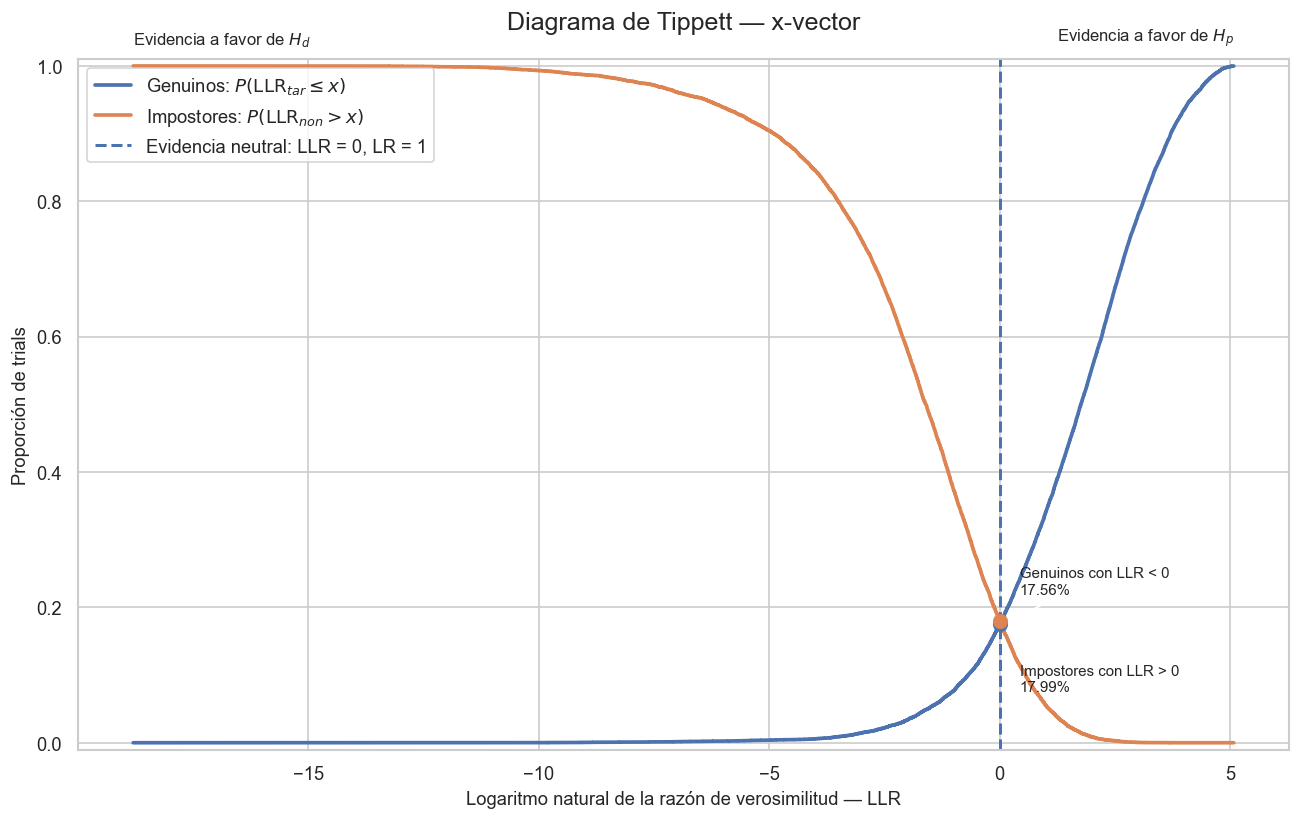

DIAGRAMA DE TIPPETT — x-vector
Genuinos con evidencia engañosa (LLR < 0): 17.5617%
Impostores con evidencia engañosa (LLR > 0): 17.9947%
Figura guardada en: c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\evaluation\figures\tippett_diagram_x_vector.png



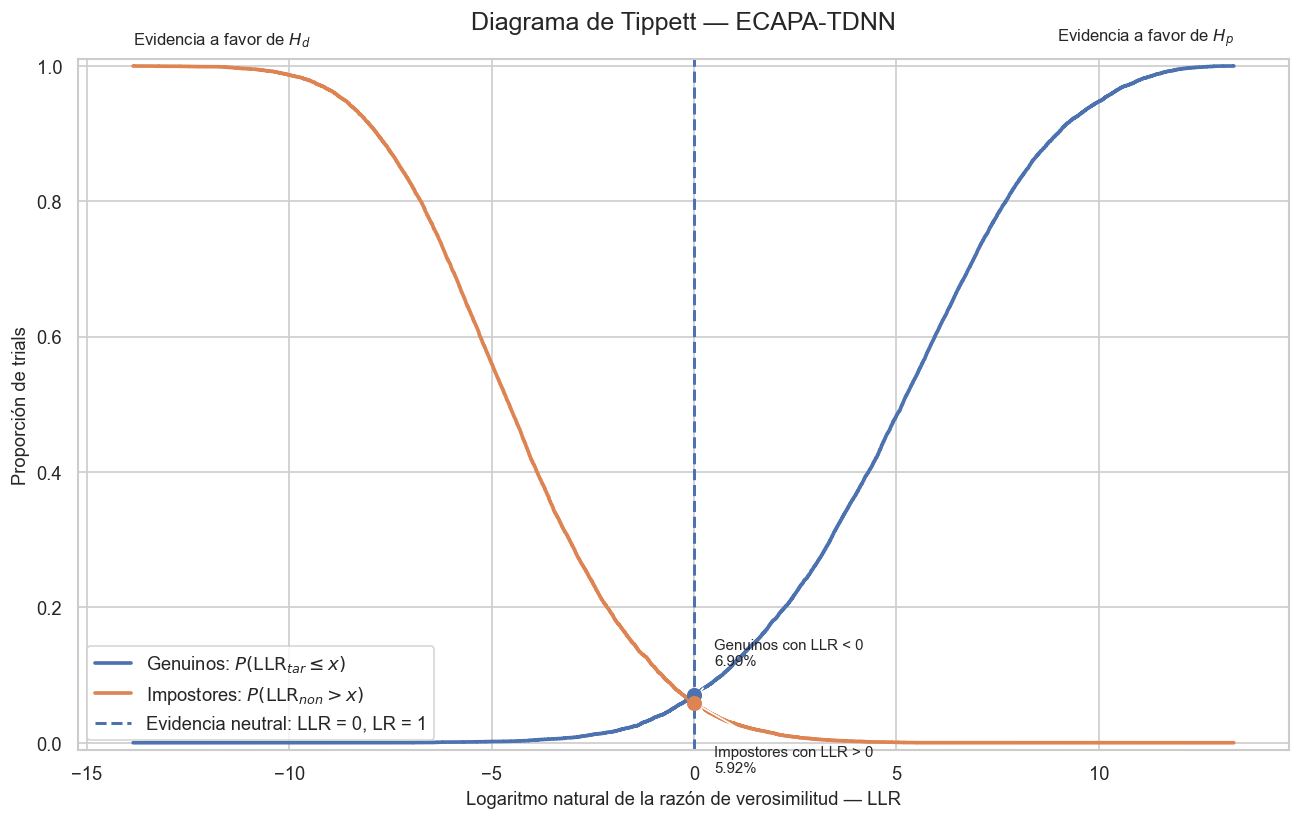

DIAGRAMA DE TIPPETT — ECAPA-TDNN
Genuinos con evidencia engañosa (LLR < 0): 6.9882%
Impostores con evidencia engañosa (LLR > 0): 5.9248%
Figura guardada en: c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\evaluation\figures\tippett_diagram_ecapa_tdnn.png



In [72]:

for model_name, model_results in tippett_results.items():

    # Recuperamos la tabla con las curvas acumuladas.
    curve_table = model_results["curve"]

    # Recuperamos el resumen de evidencia engañosa.
    summary = model_results["summary"]


    # --------------------------------------------------------
    # Creación de la figura
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(11, 7))


    # --------------------------------------------------------
    # Curva de trials genuinos
    # --------------------------------------------------------

    # Esta curva representa:
    #
    #   P(LLR_target <= x)
    #
    # Para x = 0 indica la proporción de genuinos con
    # evidencia neutral o favorable a H_d.
    ax.step(
        curve_table["llr_threshold"],
        curve_table["target_cdf"],
        where="post",
        linewidth=2.2,
        label=(
            "Genuinos: "
            r"$P(\mathrm{LLR}_{tar} \leq x)$"
        )
    )


    # --------------------------------------------------------
    # Curva de trials impostores
    # --------------------------------------------------------

    # Esta curva representa:
    #
    #   P(LLR_non_target > x)
    #
    # Para x = 0 indica la proporción de impostores con
    # evidencia engañosa a favor de H_p.
    ax.step(
        curve_table["llr_threshold"],
        curve_table["non_target_survival"],
        where="post",
        linewidth=2.2,
        label=(
            "Impostores: "
            r"$P(\mathrm{LLR}_{non} > x)$"
        )
    )


    # --------------------------------------------------------
    # Línea de evidencia neutral
    # --------------------------------------------------------

    # LLR = 0 equivale a LR = 1.
    #
    # A la izquierda:
    #   la evidencia favorece H_d.
    #
    # A la derecha:
    #   la evidencia favorece H_p.
    ax.axvline(
        x=0.0,
        linestyle="--",
        linewidth=1.8,
        label="Evidencia neutral: LLR = 0, LR = 1"
    )


    # --------------------------------------------------------
    # Proporciones de evidencia engañosa
    # --------------------------------------------------------

    target_misleading = summary[
        "proportion_target_misleading"
    ]

    non_target_misleading = summary[
        "proportion_non_target_misleading"
    ]

    # Marcamos sobre la línea neutral las proporciones
    # correspondientes a cada clase.
    ax.scatter(
        0.0,
        target_misleading,
        s=65,
        zorder=4
    )

    ax.scatter(
        0.0,
        non_target_misleading,
        s=65,
        zorder=4
    )

    ax.annotate(
        (
            "Genuinos con LLR < 0\n"
            f"{target_misleading:.2%}"
        ),
        xy=(0.0, target_misleading),
        xytext=(12, 18),
        textcoords="offset points",
        fontsize=9,
        arrowprops={
            "arrowstyle": "->",
            "linewidth": 1
        }
    )

    ax.annotate(
        (
            "Impostores con LLR > 0\n"
            f"{non_target_misleading:.2%}"
        ),
        xy=(0.0, non_target_misleading),
        xytext=(12, -42),
        textcoords="offset points",
        fontsize=9,
        arrowprops={
            "arrowstyle": "->",
            "linewidth": 1
        }
    )


    # --------------------------------------------------------
    # Regiones interpretativas
    # --------------------------------------------------------

    # Añadimos texto en la parte superior para recordar qué
    # hipótesis es favorecida en cada lado del gráfico.
    x_min = curve_table["llr_threshold"].min()
    x_max = curve_table["llr_threshold"].max()

    ax.text(
        x_min,
        1.025,
        r"Evidencia a favor de $H_d$",
        ha="left",
        va="bottom",
        fontsize=10
    )

    ax.text(
        x_max,
        1.025,
        r"Evidencia a favor de $H_p$",
        ha="right",
        va="bottom",
        fontsize=10
    )


    # --------------------------------------------------------
    # Formato de la gráfica
    # --------------------------------------------------------

    ax.set_title(
        f"Diagrama de Tippett — {model_name}",
        fontsize=15,
        pad=18
    )

    ax.set_xlabel(
        "Logaritmo natural de la razón de verosimilitud — LLR",
        fontsize=11
    )

    ax.set_ylabel(
        "Proporción de trials",
        fontsize=11
    )

    ax.set_ylim(-0.01, 1.01)

    ax.legend(
        loc="best"
    )

    plt.tight_layout()


    # --------------------------------------------------------
    # Guardado de la figura
    # --------------------------------------------------------

    model_filename = (
        model_name
        .lower()
        .replace("-", "_")
        .replace(" ", "_")
    )

    figure_path = (
        FIGURES_DIR
        / f"tippett_diagram_{model_filename}.png"
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print("=" * 75)
    print(f"DIAGRAMA DE TIPPETT — {model_name}")
    print("=" * 75)

    print(
        "Genuinos con evidencia engañosa "
        f"(LLR < 0): {target_misleading:.4%}"
    )

    print(
        "Impostores con evidencia engañosa "
        f"(LLR > 0): {non_target_misleading:.4%}"
    )

    print(f"Figura guardada en: {figure_path}\n")



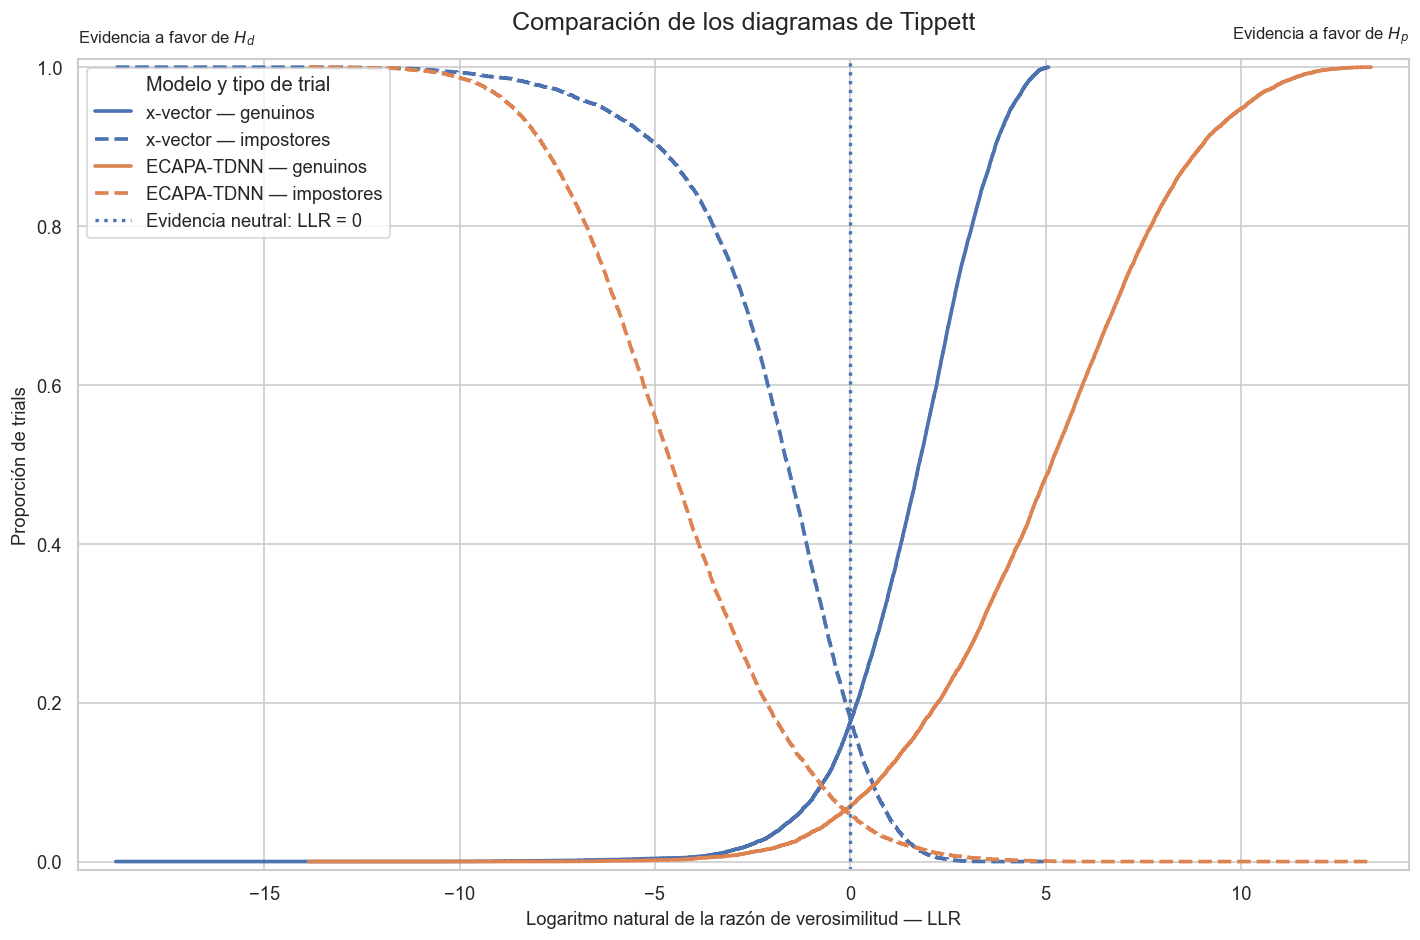

COMPARACIÓN DE EVIDENCIA EN DIRECCIÓN INCORRECTA


,modelo,genuinos_con_llr_negativo,impostores_con_llr_positivo,llr_genuino_mas_enganoso,llr_impostor_mas_enganoso
0,x-vector,17.5617%,17.9947%,-18.802594,3.693808
1,ECAPA-TDNN,6.9882%,5.9248%,-7.607503,5.654782


In [73]:
# DIAGRAMA DE TIPPETT COMPARATIVO

fig, ax = plt.subplots(figsize=(12, 8))


# ============================================================
# CURVAS DE AMBOS MODELOS
# ============================================================

for model_name, model_results in tippett_results.items():

    curve_table = model_results["curve"]

    # --------------------------------------------------------
    # Curva de trials genuinos
    # --------------------------------------------------------

    # Dibujamos primero la curva genuina y recuperamos
    # automáticamente el color asignado por Matplotlib.
    target_line, = ax.step(
        curve_table["llr_threshold"],
        curve_table["target_cdf"],
        where="post",
        linewidth=2.2,
        linestyle="-",
        label=f"{model_name} — genuinos"
    )

    model_color = target_line.get_color()


    # --------------------------------------------------------
    # Curva de trials impostores
    # --------------------------------------------------------

    # Utilizamos el mismo color del modelo, pero cambiamos
    # el estilo de línea para distinguir la clase.
    ax.step(
        curve_table["llr_threshold"],
        curve_table["non_target_survival"],
        where="post",
        linewidth=2.2,
        linestyle="--",
        color=model_color,
        label=f"{model_name} — impostores"
    )


# ============================================================
# LÍNEA DE EVIDENCIA NEUTRAL
# ============================================================

ax.axvline(
    x=0.0,
    linestyle=":",
    linewidth=2,
    label="Evidencia neutral: LLR = 0"
)


# ============================================================
# REGIONES DE INTERPRETACIÓN
# ============================================================

# Obtenemos el intervalo completo de LLR considerando
# ambos modelos.
all_llr_values = np.concatenate([
    df_eval["xvector_llr_oof"].to_numpy(dtype=float),
    df_eval["ecapa_llr_oof"].to_numpy(dtype=float)
])

global_llr_min = float(
    all_llr_values.min()
)

global_llr_max = float(
    all_llr_values.max()
)

# Añadimos una pequeña separación alrededor de los extremos
# para evitar que las curvas queden pegadas a los bordes.
llr_margin = 0.03 * (
    global_llr_max - global_llr_min
)

if np.isclose(llr_margin, 0.0):
    llr_margin = 1.0

x_lower_limit = (
    global_llr_min - llr_margin
)

x_upper_limit = (
    global_llr_max + llr_margin
)

ax.set_xlim(
    x_lower_limit,
    x_upper_limit
)

ax.text(
    x_lower_limit,
    1.025,
    r"Evidencia a favor de $H_d$",
    ha="left",
    va="bottom",
    fontsize=10
)

ax.text(
    x_upper_limit,
    1.025,
    r"Evidencia a favor de $H_p$",
    ha="right",
    va="bottom",
    fontsize=10
)


# ============================================================
# FORMATO DE LA FIGURA
# ============================================================

ax.set_title(
    "Comparación de los diagramas de Tippett",
    fontsize=15,
    pad=18
)

ax.set_xlabel(
    "Logaritmo natural de la razón de verosimilitud — LLR",
    fontsize=11
)

ax.set_ylabel(
    "Proporción de trials",
    fontsize=11
)

ax.set_ylim(
    -0.01,
    1.01
)

ax.legend(
    loc="best",
    title="Modelo y tipo de trial"
)

plt.tight_layout()


# ============================================================
# GUARDADO DE LA FIGURA
# ============================================================

tippett_comparison_path = (
    FIGURES_DIR / "tippett_diagram_comparison.png"
)

fig.savefig(
    tippett_comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


# ============================================================
# TABLA COMPARATIVA DE EVIDENCIA EN DIRECCIÓN INCORRECTA
# ============================================================

tippett_comparison_summary = (
    tippett_summary[
        [
            "modelo",
            "proportion_target_misleading",
            "proportion_non_target_misleading",
            "minimum_target_llr",
            "maximum_non_target_llr"
        ]
    ]
    .copy()
    .rename(columns={
        "proportion_target_misleading":
            "genuinos_con_llr_negativo",

        "proportion_non_target_misleading":
            "impostores_con_llr_positivo",

        "minimum_target_llr":
            "llr_genuino_mas_enganoso",

        "maximum_non_target_llr":
            "llr_impostor_mas_enganoso"
    })
)


print("=" * 90)
print("COMPARACIÓN DE EVIDENCIA EN DIRECCIÓN INCORRECTA")
print("=" * 90)

display(
    tippett_comparison_summary.style.format({
        "genuinos_con_llr_negativo": "{:.4%}",
        "impostores_con_llr_positivo": "{:.4%}",
        "llr_genuino_mas_enganoso": "{:.6f}",
        "llr_impostor_mas_enganoso": "{:.6f}"
    })
)

El modelo con mejor comportamiento debería presentar:

- Menor proporción de genuinos con LLR negativo.
- Menor proporción de impostores con LLR positivo.
- Menos extensión hacia valores extremos en la dirección incorrecta.
- Mayor separación entre sus curvas genuina e impostora.

## 10. Incertidumbre estadística mediante bootstrap agrupado

Las métricas calculadas hasta ahora, como EER, ROC-AUC, minDCF y $C_{\mathrm{llr}}$, corresponden a estimaciones puntuales obtenidas sobre el conjunto de trials disponible.

Por ejemplo, si un modelo obtiene:

$$
\mathrm{EER}=0.08
$$

este valor describe el rendimiento observado en el protocolo actual. Sin embargo, no indica cuánto podría cambiar el resultado si se evaluara el sistema sobre otra muestra similar de locutores y comparaciones.

Para estudiar la estabilidad de las métricas utilizaremos un procedimiento de remuestreo denominado **bootstrap**.

---

## ¿Qué es el bootstrap?

El bootstrap es una técnica estadística que permite aproximar la variabilidad de una estimación mediante remuestreo con reemplazo.

El procedimiento general consiste en:

1. Construir una nueva muestra a partir de los datos originales.
2. Permitir que algunas unidades aparezcan varias veces.
3. Permitir que otras unidades no aparezcan en una réplica.
4. Volver a calcular las métricas de interés.
5. Repetir el proceso muchas veces.
6. Analizar la distribución de las métricas obtenidas.

Cada muestra generada recibe el nombre de **réplica bootstrap**.

Si se realizan (B) réplicas, para una métrica (M) se obtienen:

$$
M^{(1)},M^{(2)},\ldots,M^{(B)}
$$

Esta distribución empírica permite estimar:

* Error estándar.
* Percentiles.
* Intervalos de confianza.
* Estabilidad de las diferencias entre modelos.

---

## ¿Por qué no remuestrear trials individualmente?

Los trials del protocolo no son observaciones completamente independientes.

Un mismo locutor de enrollment participa en múltiples comparaciones:

* Trials genuinos.
* Trials impostores.
* Comparaciones con diferentes audios de test.

Si cada fila se remuestreara de manera independiente, podrían separarse artificialmente comparaciones que comparten el mismo locutor.

Esto ignoraría parte de la estructura de dependencia de los datos y podría producir intervalos de confianza demasiado estrechos.

Por esta razón, se utilizará un **bootstrap agrupado**.

---

## Unidad de remuestreo

La unidad utilizada será:


enrollment_speaker_id


En cada réplica:

1. Se extraerán locutores de enrollment con reemplazo.
2. Se conservarán juntos todos los trials asociados con cada locutor seleccionado.
3. Si un locutor es seleccionado más de una vez, todos sus trials aparecerán repetidos el mismo número de veces.

De esta manera, el remuestreo respeta la agrupación principal del protocolo.

---

## Ejemplo conceptual

Supóngase que el conjunto contiene cuatro locutores:

$$
A,\ B,\ C,\ D
$$

Una réplica bootstrap podría seleccionar:

$$
A,\ C,\ C,\ D
$$

En esta réplica:

* Todos los trials asociados con (A) aparecen una vez.
* Los trials de (B) no aparecen.
* Todos los trials de (C) aparecen dos veces.
* Todos los trials de (D) aparecen una vez.

El número de grupos seleccionados es igual al número original de locutores, pero la composición cambia debido al muestreo con reemplazo.

---

## Bootstrap pareado

La comparación entre x-vector y ECAPA-TDNN será **pareada**.

Esto significa que en cada réplica ambos modelos se evaluarán sobre exactamente:

* Los mismos locutores seleccionados.
* Los mismos trials genuinos.
* Los mismos trials impostores.
* Las mismas repeticiones de grupos.

El emparejamiento es importante porque los dos modelos fueron evaluados sobre el mismo protocolo.

Así, las diferencias observadas dentro de cada réplica estarán asociadas principalmente con el comportamiento de los modelos y no con cambios en la muestra.

Para una métrica (M), se calculará en cada réplica:

$$
\Delta M^{(b)}
=

 M_{\mathrm{xvector}}^{(b)}
=
M_{\mathrm{ECAPA}}^{(b)}
$$

donde (b) identifica la réplica bootstrap.

---

## Métricas que se recalcularán

Para cada modelo y réplica se calcularán:

### Equal Error Rate

$$
\mathrm{EER}
$$

Un valor menor representa mejor desempeño.

### Área bajo la curva ROC

$$
\mathrm{AUC}
$$

Un valor mayor representa mejor desempeño.

### Minimum Detection Cost Function

$$
\mathrm{minDCF}
$$

Se utilizará la configuración de referencia:

$$
C_{\mathrm{miss}}=1
$$

$$
C_{\mathrm{fa}}=1
$$

$$
P_{\mathrm{target}}=0.5
$$

Un valor menor representa mejor desempeño.

### Costo de razones de verosimilitud

$$
C_{\mathrm{llr}}
$$

Se calculará utilizando los LLR fuera de muestra ya obtenidos.

Un valor menor representa una mejor combinación de discriminación y calibración.

### Costo mínimo de razones de verosimilitud

$$
C_{\mathrm{llr}}^{\min}
$$

Se calculará mediante PAV dentro de cada réplica.

Un valor menor representa mejor discriminación potencial.




---

## Número de réplicas

Se comenzará con:

$$
B=1000
$$

réplicas bootstrap.

Este número ofrece un equilibrio razonable entre:

* Estabilidad de los percentiles.
* Tiempo de ejecución.
* Cantidad de métricas recalculadas.

Para realizar pruebas iniciales del código puede utilizarse temporalmente un número menor, por ejemplo:

$$
B=100
$$

Sin embargo, los resultados finales deberán generarse nuevamente con las (1000) réplicas definidas.

---

## Semilla de reproducibilidad

El procedimiento de remuestreo utiliza números aleatorios.

Para poder reproducir exactamente las mismas réplicas se utilizará la semilla definida al inicio del notebook:


RANDOM_STATE = 2026


Esto garantiza que, mientras no cambien los datos ni el código, la selección de locutores sea la misma en ejecuciones posteriores.

---

## Validez de las réplicas

Debido al remuestreo, se verificará que cada réplica contenga:

* Al menos un trial genuino.
* Al menos un trial impostor.
* Scores finitos para ambos modelos.
* LLR finitos para ambos modelos.

Si una réplica no permitiera calcular alguna métrica, se registrará como inválida y no se utilizará silenciosamente.

No obstante, debido a la estructura balanceada del protocolo y al número de locutores disponibles, se espera que este problema sea poco probable.

---

## Resultados esperados

El procedimiento generará dos tipos principales de resultados.

### Distribuciones bootstrap por modelo

Para cada réplica se conservarán:

* EER de x-vector.
* EER de ECAPA-TDNN.
* AUC de x-vector.
* AUC de ECAPA-TDNN.
* minDCF de x-vector.
* minDCF de ECAPA-TDNN.
* $(C_{\mathrm{llr}})$ de x-vector.
* $(C_{\mathrm{llr}})$ de ECAPA-TDNN.
* $(C_{\mathrm{llr}}^{\min})$ de x-vector.
* $(C_{\mathrm{llr}}^{\min})$ de ECAPA-TDNN.

### Diferencias pareadas

También se calcularán las diferencias entre modelos dentro de cada réplica.

Estas distribuciones permitirán analizar:

* Si la diferencia observada es estable.
* Si el intervalo de confianza incluye el valor cero.
* Con qué frecuencia un modelo supera al otro.
* Si la conclusión cambia entre métricas.

---

## Precauciones de interpretación

Los intervalos obtenidos reflejarán la variabilidad asociada con el remuestreo de los locutores presentes en este experimento.

No incorporan completamente otras fuentes de incertidumbre, como:

* Selección de otro corpus.
* Cambios de canal o micrófono.
* Nuevas condiciones acústicas.
* Otra población de locutores.
* Un protocolo impostor diferente.
* Reentrenamiento de los modelos.
* Variabilidad en la extracción de embeddings.

Por lo tanto, los resultados deben interpretarse dentro del protocolo y corpus evaluados.

En la siguiente celda se preparará la estructura de grupos y los parámetros generales del bootstrap agrupado.


In [74]:
# PREPARACIÓN DEL BOOTSTRAP AGRUPADO

# Número de réplicas que se utilizará en los resultados finales.
N_BOOTSTRAP_REPLICATES = 1000

# Nivel de confianza para los intervalos percentiles.
BOOTSTRAP_CONFIDENCE_LEVEL = 0.95

# Unidad de remuestreo.
#
# Todos los trials asociados con un mismo locutor de enrollment
# se seleccionarán juntos dentro de cada réplica.
BOOTSTRAP_GROUP_COLUMN = "enrollment_speaker_id"

# Semilla independiente para el procedimiento bootstrap.
#
# Se utiliza la constante RANDOM_STATE definida al inicio
# del notebook para garantizar reproducibilidad.
BOOTSTRAP_RANDOM_STATE = RANDOM_STATE


# ============================================================
# DIRECTORIO DE SALIDA
# ============================================================

BOOTSTRAP_DIR = (
    EVALUATION_DIR
    / "bootstrap"
)

BOOTSTRAP_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# ARREGLOS NECESARIOS PARA LAS RÉPLICAS
# ============================================================

# Etiquetas reales:
#
#   1 = trial genuino
#   0 = trial impostor
bootstrap_labels = (
    df_eval["label"]
    .to_numpy(dtype=int)
)

# Identificador del grupo al que pertenece cada trial.
bootstrap_group_values = (
    df_eval[BOOTSTRAP_GROUP_COLUMN]
    .astype(str)
    .to_numpy()
)


# Scores de ambos modelos.
bootstrap_score_arrays = {
    "x-vector": (
        df_eval["xvector_cosine_score"]
        .to_numpy(dtype=float)
    ),
    "ECAPA-TDNN": (
        df_eval["ecapa_cosine_score"]
        .to_numpy(dtype=float)
    )
}


# LLR fuera de muestra de ambos modelos.
bootstrap_llr_arrays = {
    "x-vector": (
        df_eval["xvector_llr_oof"]
        .to_numpy(dtype=float)
    ),
    "ECAPA-TDNN": (
        df_eval["ecapa_llr_oof"]
        .to_numpy(dtype=float)
    )
}


# ============================================================
# IDENTIFICACIÓN DE LOS GRUPOS
# ============================================================

# np.unique devuelve los identificadores únicos ordenados.
unique_bootstrap_groups = np.unique(
    bootstrap_group_values
)

n_bootstrap_groups = len(
    unique_bootstrap_groups
)


# Para cada locutor almacenamos las posiciones de todos
# los trials que le corresponden.
#
# Se utilizan posiciones enteras para seleccionar rápidamente
# las mismas filas en etiquetas, scores y LLR.
group_to_positions = {
    group_id: np.flatnonzero(
        bootstrap_group_values == group_id
    )
    for group_id in unique_bootstrap_groups
}


# ============================================================
# RESUMEN DE LOS GRUPOS
# ============================================================

bootstrap_group_summary_rows = []

for group_id, group_positions in group_to_positions.items():

    group_labels = bootstrap_labels[
        group_positions
    ]

    n_genuine = int(
        (group_labels == 1).sum()
    )

    n_impostor = int(
        (group_labels == 0).sum()
    )

    bootstrap_group_summary_rows.append({
        "enrollment_speaker_id": group_id,
        "n_trials": len(group_positions),
        "n_genuine": n_genuine,
        "n_impostor": n_impostor,
        "contains_both_classes": (
            n_genuine > 0
            and n_impostor > 0
        )
    })


bootstrap_group_summary = pd.DataFrame(
    bootstrap_group_summary_rows
)


# ============================================================
# VALIDACIONES GENERALES
# ============================================================

print("=" * 85)
print("PREPARACIÓN DEL BOOTSTRAP AGRUPADO")
print("=" * 85)

print(f"\nNúmero total de trials: {len(df_eval):,}")
print(f"Número de grupos:       {n_bootstrap_groups:,}")
print(
    f"Número de réplicas:     "
    f"{N_BOOTSTRAP_REPLICATES:,}"
)
print(
    f"Nivel de confianza:     "
    f"{BOOTSTRAP_CONFIDENCE_LEVEL:.1%}"
)
print(
    f"Variable de agrupación: "
    f"{BOOTSTRAP_GROUP_COLUMN}"
)


# Debe existir más de un grupo para que el remuestreo
# tenga sentido.
if n_bootstrap_groups < 2:
    raise ValueError(
        "Se necesitan al menos dos grupos para realizar "
        "el bootstrap agrupado."
    )


# Verificamos que todos los trials estén asociados con
# exactamente un grupo.
total_positions_in_groups = sum(
    len(positions)
    for positions in group_to_positions.values()
)

if total_positions_in_groups != len(df_eval):
    raise RuntimeError(
        "La suma de trials contenidos en los grupos no "
        "coincide con el número total de filas."
    )


# Verificamos que no existan posiciones repetidas ni faltantes.
all_group_positions = np.concatenate(
    list(group_to_positions.values())
)

unique_positions, position_counts = np.unique(
    all_group_positions,
    return_counts=True
)

if len(unique_positions) != len(df_eval):
    raise RuntimeError(
        "No todos los trials fueron asignados a un grupo."
    )

if not np.all(position_counts == 1):
    raise RuntimeError(
        "Uno o más trials fueron asignados a múltiples grupos."
    )


# Etiquetas, scores y LLR deben tener la misma longitud.
for model_name in bootstrap_score_arrays:

    if (
        len(bootstrap_score_arrays[model_name])
        != len(df_eval)
    ):
        raise RuntimeError(
            f"El arreglo de scores de {model_name} no tiene "
            "la longitud esperada."
        )

    if (
        len(bootstrap_llr_arrays[model_name])
        != len(df_eval)
    ):
        raise RuntimeError(
            f"El arreglo de LLR de {model_name} no tiene "
            "la longitud esperada."
        )


# Todos los valores deben ser finitos.
for model_name in bootstrap_score_arrays:

    if not np.isfinite(
        bootstrap_score_arrays[model_name]
    ).all():
        raise RuntimeError(
            f"Los scores de {model_name} contienen "
            "valores no finitos."
        )

    if not np.isfinite(
        bootstrap_llr_arrays[model_name]
    ).all():
        raise RuntimeError(
            f"Los LLR de {model_name} contienen "
            "valores no finitos."
        )


print(
    "\n[OK] Todos los trials fueron asignados exactamente "
    "a un grupo."
)

print(
    "[OK] Los scores y LLR de ambos modelos están completos "
    "y son finitos."
)


# ============================================================
# ESTADÍSTICAS DEL TAMAÑO DE LOS GRUPOS
# ============================================================

group_size_statistics = (
    bootstrap_group_summary[
        [
            "n_trials",
            "n_genuine",
            "n_impostor"
        ]
    ]
    .describe()
    .transpose()
)

print("\nDistribución del tamaño de los grupos:")

display(
    group_size_statistics.style.format({
        "count": "{:,.0f}",
        "mean": "{:.2f}",
        "std": "{:.2f}",
        "min": "{:,.0f}",
        "25%": "{:.2f}",
        "50%": "{:.2f}",
        "75%": "{:.2f}",
        "max": "{:,.0f}"
    })
)


# Aunque no es obligatorio que cada grupo tenga las dos clases,
# conocer esta estructura ayuda a anticipar la estabilidad de
# las réplicas.
n_groups_with_both_classes = int(
    bootstrap_group_summary[
        "contains_both_classes"
    ].sum()
)

print(
    "\nGrupos que contienen trials genuinos e impostores: "
    f"{n_groups_with_both_classes:,} de "
    f"{n_bootstrap_groups:,}"
)


# ============================================================
# PERCENTILES DEL INTERVALO DE CONFIANZA
# ============================================================

# Para un intervalo del 95 %:
#
# alpha = 1 - 0.95 = 0.05
#
# límite inferior = 0.025
# límite superior = 0.975
bootstrap_alpha = (
    1.0
    - BOOTSTRAP_CONFIDENCE_LEVEL
)

BOOTSTRAP_LOWER_QUANTILE = (
    bootstrap_alpha / 2.0
)

BOOTSTRAP_UPPER_QUANTILE = (
    1.0
    - bootstrap_alpha / 2.0
)

print(
    "\nPercentiles utilizados para los intervalos:\n"
    f"  - Inferior: "
    f"{BOOTSTRAP_LOWER_QUANTILE:.3f}\n"
    f"  - Superior: "
    f"{BOOTSTRAP_UPPER_QUANTILE:.3f}"
)


# ============================================================
# GENERADOR ALEATORIO
# ============================================================

# default_rng es la interfaz moderna de generación de números
# aleatorios de NumPy.
bootstrap_rng = np.random.default_rng(
    BOOTSTRAP_RANDOM_STATE
)


# ============================================================
# GUARDADO DEL RESUMEN DE GRUPOS
# ============================================================

bootstrap_group_summary_path = (
    BOOTSTRAP_DIR
    / "bootstrap_group_summary.csv"
)

bootstrap_group_summary.to_csv(
    bootstrap_group_summary_path,
    index=False
)

print(
    "\nPreparación completada correctamente."
)

print(
    "\nResumen de grupos guardado en:\n"
    f"  - {bootstrap_group_summary_path}"
)


PREPARACIÓN DEL BOOTSTRAP AGRUPADO

Número total de trials: 26,330
Número de grupos:       87
Número de réplicas:     1,000
Nivel de confianza:     95.0%
Variable de agrupación: enrollment_speaker_id

[OK] Todos los trials fueron asignados exactamente a un grupo.
[OK] Los scores y LLR de ambos modelos están completos y son finitos.

Distribución del tamaño de los grupos:


,count,mean,std,min,25%,50%,75%,max
n_trials,87,302.64,194.61,114,185.50,259.00,339.50,"1,350"
n_genuine,87,151.32,187.80,11,47.00,93.00,172.00,"1,196"
n_impostor,87,151.32,39.15,66,113.00,166.00,184.00,213



Grupos que contienen trials genuinos e impostores: 87 de 87

Percentiles utilizados para los intervalos:
  - Inferior: 0.025
  - Superior: 0.975

Preparación completada correctamente.

Resumen de grupos guardado en:
  - c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\evaluation\bootstrap\bootstrap_group_summary.csv


In [76]:
# FUNCIÓN PARA GENERAR UNA RÉPLICA BOOTSTRAP PAREADA

def calculate_grouped_bootstrap_replicate(
    replicate_id,
    rng,
    unique_groups,
    group_to_positions,
    labels,
    score_arrays,
    llr_arrays,
    c_miss=1.0,
    c_fa=1.0,
    p_target=0.5
):
    """
    Genera una réplica bootstrap agrupada y calcula las métricas
    principales para todos los modelos.

    El procedimiento es pareado: ambos modelos se evalúan con
    exactamente los mismos grupos, trials y repeticiones.

    Parámetros
    ----------
    replicate_id : int
        Identificador numérico de la réplica.

    rng : numpy.random.Generator
        Generador de números aleatorios de NumPy.

    unique_groups : array-like
        Identificadores únicos de los grupos disponibles.

    group_to_positions : dict
        Diccionario que relaciona cada grupo con las posiciones
        de sus trials en los arreglos originales.

    labels : numpy.ndarray
        Etiquetas reales:

            1 = trial genuino
            0 = trial impostor

    score_arrays : dict
        Diccionario con los scores originales de cada modelo.

    llr_arrays : dict
        Diccionario con los LLR fuera de muestra de cada modelo.

    c_miss : float, default=1.0
        Costo de un falso rechazo para minDCF.

    c_fa : float, default=1.0
        Costo de una falsa aceptación para minDCF.

    p_target : float, default=0.5
        Probabilidad previa de una comparación genuina.

    Retorna
    -------
    dict
        Una fila de resultados con:

        - Información de la réplica.
        - Métricas de x-vector.
        - Métricas de ECAPA-TDNN.
        - Diferencias pareadas entre ambos modelos.
    """

    # --------------------------------------------------------
    # 1. Validaciones generales
    # --------------------------------------------------------

    unique_groups = np.asarray(
        unique_groups
    )

    labels = np.asarray(
        labels,
        dtype=int
    )

    if len(unique_groups) < 2:
        raise ValueError(
            "Se requieren al menos dos grupos para generar "
            "una réplica bootstrap."
        )

    if not np.isin(labels, [0, 1]).all():
        raise ValueError(
            "Las etiquetas deben contener únicamente 0 y 1."
        )

    model_names = list(
        score_arrays.keys()
    )

    if set(model_names) != set(llr_arrays.keys()):
        raise ValueError(
            "Los diccionarios de scores y LLR deben contener "
            "exactamente los mismos modelos."
        )


    # --------------------------------------------------------
    # 2. Selección de grupos con reemplazo
    # --------------------------------------------------------

    # Se selecciona la misma cantidad de grupos que existe
    # en el conjunto original.
    sampled_groups = rng.choice(
        unique_groups,
        size=len(unique_groups),
        replace=True
    )

    # Si un grupo fue seleccionado varias veces, sus posiciones
    # se concatenarán también varias veces.
    sampled_positions = np.concatenate([
        group_to_positions[group_id]
        for group_id in sampled_groups
    ])

    sampled_labels = labels[
        sampled_positions
    ]


    # --------------------------------------------------------
    # 3. Validación de las clases de la réplica
    # --------------------------------------------------------

    n_genuine = int(
        (sampled_labels == 1).sum()
    )

    n_impostor = int(
        (sampled_labels == 0).sum()
    )

    if n_genuine == 0 or n_impostor == 0:
        raise ValueError(
            f"La réplica {replicate_id} no contiene ambas clases."
        )


    # --------------------------------------------------------
    # 4. Información general de la réplica
    # --------------------------------------------------------

    replicate_result = {
        "replicate": int(replicate_id),
        "n_sampled_group_draws": int(
            len(sampled_groups)
        ),
        "n_unique_sampled_groups": int(
            len(np.unique(sampled_groups))
        ),
        "n_sampled_trials": int(
            len(sampled_positions)
        ),
        "n_genuine": n_genuine,
        "n_impostor": n_impostor
    }


    # --------------------------------------------------------
    # 5. Cálculo de métricas para cada modelo
    # --------------------------------------------------------

    for model_name in model_names:

        model_scores = np.asarray(
            score_arrays[model_name],
            dtype=float
        )[sampled_positions]

        model_llr = np.asarray(
            llr_arrays[model_name],
            dtype=float
        )[sampled_positions]


        # ----------------------------------------------------
        # Validación de los valores
        # ----------------------------------------------------

        if not np.isfinite(model_scores).all():
            raise ValueError(
                f"La réplica {replicate_id} contiene scores "
                f"no finitos para {model_name}."
            )

        if not np.isfinite(model_llr).all():
            raise ValueError(
                f"La réplica {replicate_id} contiene LLR "
                f"no finitos para {model_name}."
            )


        # ----------------------------------------------------
        # 5.1 Equal Error Rate
        # ----------------------------------------------------

        replicate_threshold_table = (
            calculate_threshold_curve(
                labels=sampled_labels,
                scores=model_scores
            )
        )

        replicate_eer = calculate_eer(
            threshold_table=replicate_threshold_table
        )

        eer_value = float(
            replicate_eer["eer_interpolated"]
        )


        # ----------------------------------------------------
        # 5.2 Área bajo la curva ROC
        # ----------------------------------------------------

        auc_value = float(
            roc_auc_score(
                y_true=sampled_labels,
                y_score=model_scores
            )
        )


        # ----------------------------------------------------
        # 5.3 minDCF normalizada
        # ----------------------------------------------------

        (
            _,
            replicate_dcf_summary
        ) = calculate_detection_cost(
            threshold_table=replicate_threshold_table,
            c_miss=c_miss,
            c_fa=c_fa,
            p_target=p_target
        )

        min_dcf_value = float(
            replicate_dcf_summary[
                "min_dcf_normalized"
            ]
        )


        # ----------------------------------------------------
        # 5.4 C_llr observado
        # ----------------------------------------------------

        (
            replicate_cllr_summary,
            _,
            _
        ) = calculate_cllr(
            labels=sampled_labels,
            llr_values=model_llr
        )

        cllr_value = float(
            replicate_cllr_summary["cllr"]
        )


        # ----------------------------------------------------
        # 5.5 C_llr mínimo
        # ----------------------------------------------------

        # Se aplica PAV sobre los LLR fuera de muestra de la
        # réplica. Esto mantiene la comparación con el C_llr
        # observado calculado sobre esos mismos valores.
        (
            replicate_cllr_min_summary,
            _,
            _,
            _
        ) = calculate_cllr_min_pav(
            labels=sampled_labels,
            scores=model_llr
        )

        cllr_min_value = float(
            replicate_cllr_min_summary[
                "cllr_min"
            ]
        )


        # ----------------------------------------------------
        # 5.6 Pérdida de calibración
        # ----------------------------------------------------

        calibration_loss = (
            cllr_value
            - cllr_min_value
        )

        # Permitimos una pequeña tolerancia por redondeo.
        if calibration_loss < -1e-10:
            raise RuntimeError(
                f"C_llr fue menor que C_llr mínimo en la "
                f"réplica {replicate_id} para {model_name}."
            )

        calibration_loss = max(
            0.0,
            calibration_loss
        )


        # ----------------------------------------------------
        # 5.7 Almacenamiento
        # ----------------------------------------------------

        # Creamos un prefijo uniforme para las columnas.
        model_prefix = (
            model_name
            .lower()
            .replace("-", "_")
            .replace(" ", "_")
        )

        replicate_result[
            f"{model_prefix}_eer"
        ] = eer_value

        replicate_result[
            f"{model_prefix}_auc"
        ] = auc_value

        replicate_result[
            f"{model_prefix}_min_dcf"
        ] = min_dcf_value

        replicate_result[
            f"{model_prefix}_cllr"
        ] = cllr_value

        replicate_result[
            f"{model_prefix}_cllr_min"
        ] = cllr_min_value

        replicate_result[
            f"{model_prefix}_calibration_loss"
        ] = calibration_loss


    # --------------------------------------------------------
    # 6. Diferencias pareadas entre modelos
    # --------------------------------------------------------

    # Convención:
    #
    #   diferencia = x-vector - ECAPA-TDNN
    #
    # Para métricas donde un valor menor es mejor:
    #   diferencia positiva favorece a ECAPA-TDNN.
    #
    # Para AUC, donde un valor mayor es mejor:
    #   diferencia negativa favorece a ECAPA-TDNN.
    xvector_prefix = "x_vector"
    ecapa_prefix = "ecapa_tdnn"

    replicate_result["difference_eer"] = (
        replicate_result[f"{xvector_prefix}_eer"]
        - replicate_result[f"{ecapa_prefix}_eer"]
    )

    replicate_result["difference_auc"] = (
        replicate_result[f"{xvector_prefix}_auc"]
        - replicate_result[f"{ecapa_prefix}_auc"]
    )

    replicate_result["difference_min_dcf"] = (
        replicate_result[f"{xvector_prefix}_min_dcf"]
        - replicate_result[f"{ecapa_prefix}_min_dcf"]
    )

    replicate_result["difference_cllr"] = (
        replicate_result[f"{xvector_prefix}_cllr"]
        - replicate_result[f"{ecapa_prefix}_cllr"]
    )

    replicate_result["difference_cllr_min"] = (
        replicate_result[f"{xvector_prefix}_cllr_min"]
        - replicate_result[f"{ecapa_prefix}_cllr_min"]
    )

    replicate_result["difference_calibration_loss"] = (
        replicate_result[
            f"{xvector_prefix}_calibration_loss"
        ]
        - replicate_result[
            f"{ecapa_prefix}_calibration_loss"
        ]
    )


    # --------------------------------------------------------
    # 7. Validaciones finales
    # --------------------------------------------------------

    numeric_result_values = [
        value
        for key, value in replicate_result.items()
        if key != "replicate"
    ]

    if not np.isfinite(
        np.asarray(
            numeric_result_values,
            dtype=float
        )
    ).all():
        raise RuntimeError(
            f"La réplica {replicate_id} produjo resultados "
            "no finitos."
        )

    return replicate_result


print(
    "Función calculate_grouped_bootstrap_replicate "
    "definida correctamente."
)



Función calculate_grouped_bootstrap_replicate definida correctamente.


In [78]:
# EJECUCIÓN DEL BOOTSTRAP AGRUPADO Y PAREADO

# tqdm permite mostrar una barra de progreso durante la
# ejecución de las réplicas.
from tqdm.auto import tqdm


# ============================================================
# 1. REINICIALIZACIÓN DEL GENERADOR ALEATORIO
# ============================================================

# Reinicializamos el generador para garantizar que la ejecución
# completa siempre comience desde la misma semilla.
#
# La réplica de prueba anterior utilizó un generador separado,
# por lo que no afecta esta secuencia.
bootstrap_rng = np.random.default_rng(
    BOOTSTRAP_RANDOM_STATE
)


# ============================================================
# 2. CONFIGURACIÓN DE LA EJECUCIÓN
# ============================================================

# El objetivo es obtener exactamente el número solicitado
# de réplicas válidas.
target_valid_replicates = N_BOOTSTRAP_REPLICATES

# Permitimos intentos adicionales en caso de que alguna muestra
# bootstrap no contenga ambas clases o produzca otro problema.
#
# Debido a la estructura del protocolo, se espera que las
# réplicas inválidas sean poco frecuentes.
MAX_BOOTSTRAP_ATTEMPTS = (
    N_BOOTSTRAP_REPLICATES * 2
)

# Almacenará las réplicas válidas.
bootstrap_result_rows = []

# Almacenará información sobre intentos inválidos.
bootstrap_error_rows = []

valid_replicates = 0
attempt_id = 0


# ============================================================
# 3. EJECUCIÓN DE LAS RÉPLICAS
# ============================================================

progress_bar = tqdm(
    total=target_valid_replicates,
    desc="Réplicas bootstrap válidas",
    unit="réplica"
)


while (
    valid_replicates < target_valid_replicates
    and attempt_id < MAX_BOOTSTRAP_ATTEMPTS
):

    attempt_id += 1

    try:

        # El identificador de réplica corresponde únicamente
        # a las muestras válidas:
        #
        #   1, 2, ..., N_BOOTSTRAP_REPLICATES
        replicate_result = (
            calculate_grouped_bootstrap_replicate(
                replicate_id=valid_replicates + 1,
                rng=bootstrap_rng,
                unique_groups=unique_bootstrap_groups,
                group_to_positions=group_to_positions,
                labels=bootstrap_labels,
                score_arrays=bootstrap_score_arrays,
                llr_arrays=bootstrap_llr_arrays,
                c_miss=REFERENCE_C_MISS,
                c_fa=REFERENCE_C_FA,
                p_target=REFERENCE_P_TARGET
            )
        )

        # Registramos también el número de intento que produjo
        # la réplica válida, para conservar trazabilidad.
        replicate_result["attempt_id"] = attempt_id

        bootstrap_result_rows.append(
            replicate_result
        )

        valid_replicates += 1

        progress_bar.update(1)


    except Exception as error:

        # El intento se registra explícitamente en lugar de ser
        # descartado de forma silenciosa.
        bootstrap_error_rows.append({
            "attempt_id": attempt_id,
            "error_type": type(error).__name__,
            "error_message": str(error)
        })


progress_bar.close()


# ============================================================
# 4. VERIFICACIÓN DEL NÚMERO DE RÉPLICAS
# ============================================================

if valid_replicates < target_valid_replicates:

    raise RuntimeError(
        "No fue posible obtener el número solicitado de "
        "réplicas bootstrap válidas.\n"
        f"Réplicas requeridas: {target_valid_replicates:,}\n"
        f"Réplicas obtenidas: {valid_replicates:,}\n"
        f"Intentos realizados: {attempt_id:,}"
    )


# ============================================================
# 5. CONSTRUCCIÓN DE LAS TABLAS
# ============================================================

bootstrap_results = pd.DataFrame(
    bootstrap_result_rows
)

bootstrap_errors = pd.DataFrame(
    bootstrap_error_rows,
    columns=[
        "attempt_id",
        "error_type",
        "error_message"
    ]
)


# Colocamos los identificadores al inicio de la tabla.
identifier_columns = [
    "replicate",
    "attempt_id"
]

remaining_columns = [
    column
    for column in bootstrap_results.columns
    if column not in identifier_columns
]

bootstrap_results = bootstrap_results[
    identifier_columns + remaining_columns
]


# ============================================================
# 6. VALIDACIONES DE LA TABLA COMPLETA
# ============================================================

print("\n" + "=" * 90)
print("VALIDACIÓN DE LA EJECUCIÓN BOOTSTRAP")
print("=" * 90)

print(
    f"\nRéplicas válidas obtenidas: "
    f"{len(bootstrap_results):,}"
)

print(
    f"Intentos realizados:        "
    f"{attempt_id:,}"
)

print(
    f"Intentos inválidos:          "
    f"{len(bootstrap_errors):,}"
)


# Deben existir exactamente las réplicas solicitadas.
if len(bootstrap_results) != N_BOOTSTRAP_REPLICATES:

    raise RuntimeError(
        "La tabla no contiene el número esperado de réplicas."
    )


# Los identificadores deben ser consecutivos y únicos.
expected_replicate_ids = np.arange(
    1,
    N_BOOTSTRAP_REPLICATES + 1
)

observed_replicate_ids = (
    bootstrap_results["replicate"]
    .to_numpy(dtype=int)
)

if not np.array_equal(
    observed_replicate_ids,
    expected_replicate_ids
):
    raise RuntimeError(
        "Los identificadores de las réplicas no son "
        "consecutivos o están desordenados."
    )


if bootstrap_results["replicate"].duplicated().any():

    raise RuntimeError(
        "Se encontraron identificadores de réplica duplicados."
    )


# Todas las columnas numéricas deben contener valores finitos.
numeric_bootstrap_columns = (
    bootstrap_results
    .select_dtypes(include=[np.number])
    .columns
)

if not np.isfinite(
    bootstrap_results[
        numeric_bootstrap_columns
    ].to_numpy(dtype=float)
).all():

    raise RuntimeError(
        "La tabla bootstrap contiene valores numéricos "
        "faltantes o infinitos."
    )


# Todas las réplicas deben conservar ambas clases.
if (
    (bootstrap_results["n_genuine"] <= 0).any()
    or
    (bootstrap_results["n_impostor"] <= 0).any()
):

    raise RuntimeError(
        "Una o más réplicas válidas no contienen ambas clases."
    )


print(
    "\n[OK] Se obtuvieron todas las réplicas solicitadas."
)

print(
    "[OK] Los identificadores son consecutivos y únicos."
)

print(
    "[OK] Todas las métricas son finitas."
)

print(
    "[OK] Todas las réplicas contienen trials genuinos "
    "e impostores."
)


# ============================================================
# 7. INSPECCIÓN INICIAL
# ============================================================

print("\nPrimeras cinco réplicas:")

display(
    bootstrap_results.head().style.format({
        "replicate": "{:,.0f}",
        "attempt_id": "{:,.0f}",
        "n_sampled_group_draws": "{:,.0f}",
        "n_unique_sampled_groups": "{:,.0f}",
        "n_sampled_trials": "{:,.0f}",
        "n_genuine": "{:,.0f}",
        "n_impostor": "{:,.0f}",

        "x_vector_eer": "{:.4%}",
        "x_vector_auc": "{:.6f}",
        "x_vector_min_dcf": "{:.6f}",
        "x_vector_cllr": "{:.6f}",
        "x_vector_cllr_min": "{:.6f}",
        "x_vector_calibration_loss": "{:.6f}",

        "ecapa_tdnn_eer": "{:.4%}",
        "ecapa_tdnn_auc": "{:.6f}",
        "ecapa_tdnn_min_dcf": "{:.6f}",
        "ecapa_tdnn_cllr": "{:.6f}",
        "ecapa_tdnn_cllr_min": "{:.6f}",
        "ecapa_tdnn_calibration_loss": "{:.6f}",

        "difference_eer": "{:.4%}",
        "difference_auc": "{:.6f}",
        "difference_min_dcf": "{:.6f}",
        "difference_cllr": "{:.6f}",
        "difference_cllr_min": "{:.6f}",
        "difference_calibration_loss": "{:.6f}"
    })
)


# ============================================================
# 8. RESUMEN DE LOS TAMAÑOS DE LAS RÉPLICAS
# ============================================================

bootstrap_sample_size_summary = (
    bootstrap_results[
        [
            "n_unique_sampled_groups",
            "n_sampled_trials",
            "n_genuine",
            "n_impostor"
        ]
    ]
    .describe()
    .transpose()
)

print("\nResumen de la composición de las réplicas:")

display(
    bootstrap_sample_size_summary.style.format({
        "count": "{:,.0f}",
        "mean": "{:,.2f}",
        "std": "{:,.2f}",
        "min": "{:,.0f}",
        "25%": "{:,.2f}",
        "50%": "{:,.2f}",
        "75%": "{:,.2f}",
        "max": "{:,.0f}"
    })
)


# ============================================================
# 9. GUARDADO DE LOS RESULTADOS CRUDOS
# ============================================================

bootstrap_results_path = (
    BOOTSTRAP_DIR
    / "grouped_paired_bootstrap_replicates.csv"
)

bootstrap_errors_path = (
    BOOTSTRAP_DIR
    / "grouped_bootstrap_invalid_attempts.csv"
)

bootstrap_sample_size_path = (
    BOOTSTRAP_DIR
    / "bootstrap_sample_size_summary.csv"
)


bootstrap_results.to_csv(
    bootstrap_results_path,
    index=False
)

bootstrap_errors.to_csv(
    bootstrap_errors_path,
    index=False
)

bootstrap_sample_size_summary.to_csv(
    bootstrap_sample_size_path
)


print(
    "\nResultados guardados correctamente en:\n"
    f"  - {bootstrap_results_path}\n"
    f"  - {bootstrap_errors_path}\n"
    f"  - {bootstrap_sample_size_path}"
)


Réplicas bootstrap válidas:   0%|          | 0/1000 [00:00<?, ?réplica/s]


VALIDACIÓN DE LA EJECUCIÓN BOOTSTRAP

Réplicas válidas obtenidas: 1,000
Intentos realizados:        1,000
Intentos inválidos:          0

[OK] Se obtuvieron todas las réplicas solicitadas.
[OK] Los identificadores son consecutivos y únicos.
[OK] Todas las métricas son finitas.
[OK] Todas las réplicas contienen trials genuinos e impostores.

Primeras cinco réplicas:


,replicate,attempt_id,n_sampled_group_draws,n_unique_sampled_groups,n_sampled_trials,n_genuine,n_impostor,x_vector_eer,x_vector_auc,x_vector_min_dcf,x_vector_cllr,x_vector_cllr_min,x_vector_calibration_loss,ecapa_tdnn_eer,ecapa_tdnn_auc,ecapa_tdnn_min_dcf,ecapa_tdnn_cllr,ecapa_tdnn_cllr_min,ecapa_tdnn_calibration_loss,difference_eer,difference_auc,difference_min_dcf,difference_cllr,difference_cllr_min,difference_calibration_loss
0,1,1,87,60,"26,769","13,411","13,358",18.1764%,0.899287,0.361123,0.604327,0.569646,0.034681,4.9933%,0.989865,0.097745,0.190378,0.183094,0.007284,13.1831%,-0.090578,0.263379,0.413949,0.386552,0.027397
1,2,2,87,55,"27,187","14,131","13,056",18.0760%,0.902346,0.355641,0.575918,0.553528,0.022390,5.5764%,0.987866,0.110457,0.207654,0.198958,0.008696,12.4996%,-0.085520,0.245183,0.368264,0.354570,0.013694
2,3,3,87,52,"25,140","11,717","13,423",16.6425%,0.913092,0.325632,0.555490,0.519673,0.035817,4.3060%,0.992498,0.084966,0.175025,0.155658,0.019368,12.3364%,-0.079406,0.240665,0.380464,0.364015,0.016449
3,4,4,87,56,"24,623","11,777","12,846",17.0637%,0.908629,0.339500,0.569387,0.545164,0.024223,4.9758%,0.990026,0.097365,0.192463,0.182558,0.009905,12.0879%,-0.081396,0.242136,0.376924,0.362606,0.014318
4,5,5,87,52,"27,309","14,257","13,052",20.5233%,0.880062,0.403685,0.660721,0.608797,0.051924,6.1753%,0.985316,0.123395,0.228947,0.224132,0.004815,14.3480%,-0.105253,0.280290,0.431774,0.384664,0.047109



Resumen de la composición de las réplicas:


,count,mean,std,min,25%,50%,75%,max
n_unique_sampled_groups,"1,000",55.03,2.84,47,53.00,55.00,57.00,64
n_sampled_trials,"1,000","26,342.81","1,765.84","21,516","25,139.50","26,336.50","27,475.50","32,001"
n_genuine,"1,000","13,176.86","1,705.76","8,627","12,036.25","13,181.50","14,244.75","18,833"
n_impostor,"1,000","13,165.95",354.98,"12,098","12,930.00","13,160.50","13,413.25","14,335"



Resultados guardados correctamente en:
  - c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\evaluation\bootstrap\grouped_paired_bootstrap_replicates.csv
  - c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\evaluation\bootstrap\grouped_bootstrap_invalid_attempts.csv
  - c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\evaluation\bootstrap\bootstrap_sample_size_summary.csv


In [79]:
# INTERVALOS DE CONFIANZA BOOTSTRAP POR MODELO


# Configuración de las métricas incluidas en el resumen.
#
# direction indica qué dirección representa mejor rendimiento:
#
#   lower -> un valor menor es mejor.
#   higher -> un valor mayor es mejor.
bootstrap_metric_configuration = {
    "eer": {
        "nombre": "EER",
        "direction": "lower"
    },
    "auc": {
        "nombre": "ROC-AUC",
        "direction": "higher"
    },
    "min_dcf": {
        "nombre": "minDCF normalizada",
        "direction": "lower"
    },
    "cllr": {
        "nombre": "C_llr",
        "direction": "lower"
    },
    "cllr_min": {
        "nombre": "C_llr mínimo",
        "direction": "lower"
    },
    "calibration_loss": {
        "nombre": "Pérdida de calibración",
        "direction": "lower"
    }
}


# Relación entre el nombre legible del modelo y el prefijo
# utilizado en las columnas de bootstrap_results.
bootstrap_model_prefixes = {
    "x-vector": "x_vector",
    "ECAPA-TDNN": "ecapa_tdnn"
}


# ============================================================
# 1. ESTIMACIONES PUNTUALES DEL CONJUNTO ORIGINAL
# ============================================================

# Recuperamos los valores calculados previamente sobre todos
# los trials originales.
point_estimates = {
    "x-vector": {
        "eer": float(
            eer_results.loc[
                eer_results["modelo"] == "x-vector",
                "eer_interpolated"
            ].iloc[0]
        ),
        "auc": float(
            roc_summary.loc[
                roc_summary["modelo"] == "x-vector",
                "auc"
            ].iloc[0]
        ),
        "min_dcf": float(
            dcf_summary.loc[
                dcf_summary["modelo"] == "x-vector",
                "min_dcf_normalized"
            ].iloc[0]
        ),
        "cllr": float(
            cllr_summary.loc[
                cllr_summary["modelo"] == "x-vector",
                "cllr"
            ].iloc[0]
        ),
        "cllr_min": float(
            cllr_min_summary.loc[
                cllr_min_summary["modelo"] == "x-vector",
                "cllr_min_from_oof_llr"
            ].iloc[0]
        ),
        "calibration_loss": float(
            cllr_min_summary.loc[
                cllr_min_summary["modelo"] == "x-vector",
                "cllr_calibration_loss"
            ].iloc[0]
        )
    },

    "ECAPA-TDNN": {
        "eer": float(
            eer_results.loc[
                eer_results["modelo"] == "ECAPA-TDNN",
                "eer_interpolated"
            ].iloc[0]
        ),
        "auc": float(
            roc_summary.loc[
                roc_summary["modelo"] == "ECAPA-TDNN",
                "auc"
            ].iloc[0]
        ),
        "min_dcf": float(
            dcf_summary.loc[
                dcf_summary["modelo"] == "ECAPA-TDNN",
                "min_dcf_normalized"
            ].iloc[0]
        ),
        "cllr": float(
            cllr_summary.loc[
                cllr_summary["modelo"] == "ECAPA-TDNN",
                "cllr"
            ].iloc[0]
        ),
        "cllr_min": float(
            cllr_min_summary.loc[
                cllr_min_summary["modelo"] == "ECAPA-TDNN",
                "cllr_min_from_oof_llr"
            ].iloc[0]
        ),
        "calibration_loss": float(
            cllr_min_summary.loc[
                cllr_min_summary["modelo"] == "ECAPA-TDNN",
                "cllr_calibration_loss"
            ].iloc[0]
        )
    }
}


# ============================================================
# 2. FUNCIÓN PARA RESUMIR UNA DISTRIBUCIÓN BOOTSTRAP
# ============================================================

def summarize_bootstrap_distribution(
    bootstrap_values,
    point_estimate,
    lower_quantile,
    upper_quantile
):
    """
    Resume una distribución bootstrap y calcula un intervalo
    de confianza percentil.

    Parámetros
    ----------
    bootstrap_values : array-like
        Valores de una métrica obtenidos en las réplicas.

    point_estimate : float
        Métrica calculada sobre el conjunto original.

    lower_quantile : float
        Cuantil inferior del intervalo.

    upper_quantile : float
        Cuantil superior del intervalo.

    Retorna
    -------
    dict
        Estadísticas descriptivas e intervalo de confianza.
    """

    bootstrap_values = np.asarray(
        bootstrap_values,
        dtype=float
    )

    if len(bootstrap_values) == 0:
        raise ValueError(
            "La distribución bootstrap está vacía."
        )

    if not np.isfinite(bootstrap_values).all():
        raise ValueError(
            "La distribución bootstrap contiene valores "
            "no finitos."
        )

    bootstrap_mean = float(
        np.mean(bootstrap_values)
    )

    bootstrap_median = float(
        np.median(bootstrap_values)
    )

    # ddof=1 produce la desviación estándar muestral,
    # utilizada aquí como error estándar bootstrap.
    bootstrap_standard_error = float(
        np.std(
            bootstrap_values,
            ddof=1
        )
    )

    confidence_lower = float(
        np.quantile(
            bootstrap_values,
            lower_quantile
        )
    )

    confidence_upper = float(
        np.quantile(
            bootstrap_values,
            upper_quantile
        )
    )

    # Sesgo bootstrap estimado:
    #
    # media de las réplicas - estimación original.
    estimated_bias = (
        bootstrap_mean
        - point_estimate
    )

    return {
        "point_estimate": float(point_estimate),
        "bootstrap_mean": bootstrap_mean,
        "bootstrap_median": bootstrap_median,
        "bootstrap_standard_error": (
            bootstrap_standard_error
        ),
        "estimated_bias": float(estimated_bias),
        "confidence_lower": confidence_lower,
        "confidence_upper": confidence_upper,
        "confidence_interval_width": (
            confidence_upper
            - confidence_lower
        ),
        "n_replicates": len(bootstrap_values)
    }


# ============================================================
# 3. CÁLCULO DE LOS INTERVALOS PARA CADA MODELO
# ============================================================

bootstrap_confidence_rows = []


for model_name, model_prefix in bootstrap_model_prefixes.items():

    for metric_key, metric_info in (
        bootstrap_metric_configuration.items()
    ):

        bootstrap_column = (
            f"{model_prefix}_{metric_key}"
        )

        if bootstrap_column not in bootstrap_results.columns:
            raise KeyError(
                f"No se encontró la columna "
                f"'{bootstrap_column}' en bootstrap_results."
            )

        metric_summary = summarize_bootstrap_distribution(
            bootstrap_values=bootstrap_results[
                bootstrap_column
            ].to_numpy(dtype=float),

            point_estimate=point_estimates[
                model_name
            ][metric_key],

            lower_quantile=BOOTSTRAP_LOWER_QUANTILE,
            upper_quantile=BOOTSTRAP_UPPER_QUANTILE
        )

        bootstrap_confidence_rows.append({
            "modelo": model_name,
            "metrica": metric_key,
            "nombre_metrica": metric_info["nombre"],
            "mejor_direccion": metric_info["direction"],
            **metric_summary
        })


bootstrap_confidence_intervals = pd.DataFrame(
    bootstrap_confidence_rows
)


# Ordenamos la tabla de acuerdo con el orden definido
# en la configuración.
metric_order = list(
    bootstrap_metric_configuration.keys()
)

bootstrap_confidence_intervals["metrica"] = pd.Categorical(
    bootstrap_confidence_intervals["metrica"],
    categories=metric_order,
    ordered=True
)

bootstrap_confidence_intervals = (
    bootstrap_confidence_intervals
    .sort_values(
        ["metrica", "modelo"]
    )
    .reset_index(drop=True)
)


# ============================================================
# 4. VALIDACIONES DE LOS INTERVALOS
# ============================================================

for _, row in bootstrap_confidence_intervals.iterrows():

    if row["confidence_lower"] > row["confidence_upper"]:
        raise RuntimeError(
            "El límite inferior es mayor que el superior para "
            f"{row['modelo']} — {row['nombre_metrica']}."
        )

    if row["confidence_interval_width"] < 0:
        raise RuntimeError(
            "Se obtuvo un intervalo de amplitud negativa para "
            f"{row['modelo']} — {row['nombre_metrica']}."
        )

    if row["n_replicates"] != N_BOOTSTRAP_REPLICATES:
        raise RuntimeError(
            "El número de réplicas utilizado no coincide con "
            "el número solicitado."
        )


print(
    "[OK] Todos los intervalos de confianza fueron "
    "calculados correctamente."
)


# ============================================================
# 5. PRESENTACIÓN DE RESULTADOS
# ============================================================

print("\n" + "=" * 100)
print(
    f"INTERVALOS DE CONFIANZA BOOTSTRAP "
    f"DEL {BOOTSTRAP_CONFIDENCE_LEVEL:.0%}"
)
print("=" * 100)

display(
    bootstrap_confidence_intervals.style.format({
        "point_estimate": "{:.6f}",
        "bootstrap_mean": "{:.6f}",
        "bootstrap_median": "{:.6f}",
        "bootstrap_standard_error": "{:.6f}",
        "estimated_bias": "{:+.6f}",
        "confidence_lower": "{:.6f}",
        "confidence_upper": "{:.6f}",
        "confidence_interval_width": "{:.6f}",
        "n_replicates": "{:,.0f}"
    })
)


# ============================================================
# 6. TABLA DE INTERVALOS EN FORMATO COMPACTO
# ============================================================

bootstrap_confidence_compact = (
    bootstrap_confidence_intervals[
        [
            "modelo",
            "metrica",
            "nombre_metrica",
            "point_estimate",
            "bootstrap_standard_error",
            "confidence_lower",
            "confidence_upper"
        ]
    ]
    .copy()
)

bootstrap_confidence_compact[
    "intervalo_confianza_95"
] = bootstrap_confidence_compact.apply(
    lambda row: (
        f"[{row['confidence_lower']:.6f}, "
        f"{row['confidence_upper']:.6f}]"
    ),
    axis=1
)


print("\nResumen compacto:")

display(
    bootstrap_confidence_compact[
        [
            "modelo",
            "nombre_metrica",
            "point_estimate",
            "bootstrap_standard_error",
            "intervalo_confianza_95"
        ]
    ].style.format({
        "point_estimate": "{:.6f}",
        "bootstrap_standard_error": "{:.6f}"
    })
)


# ============================================================
# 7. GUARDADO DE RESULTADOS
# ============================================================

bootstrap_confidence_path = (
    BOOTSTRAP_DIR
    / "bootstrap_confidence_intervals_by_model.csv"
)

bootstrap_confidence_compact_path = (
    BOOTSTRAP_DIR
    / "bootstrap_confidence_intervals_compact.csv"
)


bootstrap_confidence_intervals.to_csv(
    bootstrap_confidence_path,
    index=False
)

bootstrap_confidence_compact.to_csv(
    bootstrap_confidence_compact_path,
    index=False
)


print(
    "\nResultados guardados correctamente en:\n"
    f"  - {bootstrap_confidence_path}\n"
    f"  - {bootstrap_confidence_compact_path}"
)

[OK] Todos los intervalos de confianza fueron calculados correctamente.

INTERVALOS DE CONFIANZA BOOTSTRAP DEL 95%


,modelo,metrica,nombre_metrica,mejor_direccion,point_estimate,bootstrap_mean,bootstrap_median,bootstrap_standard_error,estimated_bias,confidence_lower,confidence_upper,confidence_interval_width,n_replicates
0,ECAPA-TDNN,eer,EER,lower,0.062590,0.059974,0.060119,0.012816,-0.002616,0.036982,0.084898,0.047916,"1,000"
1,x-vector,eer,EER,lower,0.177668,0.174558,0.175074,0.020791,-0.003110,0.132761,0.212805,0.080044,"1,000"
2,ECAPA-TDNN,auc,ROC-AUC,higher,0.985579,0.986018,0.986468,0.004889,+0.000439,0.975251,0.993582,0.018331,"1,000"
3,x-vector,auc,ROC-AUC,higher,0.906809,0.908423,0.908742,0.017968,+0.001614,0.873471,0.943564,0.070092,"1,000"
4,ECAPA-TDNN,min_dcf,minDCF normalizada,lower,0.123661,0.118644,0.118611,0.025614,-0.005017,0.073000,0.169106,0.096106,"1,000"
5,x-vector,min_dcf,minDCF normalizada,lower,0.350703,0.344011,0.345178,0.041132,-0.006692,0.260477,0.419277,0.158800,"1,000"
6,ECAPA-TDNN,cllr,C_llr,lower,0.229533,0.225244,0.222436,0.044515,-0.004289,0.154517,0.316136,0.161619,"1,000"
7,x-vector,cllr,C_llr,lower,0.573244,0.569169,0.569398,0.054189,-0.004076,0.463324,0.672585,0.209260,"1,000"
8,ECAPA-TDNN,cllr_min,C_llr mínimo,lower,0.226274,0.216379,0.216742,0.043656,-0.009895,0.140527,0.300662,0.160135,"1,000"
9,x-vector,cllr_min,C_llr mínimo,lower,0.550503,0.538618,0.541214,0.049890,-0.011885,0.431296,0.626484,0.195188,"1,000"



Resumen compacto:


,modelo,nombre_metrica,point_estimate,bootstrap_standard_error,intervalo_confianza_95
0,ECAPA-TDNN,EER,0.062590,0.012816,"[0.036982, 0.084898]"
1,x-vector,EER,0.177668,0.020791,"[0.132761, 0.212805]"
2,ECAPA-TDNN,ROC-AUC,0.985579,0.004889,"[0.975251, 0.993582]"
3,x-vector,ROC-AUC,0.906809,0.017968,"[0.873471, 0.943564]"
4,ECAPA-TDNN,minDCF normalizada,0.123661,0.025614,"[0.073000, 0.169106]"
5,x-vector,minDCF normalizada,0.350703,0.041132,"[0.260477, 0.419277]"
6,ECAPA-TDNN,C_llr,0.229533,0.044515,"[0.154517, 0.316136]"
7,x-vector,C_llr,0.573244,0.054189,"[0.463324, 0.672585]"
8,ECAPA-TDNN,C_llr mínimo,0.226274,0.043656,"[0.140527, 0.300662]"
9,x-vector,C_llr mínimo,0.550503,0.049890,"[0.431296, 0.626484]"



Resultados guardados correctamente en:
  - c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\evaluation\bootstrap\bootstrap_confidence_intervals_by_model.csv
  - c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\evaluation\bootstrap\bootstrap_confidence_intervals_compact.csv


In [ ]:
# COMPARACIÓN ESTADÍSTICA PAREADA ENTRE MODELOS

# Todas las diferencias fueron definidas como:
#
#   diferencia = x-vector - ECAPA-TDNN
#
# La interpretación del signo depende de la dirección
# favorable de cada métrica.
paired_metric_configuration = {
    "eer": {
        "nombre": "EER",
        "difference_column": "difference_eer",
        "mejor_direccion": "lower"
    },
    "auc": {
        "nombre": "ROC-AUC",
        "difference_column": "difference_auc",
        "mejor_direccion": "higher"
    },
    "min_dcf": {
        "nombre": "minDCF normalizada",
        "difference_column": "difference_min_dcf",
        "mejor_direccion": "lower"
    },
    "cllr": {
        "nombre": "C_llr",
        "difference_column": "difference_cllr",
        "mejor_direccion": "lower"
    },
    "cllr_min": {
        "nombre": "C_llr mínimo",
        "difference_column": "difference_cllr_min",
        "mejor_direccion": "lower"
    },
    "calibration_loss": {
        "nombre": "Pérdida de calibración",
        "difference_column": "difference_calibration_loss",
        "mejor_direccion": "lower"
    }
}


# Tolerancia para considerar dos resultados numéricamente iguales.
BOOTSTRAP_TIE_TOLERANCE = 1e-12


def identify_better_model(difference, better_direction):
    """
    Determina qué modelo presenta el mejor resultado a partir
    de una diferencia definida como:

        x-vector - ECAPA-TDNN

    Parámetros
    ----------
    difference : float
        Diferencia observada entre los modelos.

    better_direction : {"lower", "higher"}
        Indica si un valor menor o mayor representa mejor
        rendimiento para la métrica.

    Retorna
    -------
    str
        Nombre del modelo favorecido o "Empate".
    """

    if np.isclose(
        difference,
        0.0,
        atol=BOOTSTRAP_TIE_TOLERANCE
    ):
        return "Empate"

    if better_direction == "lower":

        # Si valores menores son mejores:
        #
        # diferencia > 0:
        # x-vector tiene un valor mayor, por lo que ECAPA gana.
        #
        # diferencia < 0:
        # x-vector tiene un valor menor, por lo que x-vector gana.
        return (
            "ECAPA-TDNN"
            if difference > 0
            else "x-vector"
        )

    if better_direction == "higher":

        # Si valores mayores son mejores:
        #
        # diferencia > 0:
        # x-vector tiene un valor mayor.
        #
        # diferencia < 0:
        # ECAPA-TDNN tiene un valor mayor.
        return (
            "x-vector"
            if difference > 0
            else "ECAPA-TDNN"
        )

    raise ValueError(
        "better_direction debe ser 'lower' o 'higher'."
    )


# ============================================================
# 1. CÁLCULO DE LAS DIFERENCIAS OBSERVADAS Y BOOTSTRAP
# ============================================================

paired_comparison_rows = []


for metric_key, metric_info in (
    paired_metric_configuration.items()
):

    difference_column = metric_info[
        "difference_column"
    ]

    better_direction = metric_info[
        "mejor_direccion"
    ]

    if difference_column not in bootstrap_results.columns:
        raise KeyError(
            f"No se encontró la columna "
            f"'{difference_column}' en bootstrap_results."
        )


    # --------------------------------------------------------
    # Diferencia puntual observada
    # --------------------------------------------------------

    observed_difference = (
        point_estimates["x-vector"][metric_key]
        - point_estimates["ECAPA-TDNN"][metric_key]
    )


    # --------------------------------------------------------
    # Distribución de diferencias bootstrap
    # --------------------------------------------------------

    bootstrap_differences = (
        bootstrap_results[difference_column]
        .to_numpy(dtype=float)
    )

    if not np.isfinite(
        bootstrap_differences
    ).all():
        raise RuntimeError(
            f"La distribución de diferencias de "
            f"{metric_info['nombre']} contiene valores "
            "no finitos."
        )


    bootstrap_mean_difference = float(
        np.mean(bootstrap_differences)
    )

    bootstrap_median_difference = float(
        np.median(bootstrap_differences)
    )

    bootstrap_standard_error = float(
        np.std(
            bootstrap_differences,
            ddof=1
        )
    )

    estimated_bias = (
        bootstrap_mean_difference
        - observed_difference
    )

    confidence_lower = float(
        np.quantile(
            bootstrap_differences,
            BOOTSTRAP_LOWER_QUANTILE
        )
    )

    confidence_upper = float(
        np.quantile(
            bootstrap_differences,
            BOOTSTRAP_UPPER_QUANTILE
        )
    )


    # --------------------------------------------------------
    # Proporciones según el signo de la diferencia
    # --------------------------------------------------------

    positive_difference = (
        bootstrap_differences
        > BOOTSTRAP_TIE_TOLERANCE
    )

    negative_difference = (
        bootstrap_differences
        < -BOOTSTRAP_TIE_TOLERANCE
    )

    tied_difference = (
        np.abs(bootstrap_differences)
        <= BOOTSTRAP_TIE_TOLERANCE
    )


    if better_direction == "lower":

        # Para métricas donde menor es mejor:
        #
        # diferencia negativa -> x-vector es mejor.
        # diferencia positiva -> ECAPA-TDNN es mejor.
        xvector_better = negative_difference
        ecapa_better = positive_difference

    else:

        # Para métricas donde mayor es mejor:
        #
        # diferencia positiva -> x-vector es mejor.
        # diferencia negativa -> ECAPA-TDNN es mejor.
        xvector_better = positive_difference
        ecapa_better = negative_difference


    proportion_xvector_better = float(
        np.mean(xvector_better)
    )

    proportion_ecapa_better = float(
        np.mean(ecapa_better)
    )

    proportion_ties = float(
        np.mean(tied_difference)
    )


    # --------------------------------------------------------
    # Relación del intervalo con cero
    # --------------------------------------------------------

    confidence_interval_includes_zero = bool(
        confidence_lower <= 0.0 <= confidence_upper
    )

    if confidence_interval_includes_zero:
        interval_conclusion = (
            "El intervalo incluye cero; la dirección de la "
            "diferencia no es concluyente bajo este bootstrap."
        )
    else:
        interval_conclusion = (
            "El intervalo no incluye cero; la diferencia "
            "mantiene una dirección estable bajo este bootstrap."
        )


    # --------------------------------------------------------
    # Probabilidad de signo bootstrap
    # --------------------------------------------------------

    # Esta cantidad resume qué tan frecuente es cada lado de
    # cero dentro de las réplicas.
    #
    # No debe presentarse como un p-valor clásico. Es una medida
    # descriptiva basada en la distribución bootstrap.
    probability_non_positive = float(
        np.mean(bootstrap_differences <= 0.0)
    )

    probability_non_negative = float(
        np.mean(bootstrap_differences >= 0.0)
    )

    two_sided_bootstrap_sign_probability = min(
        1.0,
        2.0 * min(
            probability_non_positive,
            probability_non_negative
        )
    )


    # --------------------------------------------------------
    # Modelo favorecido
    # --------------------------------------------------------

    observed_winner = identify_better_model(
        difference=observed_difference,
        better_direction=better_direction
    )

    if (
        proportion_xvector_better
        > proportion_ecapa_better
    ):
        bootstrap_majority_winner = "x-vector"

    elif (
        proportion_ecapa_better
        > proportion_xvector_better
    ):
        bootstrap_majority_winner = "ECAPA-TDNN"

    else:
        bootstrap_majority_winner = "Empate"


    paired_comparison_rows.append({
        "metrica": metric_key,
        "nombre_metrica": metric_info["nombre"],
        "mejor_direccion": better_direction,
        "convencion_diferencia": (
            "x-vector - ECAPA-TDNN"
        ),

        "valor_xvector": (
            point_estimates["x-vector"][metric_key]
        ),

        "valor_ecapa_tdnn": (
            point_estimates["ECAPA-TDNN"][metric_key]
        ),

        "diferencia_observada": observed_difference,
        "media_diferencia_bootstrap": (
            bootstrap_mean_difference
        ),
        "mediana_diferencia_bootstrap": (
            bootstrap_median_difference
        ),
        "error_estandar_diferencia": (
            bootstrap_standard_error
        ),
        "sesgo_estimado_diferencia": estimated_bias,
        "ic_inferior_diferencia": confidence_lower,
        "ic_superior_diferencia": confidence_upper,
        "ic_incluye_cero": (
            confidence_interval_includes_zero
        ),

        "proporcion_xvector_mejor": (
            proportion_xvector_better
        ),
        "proporcion_ecapa_mejor": (
            proportion_ecapa_better
        ),
        "proporcion_empates": proportion_ties,

        "probabilidad_signo_bootstrap_bilateral": (
            two_sided_bootstrap_sign_probability
        ),

        "ganador_observado": observed_winner,
        "ganador_mayoria_bootstrap": (
            bootstrap_majority_winner
        ),
        "conclusion_intervalo": interval_conclusion,
        "n_replicas": len(bootstrap_differences)
    })


paired_bootstrap_comparison = pd.DataFrame(
    paired_comparison_rows
)


# Conservamos el orden definido en la configuración.
paired_bootstrap_comparison["metrica"] = pd.Categorical(
    paired_bootstrap_comparison["metrica"],
    categories=list(
        paired_metric_configuration.keys()
    ),
    ordered=True
)

paired_bootstrap_comparison = (
    paired_bootstrap_comparison
    .sort_values("metrica")
    .reset_index(drop=True)
)


# ============================================================
# 2. VALIDACIONES
# ============================================================

for _, row in paired_bootstrap_comparison.iterrows():

    # Las proporciones de ambos ganadores y los empates
    # deben sumar uno.
    total_proportion = (
        row["proporcion_xvector_mejor"]
        + row["proporcion_ecapa_mejor"]
        + row["proporcion_empates"]
    )

    if not np.isclose(
        total_proportion,
        1.0,
        atol=1e-12
    ):
        raise RuntimeError(
            "Las proporciones de resultados no suman uno "
            f"para {row['nombre_metrica']}."
        )

    if (
        row["ic_inferior_diferencia"]
        > row["ic_superior_diferencia"]
    ):
        raise RuntimeError(
            "El intervalo de la diferencia es inconsistente "
            f"para {row['nombre_metrica']}."
        )

    expected_difference = (
        row["valor_xvector"]
        - row["valor_ecapa_tdnn"]
    )

    if not np.isclose(
        expected_difference,
        row["diferencia_observada"],
        atol=1e-12
    ):
        raise RuntimeError(
            "La diferencia observada es inconsistente para "
            f"{row['nombre_metrica']}."
        )


print(
    "[OK] Todas las comparaciones pareadas fueron "
    "calculadas correctamente."
)


# ============================================================
# 3. PRESENTACIÓN DE RESULTADOS
# ============================================================

print("\n" + "=" * 110)
print(
    "COMPARACIÓN ESTADÍSTICA PAREADA ENTRE "
    "x-vector Y ECAPA-TDNN"
)
print("=" * 110)

display(
    paired_bootstrap_comparison[
        [
            "nombre_metrica",
            "valor_xvector",
            "valor_ecapa_tdnn",
            "diferencia_observada",
            "ic_inferior_diferencia",
            "ic_superior_diferencia",
            "ic_incluye_cero",
            "proporcion_xvector_mejor",
            "proporcion_ecapa_mejor",
            "ganador_observado",
            "ganador_mayoria_bootstrap"
        ]
    ].style.format({
        "valor_xvector": "{:.6f}",
        "valor_ecapa_tdnn": "{:.6f}",
        "diferencia_observada": "{:+.6f}",
        "ic_inferior_diferencia": "{:+.6f}",
        "ic_superior_diferencia": "{:+.6f}",
        "proporcion_xvector_mejor": "{:.2%}",
        "proporcion_ecapa_mejor": "{:.2%}"
    })
)


# ============================================================
# 4. TABLA COMPACTA PARA EL REPORTE
# ============================================================

paired_bootstrap_comparison_compact = (
    paired_bootstrap_comparison[
        [
            "nombre_metrica",
            "diferencia_observada",
            "ic_inferior_diferencia",
            "ic_superior_diferencia",
            "ic_incluye_cero",
            "proporcion_xvector_mejor",
            "proporcion_ecapa_mejor",
            "ganador_mayoria_bootstrap"
        ]
    ]
    .copy()
)

paired_bootstrap_comparison_compact[
    "intervalo_confianza_diferencia_95"
] = paired_bootstrap_comparison_compact.apply(
    lambda row: (
        f"[{row['ic_inferior_diferencia']:+.6f}, "
        f"{row['ic_superior_diferencia']:+.6f}]"
    ),
    axis=1
)


print("\nResumen compacto:")

display(
    paired_bootstrap_comparison_compact[
        [
            "nombre_metrica",
            "diferencia_observada",
            "intervalo_confianza_diferencia_95",
            "ic_incluye_cero",
            "proporcion_xvector_mejor",
            "proporcion_ecapa_mejor",
            "ganador_mayoria_bootstrap"
        ]
    ].style.format({
        "diferencia_observada": "{:+.6f}",
        "proporcion_xvector_mejor": "{:.2%}",
        "proporcion_ecapa_mejor": "{:.2%}"
    })
)





[OK] Todas las comparaciones pareadas fueron calculadas correctamente.

COMPARACIÓN ESTADÍSTICA PAREADA ENTRE x-vector Y ECAPA-TDNN


,nombre_metrica,valor_xvector,valor_ecapa_tdnn,diferencia_observada,ic_inferior_diferencia,ic_superior_diferencia,ic_incluye_cero,proporcion_xvector_mejor,proporcion_ecapa_mejor,ganador_observado,ganador_mayoria_bootstrap
0,EER,0.177668,0.062590,+0.115078,+0.083818,+0.145771,False,0.00%,100.00%,ECAPA-TDNN,ECAPA-TDNN
1,ROC-AUC,0.906809,0.985579,-0.078771,-0.109228,-0.047784,False,0.00%,100.00%,ECAPA-TDNN,ECAPA-TDNN
2,minDCF normalizada,0.350703,0.123661,+0.227041,+0.165895,+0.285525,False,0.00%,100.00%,ECAPA-TDNN,ECAPA-TDNN
3,C_llr,0.573244,0.229533,+0.343711,+0.249548,+0.452998,False,0.00%,100.00%,ECAPA-TDNN,ECAPA-TDNN
4,C_llr mínimo,0.550503,0.226274,+0.324229,+0.243236,+0.405092,False,0.00%,100.00%,ECAPA-TDNN,ECAPA-TDNN
5,Pérdida de calibración,0.022741,0.003259,+0.019482,-0.001986,+0.053244,True,4.40%,95.60%,ECAPA-TDNN,ECAPA-TDNN



Resumen compacto:


,nombre_metrica,diferencia_observada,intervalo_confianza_diferencia_95,ic_incluye_cero,proporcion_xvector_mejor,proporcion_ecapa_mejor,ganador_mayoria_bootstrap
0,EER,+0.115078,"[+0.083818, +0.145771]",False,0.00%,100.00%,ECAPA-TDNN
1,ROC-AUC,-0.078771,"[-0.109228, -0.047784]",False,0.00%,100.00%,ECAPA-TDNN
2,minDCF normalizada,+0.227041,"[+0.165895, +0.285525]",False,0.00%,100.00%,ECAPA-TDNN
3,C_llr,+0.343711,"[+0.249548, +0.452998]",False,0.00%,100.00%,ECAPA-TDNN
4,C_llr mínimo,+0.324229,"[+0.243236, +0.405092]",False,0.00%,100.00%,ECAPA-TDNN
5,Pérdida de calibración,+0.019482,"[-0.001986, +0.053244]",True,4.40%,95.60%,ECAPA-TDNN



Resultados guardados correctamente en:
  - c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\evaluation\bootstrap\paired_bootstrap_model_comparison.csv
  - c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\evaluation\bootstrap\paired_bootstrap_model_comparison_compact.csv


In [ ]:

# ============================================================
# CONSTRUCCIÓN DE LA TABLA COMPARATIVA FINAL
# ============================================================

# Métricas que se utilizarán posteriormente para calcular
# la posición promedio de cada modelo.
#
# Se incluyen únicamente métricas centrales y comparables:
#
# - EER
# - ROC-AUC
# - minDCF
# - C_llr
# - C_llr mínimo
# - Pérdida de calibración
#
# Las proporciones de evidencia engañosa se conservarán como
# información complementaria, pero no se incorporarán al
# promedio para evitar dar un peso excesivo a medidas
# relacionadas con los mismos errores de clasificación.
FINAL_RANKING_METRICS = [
    "eer",
    "auc",
    "min_dcf",
    "cllr",
    "cllr_min",
    "calibration_loss"
]


# ============================================================
# 1. FUNCIONES AUXILIARES
# ============================================================

def extract_single_value(
    dataframe,
    filters,
    value_column
):
    """
    Extrae un único valor de un DataFrame después de aplicar
    una serie de filtros.

    Parámetros
    ----------
    dataframe : pandas.DataFrame
        Tabla donde se realizará la búsqueda.

    filters : dict
        Diccionario con la forma:

            {columna: valor_esperado}

    value_column : str
        Columna cuyo valor se desea recuperar.

    Retorna
    -------
    object
        Valor encontrado.

    Raises
    ------
    ValueError
        Si el filtro no produce exactamente una fila.
    """

    filtered_data = dataframe.copy()

    for column, expected_value in filters.items():

        filtered_data = filtered_data.loc[
            filtered_data[column].astype(str)
            == str(expected_value)
        ]

    if len(filtered_data) != 1:
        raise ValueError(
            "La búsqueda debía producir exactamente una fila, "
            f"pero produjo {len(filtered_data)}.\n"
            f"Filtros: {filters}\n"
            f"Columna solicitada: {value_column}"
        )

    return filtered_data[
        value_column
    ].iloc[0]


def extract_bootstrap_interval(
    model_name,
    metric_key
):
    """
    Recupera el intervalo de confianza bootstrap de una métrica
    para un modelo.

    Retorna
    -------
    tuple
        estimación puntual, límite inferior y límite superior.
    """

    metric_row = bootstrap_confidence_intervals.loc[
        (
            bootstrap_confidence_intervals["modelo"]
            == model_name
        )
        &
        (
            bootstrap_confidence_intervals["metrica"]
            .astype(str)
            == metric_key
        )
    ]

    if len(metric_row) != 1:
        raise ValueError(
            "No se encontró exactamente un intervalo para "
            f"{model_name} — {metric_key}."
        )

    metric_row = metric_row.iloc[0]

    return (
        float(metric_row["point_estimate"]),
        float(metric_row["confidence_lower"]),
        float(metric_row["confidence_upper"])
    )


# ============================================================
# 2. RESUMEN FINAL POR MODELO
# ============================================================

final_model_summary_rows = []


for model_name in [
    "x-vector",
    "ECAPA-TDNN"
]:

    # --------------------------------------------------------
    # EER
    # --------------------------------------------------------

    (
        eer_value,
        eer_ci_lower,
        eer_ci_upper
    ) = extract_bootstrap_interval(
        model_name=model_name,
        metric_key="eer"
    )

    eer_threshold = float(
        extract_single_value(
            dataframe=eer_results,
            filters={"modelo": model_name},
            value_column="threshold_interpolated"
        )
    )


    # --------------------------------------------------------
    # ROC-AUC
    # --------------------------------------------------------

    (
        auc_value,
        auc_ci_lower,
        auc_ci_upper
    ) = extract_bootstrap_interval(
        model_name=model_name,
        metric_key="auc"
    )


    # --------------------------------------------------------
    # minDCF
    # --------------------------------------------------------

    (
        min_dcf_value,
        min_dcf_ci_lower,
        min_dcf_ci_upper
    ) = extract_bootstrap_interval(
        model_name=model_name,
        metric_key="min_dcf"
    )

    min_dcf_threshold = float(
        extract_single_value(
            dataframe=dcf_summary,
            filters={"modelo": model_name},
            value_column="threshold_min_dcf"
        )
    )


    # --------------------------------------------------------
    # C_llr
    # --------------------------------------------------------

    (
        cllr_value,
        cllr_ci_lower,
        cllr_ci_upper
    ) = extract_bootstrap_interval(
        model_name=model_name,
        metric_key="cllr"
    )


    # --------------------------------------------------------
    # C_llr mínimo
    # --------------------------------------------------------

    (
        cllr_min_value,
        cllr_min_ci_lower,
        cllr_min_ci_upper
    ) = extract_bootstrap_interval(
        model_name=model_name,
        metric_key="cllr_min"
    )


    # --------------------------------------------------------
    # Pérdida de calibración
    # --------------------------------------------------------

    (
        calibration_loss_value,
        calibration_loss_ci_lower,
        calibration_loss_ci_upper
    ) = extract_bootstrap_interval(
        model_name=model_name,
        metric_key="calibration_loss"
    )


    # --------------------------------------------------------
    # Evidencia engañosa de los diagramas de Tippett
    # --------------------------------------------------------

    target_misleading = float(
        extract_single_value(
            dataframe=tippett_summary,
            filters={"modelo": model_name},
            value_column=(
                "proportion_target_misleading"
            )
        )
    )

    non_target_misleading = float(
        extract_single_value(
            dataframe=tippett_summary,
            filters={"modelo": model_name},
            value_column=(
                "proportion_non_target_misleading"
            )
        )
    )

    most_misleading_target_llr = float(
        extract_single_value(
            dataframe=tippett_summary,
            filters={"modelo": model_name},
            value_column="minimum_target_llr"
        )
    )

    most_misleading_non_target_llr = float(
        extract_single_value(
            dataframe=tippett_summary,
            filters={"modelo": model_name},
            value_column="maximum_non_target_llr"
        )
    )


    # --------------------------------------------------------
    # Construcción de la fila
    # --------------------------------------------------------

    final_model_summary_rows.append({
        "modelo": model_name,

        "eer": eer_value,
        "eer_ic_inferior_95": eer_ci_lower,
        "eer_ic_superior_95": eer_ci_upper,
        "umbral_eer_interpolado": eer_threshold,

        "auc": auc_value,
        "auc_ic_inferior_95": auc_ci_lower,
        "auc_ic_superior_95": auc_ci_upper,

        "min_dcf": min_dcf_value,
        "min_dcf_ic_inferior_95": (
            min_dcf_ci_lower
        ),
        "min_dcf_ic_superior_95": (
            min_dcf_ci_upper
        ),
        "umbral_min_dcf": min_dcf_threshold,

        "cllr": cllr_value,
        "cllr_ic_inferior_95": cllr_ci_lower,
        "cllr_ic_superior_95": cllr_ci_upper,

        "cllr_min": cllr_min_value,
        "cllr_min_ic_inferior_95": (
            cllr_min_ci_lower
        ),
        "cllr_min_ic_superior_95": (
            cllr_min_ci_upper
        ),

        "perdida_calibracion": (
            calibration_loss_value
        ),
        "perdida_calibracion_ic_inferior_95": (
            calibration_loss_ci_lower
        ),
        "perdida_calibracion_ic_superior_95": (
            calibration_loss_ci_upper
        ),

        "genuinos_con_llr_negativo": (
            target_misleading
        ),
        "impostores_con_llr_positivo": (
            non_target_misleading
        ),

        "llr_genuino_mas_enganoso": (
            most_misleading_target_llr
        ),
        "llr_impostor_mas_enganoso": (
            most_misleading_non_target_llr
        )
    })


final_model_summary = pd.DataFrame(
    final_model_summary_rows
)


# ============================================================
# 3. VALIDACIÓN DEL RESUMEN POR MODELO
# ============================================================

if len(final_model_summary) != 2:
    raise RuntimeError(
        "La tabla final debe contener exactamente dos modelos."
    )

if final_model_summary["modelo"].duplicated().any():
    raise RuntimeError(
        "La tabla final contiene modelos duplicados."
    )

numeric_final_columns = (
    final_model_summary
    .select_dtypes(include=[np.number])
    .columns
)

if not np.isfinite(
    final_model_summary[
        numeric_final_columns
    ].to_numpy(dtype=float)
).all():
    raise RuntimeError(
        "La tabla final contiene valores numéricos "
        "faltantes o infinitos."
    )


# Verificamos que todos los intervalos estén ordenados.
confidence_interval_triplets = [
    (
        "eer",
        "eer_ic_inferior_95",
        "eer_ic_superior_95"
    ),
    (
        "auc",
        "auc_ic_inferior_95",
        "auc_ic_superior_95"
    ),
    (
        "min_dcf",
        "min_dcf_ic_inferior_95",
        "min_dcf_ic_superior_95"
    ),
    (
        "cllr",
        "cllr_ic_inferior_95",
        "cllr_ic_superior_95"
    ),
    (
        "cllr_min",
        "cllr_min_ic_inferior_95",
        "cllr_min_ic_superior_95"
    ),
    (
        "perdida_calibracion",
        "perdida_calibracion_ic_inferior_95",
        "perdida_calibracion_ic_superior_95"
    )
]


for (
    estimate_column,
    lower_column,
    upper_column
) in confidence_interval_triplets:

    invalid_intervals = (
        final_model_summary[lower_column]
        >
        final_model_summary[upper_column]
    )

    if invalid_intervals.any():
        raise RuntimeError(
            f"Se encontró un intervalo inválido para "
            f"{estimate_column}."
        )


print(
    "[OK] La tabla resumen por modelo fue construida "
    "correctamente."
)


# ============================================================
# 4. TABLA COMPARATIVA POR MÉTRICA
# ============================================================

# Esta tabla tendrá una fila por criterio y facilitará el
# cálculo posterior de posiciones y ganador promedio.
final_metric_comparison_rows = []


for metric_key, metric_info in (
    bootstrap_metric_configuration.items()
):

    paired_row = paired_bootstrap_comparison.loc[
        paired_bootstrap_comparison["metrica"].astype(str)
        == metric_key
    ]

    if len(paired_row) != 1:
        raise ValueError(
            "No se encontró exactamente una comparación "
            f"pareada para {metric_key}."
        )

    paired_row = paired_row.iloc[0]

    final_metric_comparison_rows.append({
        "metrica": metric_key,
        "nombre_metrica": metric_info["nombre"],
        "mejor_direccion": metric_info["direction"],

        "valor_xvector": float(
            paired_row["valor_xvector"]
        ),

        "valor_ecapa_tdnn": float(
            paired_row["valor_ecapa_tdnn"]
        ),

        "diferencia_xvector_menos_ecapa": float(
            paired_row["diferencia_observada"]
        ),

        "ic_diferencia_inferior_95": float(
            paired_row["ic_inferior_diferencia"]
        ),

        "ic_diferencia_superior_95": float(
            paired_row["ic_superior_diferencia"]
        ),

        "ic_diferencia_incluye_cero": bool(
            paired_row["ic_incluye_cero"]
        ),

        "proporcion_xvector_mejor": float(
            paired_row["proporcion_xvector_mejor"]
        ),

        "proporcion_ecapa_mejor": float(
            paired_row["proporcion_ecapa_mejor"]
        ),

        "ganador_observado": (
            paired_row["ganador_observado"]
        ),

        "ganador_mayoria_bootstrap": (
            paired_row["ganador_mayoria_bootstrap"]
        ),

        "incluir_en_promedio": (
            metric_key in FINAL_RANKING_METRICS
        )
    })


# ------------------------------------------------------------
# Métricas complementarias de los diagramas de Tippett
# ------------------------------------------------------------

tippett_complementary_metrics = [
    {
        "metrica": "target_misleading",
        "nombre_metrica": (
            "Proporción de genuinos con LLR negativo"
        ),
        "column": "genuinos_con_llr_negativo",
        "mejor_direccion": "lower"
    },
    {
        "metrica": "non_target_misleading",
        "nombre_metrica": (
            "Proporción de impostores con LLR positivo"
        ),
        "column": "impostores_con_llr_positivo",
        "mejor_direccion": "lower"
    }
]


for metric_info in tippett_complementary_metrics:

    xvector_value = float(
        final_model_summary.loc[
            final_model_summary["modelo"] == "x-vector",
            metric_info["column"]
        ].iloc[0]
    )

    ecapa_value = float(
        final_model_summary.loc[
            final_model_summary["modelo"] == "ECAPA-TDNN",
            metric_info["column"]
        ].iloc[0]
    )

    observed_difference = (
        xvector_value
        - ecapa_value
    )

    observed_winner = identify_better_model(
        difference=observed_difference,
        better_direction=metric_info[
            "mejor_direccion"
        ]
    )

    final_metric_comparison_rows.append({
        "metrica": metric_info["metrica"],
        "nombre_metrica": metric_info["nombre_metrica"],
        "mejor_direccion": metric_info[
            "mejor_direccion"
        ],

        "valor_xvector": xvector_value,
        "valor_ecapa_tdnn": ecapa_value,

        "diferencia_xvector_menos_ecapa": (
            observed_difference
        ),

        # Estas métricas no fueron recalculadas en el
        # procedimiento bootstrap definido.
        "ic_diferencia_inferior_95": np.nan,
        "ic_diferencia_superior_95": np.nan,
        "ic_diferencia_incluye_cero": pd.NA,
        "proporcion_xvector_mejor": np.nan,
        "proporcion_ecapa_mejor": np.nan,

        "ganador_observado": observed_winner,
        "ganador_mayoria_bootstrap": pd.NA,

        # Se conservan únicamente como información descriptiva.
        "incluir_en_promedio": False
    })


final_metric_comparison = pd.DataFrame(
    final_metric_comparison_rows
)


# ============================================================
# 5. PRESENTACIÓN DE LAS TABLAS
# ============================================================

print("\n" + "=" * 105)
print("TABLA COMPARATIVA FINAL POR MODELO")
print("=" * 105)

display(
    final_model_summary.style.format({
        "eer": "{:.4%}",
        "eer_ic_inferior_95": "{:.4%}",
        "eer_ic_superior_95": "{:.4%}",
        "umbral_eer_interpolado": "{:.6f}",

        "auc": "{:.6f}",
        "auc_ic_inferior_95": "{:.6f}",
        "auc_ic_superior_95": "{:.6f}",

        "min_dcf": "{:.6f}",
        "min_dcf_ic_inferior_95": "{:.6f}",
        "min_dcf_ic_superior_95": "{:.6f}",
        "umbral_min_dcf": "{:.6f}",

        "cllr": "{:.6f}",
        "cllr_ic_inferior_95": "{:.6f}",
        "cllr_ic_superior_95": "{:.6f}",

        "cllr_min": "{:.6f}",
        "cllr_min_ic_inferior_95": "{:.6f}",
        "cllr_min_ic_superior_95": "{:.6f}",

        "perdida_calibracion": "{:.6f}",
        "perdida_calibracion_ic_inferior_95": "{:.6f}",
        "perdida_calibracion_ic_superior_95": "{:.6f}",

        "genuinos_con_llr_negativo": "{:.4%}",
        "impostores_con_llr_positivo": "{:.4%}",

        "llr_genuino_mas_enganoso": "{:.6f}",
        "llr_impostor_mas_enganoso": "{:.6f}"
    })
)


print("\n" + "=" * 105)
print("COMPARACIÓN FINAL POR MÉTRICA")
print("=" * 105)

display(
    final_metric_comparison.style.format({
        "valor_xvector": "{:.6f}",
        "valor_ecapa_tdnn": "{:.6f}",
        "diferencia_xvector_menos_ecapa": "{:+.6f}",
        "ic_diferencia_inferior_95": "{:+.6f}",
        "ic_diferencia_superior_95": "{:+.6f}",
        "proporcion_xvector_mejor": "{:.2%}",
        "proporcion_ecapa_mejor": "{:.2%}"
    })
)





[OK] La tabla resumen por modelo fue construida correctamente.

TABLA COMPARATIVA FINAL POR MODELO


,modelo,eer,eer_ic_inferior_95,eer_ic_superior_95,umbral_eer_interpolado,auc,auc_ic_inferior_95,auc_ic_superior_95,min_dcf,min_dcf_ic_inferior_95,min_dcf_ic_superior_95,umbral_min_dcf,cllr,cllr_ic_inferior_95,cllr_ic_superior_95,cllr_min,cllr_min_ic_inferior_95,cllr_min_ic_superior_95,perdida_calibracion,perdida_calibracion_ic_inferior_95,perdida_calibracion_ic_superior_95,genuinos_con_llr_negativo,impostores_con_llr_positivo,llr_genuino_mas_enganoso,llr_impostor_mas_enganoso
0,x-vector,17.7668%,13.2761%,21.2805%,0.925092,0.906809,0.873471,0.943564,0.350703,0.260477,0.419277,0.927620,0.573244,0.463324,0.672585,0.550503,0.431296,0.626484,0.022741,0.012296,0.061355,17.5617%,17.9947%,-18.802594,3.693808
1,ECAPA-TDNN,6.2590%,3.6982%,8.4898%,0.361467,0.985579,0.975251,0.993582,0.123661,0.073000,0.169106,0.367062,0.229533,0.154517,0.316136,0.226274,0.140527,0.300662,0.003259,0.004063,0.020231,6.9882%,5.9248%,-7.607503,5.654782



COMPARACIÓN FINAL POR MÉTRICA


,metrica,nombre_metrica,mejor_direccion,valor_xvector,valor_ecapa_tdnn,diferencia_xvector_menos_ecapa,ic_diferencia_inferior_95,ic_diferencia_superior_95,ic_diferencia_incluye_cero,proporcion_xvector_mejor,proporcion_ecapa_mejor,ganador_observado,ganador_mayoria_bootstrap,incluir_en_promedio
0,eer,EER,lower,0.177668,0.062590,+0.115078,+0.083818,+0.145771,False,0.00%,100.00%,ECAPA-TDNN,ECAPA-TDNN,True
1,auc,ROC-AUC,higher,0.906809,0.985579,-0.078771,-0.109228,-0.047784,False,0.00%,100.00%,ECAPA-TDNN,ECAPA-TDNN,True
2,min_dcf,minDCF normalizada,lower,0.350703,0.123661,+0.227041,+0.165895,+0.285525,False,0.00%,100.00%,ECAPA-TDNN,ECAPA-TDNN,True
3,cllr,C_llr,lower,0.573244,0.229533,+0.343711,+0.249548,+0.452998,False,0.00%,100.00%,ECAPA-TDNN,ECAPA-TDNN,True
4,cllr_min,C_llr mínimo,lower,0.550503,0.226274,+0.324229,+0.243236,+0.405092,False,0.00%,100.00%,ECAPA-TDNN,ECAPA-TDNN,True
5,calibration_loss,Pérdida de calibración,lower,0.022741,0.003259,+0.019482,-0.001986,+0.053244,True,4.40%,95.60%,ECAPA-TDNN,ECAPA-TDNN,True
6,target_misleading,Proporción de genuinos con LLR negativo,lower,0.175617,0.069882,+0.105735,+nan,+nan,,nan%,nan%,ECAPA-TDNN,,False
7,non_target_misleading,Proporción de impostores con LLR positivo,lower,0.179947,0.059248,+0.120699,+nan,+nan,,nan%,nan%,ECAPA-TDNN,,False



Tablas guardadas correctamente en:
  - c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\evaluation\tables\final_model_summary.csv
  - c:\Users\Diego Max.000\Desktop\Servicio-Social-RN-Voz-Forense\CODIGOS\EXPERIMENTOS\outputs\evaluation\tables\final_metric_comparison.csv


In [83]:
# IDENTIFICACIÓN DEL MODELO GANADOR POR PROMEDIO DE POSICIONES

# Modelos incluidos en la comparación.
FINAL_MODELS = [
    "x-vector",
    "ECAPA-TDNN"
]

# Tolerancia utilizada para considerar dos valores iguales.
FINAL_RANK_TOLERANCE = 1e-12


# ============================================================
# 1. CONSTRUCCIÓN DE LAS POSICIONES POR MÉTRICA
# ============================================================

metric_ranking_rows = []


for metric_key in FINAL_RANKING_METRICS:

    # Recuperamos la fila correspondiente a la métrica.
    metric_row = final_metric_comparison.loc[
        (
            final_metric_comparison["metrica"].astype(str)
            == metric_key
        )
        &
        (
            final_metric_comparison["incluir_en_promedio"]
            == True
        )
    ]

    if len(metric_row) != 1:
        raise ValueError(
            "Se esperaba exactamente una fila para la métrica "
            f"'{metric_key}', pero se encontraron "
            f"{len(metric_row)}."
        )

    metric_row = metric_row.iloc[0]

    metric_name = metric_row["nombre_metrica"]
    better_direction = metric_row["mejor_direccion"]

    xvector_value = float(
        metric_row["valor_xvector"]
    )

    ecapa_value = float(
        metric_row["valor_ecapa_tdnn"]
    )


    # --------------------------------------------------------
    # Determinación de las posiciones
    # --------------------------------------------------------

    # Primero comprobamos si existe un empate numérico.
    values_are_tied = np.isclose(
        xvector_value,
        ecapa_value,
        atol=FINAL_RANK_TOLERANCE,
        rtol=0.0
    )

    if values_are_tied:

        # Si ambos valores son iguales, cada modelo recibe
        # la posición promedio entre primero y segundo:
        #
        #   (1 + 2) / 2 = 1.5
        xvector_rank = 1.5
        ecapa_rank = 1.5
        observed_winner = "Empate"

    elif better_direction == "lower":

        # En estas métricas, un valor menor representa
        # mejor desempeño.
        if xvector_value < ecapa_value:
            xvector_rank = 1.0
            ecapa_rank = 2.0
            observed_winner = "x-vector"
        else:
            xvector_rank = 2.0
            ecapa_rank = 1.0
            observed_winner = "ECAPA-TDNN"

    elif better_direction == "higher":

        # En estas métricas, un valor mayor representa
        # mejor desempeño.
        if xvector_value > ecapa_value:
            xvector_rank = 1.0
            ecapa_rank = 2.0
            observed_winner = "x-vector"
        else:
            xvector_rank = 2.0
            ecapa_rank = 1.0
            observed_winner = "ECAPA-TDNN"

    else:
        raise ValueError(
            "La dirección de mejora debe ser "
            "'lower' o 'higher'."
        )


    # --------------------------------------------------------
    # Información del bootstrap pareado
    # --------------------------------------------------------

    # Estas proporciones indican con qué frecuencia cada modelo
    # fue mejor dentro de las réplicas bootstrap pareadas.
    proportion_xvector_better = float(
        metric_row["proporcion_xvector_mejor"]
    )

    proportion_ecapa_better = float(
        metric_row["proporcion_ecapa_mejor"]
    )

    confidence_interval_includes_zero = bool(
        metric_row["ic_diferencia_incluye_cero"]
    )


    # --------------------------------------------------------
    # Almacenamiento en formato largo
    # --------------------------------------------------------

    metric_ranking_rows.append({
        "metrica": metric_key,
        "nombre_metrica": metric_name,
        "mejor_direccion": better_direction,
        "modelo": "x-vector",
        "valor_observado": xvector_value,
        "posicion": xvector_rank,
        "ganador_metrica": observed_winner,
        "proporcion_bootstrap_mejor": (
            proportion_xvector_better
        ),
        "ic_diferencia_incluye_cero": (
            confidence_interval_includes_zero
        )
    })

    metric_ranking_rows.append({
        "metrica": metric_key,
        "nombre_metrica": metric_name,
        "mejor_direccion": better_direction,
        "modelo": "ECAPA-TDNN",
        "valor_observado": ecapa_value,
        "posicion": ecapa_rank,
        "ganador_metrica": observed_winner,
        "proporcion_bootstrap_mejor": (
            proportion_ecapa_better
        ),
        "ic_diferencia_incluye_cero": (
            confidence_interval_includes_zero
        )
    })


metric_ranking_long = pd.DataFrame(
    metric_ranking_rows
)


# ============================================================
# 2. VALIDACIÓN DE LAS POSICIONES
# ============================================================

expected_ranking_rows = (
    len(FINAL_RANKING_METRICS)
    * len(FINAL_MODELS)
)

if len(metric_ranking_long) != expected_ranking_rows:
    raise RuntimeError(
        "La tabla de posiciones no contiene el número "
        "esperado de filas."
    )


# Cada métrica debe contener exactamente los dos modelos.
models_per_metric = (
    metric_ranking_long
    .groupby("metrica")["modelo"]
    .nunique()
)

if not (
    models_per_metric == len(FINAL_MODELS)
).all():
    raise RuntimeError(
        "Una o más métricas no contienen ambos modelos."
    )


# Las posiciones posibles son 1, 1.5 y 2.
if not metric_ranking_long[
    "posicion"
].isin([1.0, 1.5, 2.0]).all():
    raise RuntimeError(
        "Se encontraron posiciones fuera de los valores "
        "permitidos."
    )


# En cada métrica, la suma de las posiciones debe ser 3:
#
# - Sin empate: 1 + 2 = 3
# - Con empate: 1.5 + 1.5 = 3
rank_sum_by_metric = (
    metric_ranking_long
    .groupby("metrica")["posicion"]
    .sum()
)

if not np.allclose(
    rank_sum_by_metric.to_numpy(dtype=float),
    3.0
):
    raise RuntimeError(
        "Las posiciones de una o más métricas no son "
        "internamente consistentes."
    )

print(
    "[OK] Las posiciones por métrica fueron asignadas "
    "correctamente."
)


# ============================================================
# 3. RESUMEN DE POSICIONES POR MODELO
# ============================================================

final_average_ranking = (
    metric_ranking_long
    .groupby("modelo", as_index=False)
    .agg(
        n_metricas=(
            "metrica",
            "nunique"
        ),
        posicion_promedio=(
            "posicion",
            "mean"
        ),
        posicion_mediana=(
            "posicion",
            "median"
        ),
        desviacion_posiciones=(
            "posicion",
            "std"
        ),
        proporcion_bootstrap_mejor_promedio=(
            "proporcion_bootstrap_mejor",
            "mean"
        )
    )
)


# Número de primeros lugares obtenidos.
first_place_counts = (
    metric_ranking_long.loc[
        metric_ranking_long["posicion"] == 1.0
    ]
    .groupby("modelo")
    .size()
    .reindex(FINAL_MODELS, fill_value=0)
    .rename("n_primeros_lugares")
    .reset_index()
)


# Número de segundos lugares.
second_place_counts = (
    metric_ranking_long.loc[
        metric_ranking_long["posicion"] == 2.0
    ]
    .groupby("modelo")
    .size()
    .reindex(FINAL_MODELS, fill_value=0)
    .rename("n_segundos_lugares")
    .reset_index()
)


# Número de empates.
tie_counts = (
    metric_ranking_long.loc[
        metric_ranking_long["posicion"] == 1.5
    ]
    .groupby("modelo")
    .size()
    .reindex(FINAL_MODELS, fill_value=0)
    .rename("n_empates")
    .reset_index()
)


# Unimos los conteos con el resumen.
final_average_ranking = (
    final_average_ranking
    .merge(
        first_place_counts,
        on="modelo",
        how="left",
        validate="one_to_one"
    )
    .merge(
        second_place_counts,
        on="modelo",
        how="left",
        validate="one_to_one"
    )
    .merge(
        tie_counts,
        on="modelo",
        how="left",
        validate="one_to_one"
    )
)


# ============================================================
# 4. PUNTAJE COMPLEMENTARIO BASADO EN POSICIONES
# ============================================================

# Para dos modelos, transformamos la posición promedio en un
# puntaje comprendido entre 0 y 1:
#
#   posición promedio = 1   -> puntaje = 1
#   posición promedio = 1.5 -> puntaje = 0.5
#   posición promedio = 2   -> puntaje = 0
#
# Este puntaje no utiliza directamente los valores originales;
# es únicamente otra forma de presentar el promedio de rangos.
final_average_ranking[
    "puntaje_promedio_posiciones"
] = (
    2.0
    - final_average_ranking["posicion_promedio"]
)


# Ordenamos de mejor a peor:
#
# 1. Menor posición promedio.
# 2. Mayor número de primeros lugares.
# 3. Mayor proporción bootstrap promedio.
final_average_ranking = (
    final_average_ranking
    .sort_values(
        [
            "posicion_promedio",
            "n_primeros_lugares",
            "proporcion_bootstrap_mejor_promedio"
        ],
        ascending=[
            True,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)


# Posición general final.
final_average_ranking[
    "posicion_general"
] = np.arange(
    1,
    len(final_average_ranking) + 1
)


# ============================================================
# 5. IDENTIFICACIÓN DEL GANADOR GENERAL
# ============================================================

best_average_rank = float(
    final_average_ranking[
        "posicion_promedio"
    ].min()
)

general_winners = (
    final_average_ranking.loc[
        np.isclose(
            final_average_ranking[
                "posicion_promedio"
            ],
            best_average_rank,
            atol=FINAL_RANK_TOLERANCE,
            rtol=0.0
        ),
        "modelo"
    ]
    .tolist()
)


if len(general_winners) == 1:
    overall_winner = general_winners[0]
    overall_result = "Ganador único"
else:
    overall_winner = "Empate"
    overall_result = (
        "Empate en la posición promedio"
    )


final_average_ranking[
    "ganador_general"
] = (
    final_average_ranking["modelo"]
    .isin(general_winners)
)


overall_winner_summary = pd.DataFrame({
    "criterio": [
        "Menor posición promedio en las métricas seleccionadas"
    ],
    "metricas_incluidas": [
        ", ".join(FINAL_RANKING_METRICS)
    ],
    "n_metricas": [
        len(FINAL_RANKING_METRICS)
    ],
    "modelo_ganador": [
        overall_winner
    ],
    "resultado": [
        overall_result
    ],
    "mejor_posicion_promedio": [
        best_average_rank
    ]
})


# ============================================================
# 6. VERIFICACIONES FINALES
# ============================================================

if len(final_average_ranking) != len(FINAL_MODELS):
    raise RuntimeError(
        "El resumen final no contiene exactamente los "
        "dos modelos esperados."
    )


if not (
    final_average_ranking["n_metricas"]
    == len(FINAL_RANKING_METRICS)
).all():
    raise RuntimeError(
        "Los modelos no fueron evaluados con la misma "
        "cantidad de métricas."
    )


# Primeros lugares, segundos lugares y empates deben sumar
# el número total de métricas.
counted_metrics = (
    final_average_ranking["n_primeros_lugares"]
    + final_average_ranking["n_segundos_lugares"]
    + final_average_ranking["n_empates"]
)

if not (
    counted_metrics
    == len(FINAL_RANKING_METRICS)
).all():
    raise RuntimeError(
        "Los conteos de posiciones no coinciden con el "
        "número total de métricas."
    )


# La posición promedio debe encontrarse entre 1 y 2.
if not final_average_ranking[
    "posicion_promedio"
].between(1.0, 2.0).all():
    raise RuntimeError(
        "Se obtuvo una posición promedio fuera del "
        "intervalo esperado [1, 2]."
    )


print(
    "[OK] El promedio de posiciones fue calculado "
    "correctamente."
)


# ============================================================
# 7. PRESENTACIÓN DE RESULTADOS
# ============================================================

print("\n" + "=" * 100)
print("POSICIÓN DE CADA MODELO POR MÉTRICA")
print("=" * 100)

display(
    metric_ranking_long[
        [
            "nombre_metrica",
            "modelo",
            "valor_observado",
            "posicion",
            "proporcion_bootstrap_mejor",
            "ic_diferencia_incluye_cero",
            "ganador_metrica"
        ]
    ].style.format({
        "valor_observado": "{:.6f}",
        "posicion": "{:.1f}",
        "proporcion_bootstrap_mejor": "{:.2%}"
    })
)


print("\n" + "=" * 100)
print("CLASIFICACIÓN GENERAL POR PROMEDIO DE POSICIONES")
print("=" * 100)

display(
    final_average_ranking[
        [
            "posicion_general",
            "modelo",
            "posicion_promedio",
            "posicion_mediana",
            "n_primeros_lugares",
            "n_segundos_lugares",
            "n_empates",
            "puntaje_promedio_posiciones",
            "proporcion_bootstrap_mejor_promedio",
            "ganador_general"
        ]
    ].style.format({
        "posicion_general": "{:,.0f}",
        "posicion_promedio": "{:.4f}",
        "posicion_mediana": "{:.4f}",
        "n_primeros_lugares": "{:,.0f}",
        "n_segundos_lugares": "{:,.0f}",
        "n_empates": "{:,.0f}",
        "puntaje_promedio_posiciones": "{:.4f}",
        "proporcion_bootstrap_mejor_promedio": "{:.2%}"
    })
)


print("\nResultado general:")

display(
    overall_winner_summary.style.format({
        "n_metricas": "{:,.0f}",
        "mejor_posicion_promedio": "{:.4f}"
    })
)

print(
    f"\nModelo ganador por posición promedio: "
    f"{overall_winner}"
)


[OK] Las posiciones por métrica fueron asignadas correctamente.
[OK] El promedio de posiciones fue calculado correctamente.

POSICIÓN DE CADA MODELO POR MÉTRICA


,nombre_metrica,modelo,valor_observado,posicion,proporcion_bootstrap_mejor,ic_diferencia_incluye_cero,ganador_metrica
0,EER,x-vector,0.177668,2.0,0.00%,False,ECAPA-TDNN
1,EER,ECAPA-TDNN,0.062590,1.0,100.00%,False,ECAPA-TDNN
2,ROC-AUC,x-vector,0.906809,2.0,0.00%,False,ECAPA-TDNN
3,ROC-AUC,ECAPA-TDNN,0.985579,1.0,100.00%,False,ECAPA-TDNN
4,minDCF normalizada,x-vector,0.350703,2.0,0.00%,False,ECAPA-TDNN
5,minDCF normalizada,ECAPA-TDNN,0.123661,1.0,100.00%,False,ECAPA-TDNN
6,C_llr,x-vector,0.573244,2.0,0.00%,False,ECAPA-TDNN
7,C_llr,ECAPA-TDNN,0.229533,1.0,100.00%,False,ECAPA-TDNN
8,C_llr mínimo,x-vector,0.550503,2.0,0.00%,False,ECAPA-TDNN
9,C_llr mínimo,ECAPA-TDNN,0.226274,1.0,100.00%,False,ECAPA-TDNN



CLASIFICACIÓN GENERAL POR PROMEDIO DE POSICIONES


,posicion_general,modelo,posicion_promedio,posicion_mediana,n_primeros_lugares,n_segundos_lugares,n_empates,puntaje_promedio_posiciones,proporcion_bootstrap_mejor_promedio,ganador_general
0,1,ECAPA-TDNN,1.0000,1.0000,6,0,0,1.0000,99.27%,True
1,2,x-vector,2.0000,2.0000,0,6,0,0.0000,0.73%,False



Resultado general:


,criterio,metricas_incluidas,n_metricas,modelo_ganador,resultado,mejor_posicion_promedio
0,Menor posición promedio en las métricas seleccionadas,"eer, auc, min_dcf, cllr, cllr_min, calibration_loss",6,ECAPA-TDNN,Ganador único,1.0000



Modelo ganador por posición promedio: ECAPA-TDNN
